# Ciencia de Datos — Datos y modelo base

## 1. Preparación del entorno

**Proyecto:** Clasificación de sentimiento en comentarios estudiantiles en español  
**Rol:** Datos y modelo base  
**Integrante:** Diego Patiño

### Objetivo de esta sección

Preparar un entorno reproducible para desarrollar posteriormente:

- carga y validación del dataset;
- análisis exploratorio de datos (EDA);
- limpieza y preparación;
- división `train / validation / test`;
- baseline con **TF-IDF + Regresión Logística**;
- evaluación mediante **F1-macro, accuracy, precision, recall y tiempos de ejecución**.

> En esta primera sección todavía no se carga ni modifica el dataset.


### 1.1 Dependencias

El notebook está pensado para ejecutarse en **Google Colab** o en un entorno local con Python.

Las librerías principales serán:

- `pandas`: manipulación de datos.
- `numpy`: operaciones numéricas.
- `matplotlib`: visualizaciones.
- `scikit-learn`: división de datos, TF-IDF, Regresión Logística y métricas.
- `joblib`: persistencia del modelo y objetos del pipeline.

En Google Colab normalmente estas dependencias ya están disponibles. La siguiente celda permite instalarlas si fuera necesario.


In [ ]:
# Descomentar únicamente si el entorno no dispone de estas librerías.
# En Google Colab normalmente ya están instaladas.

# %pip install -q pandas numpy matplotlib scikit-learn joblib


### 1.2 Importación de librerías

Se importan únicamente las dependencias necesarias para la parte de **datos y modelo base**.


In [ ]:
from pathlib import Path
import platform
import random
import sys
import time

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

print("Importaciones completadas correctamente.")


Importaciones completadas correctamente.


### 1.3 Reproducibilidad

Se fija una semilla aleatoria común para que las operaciones que dependan del azar —especialmente la división de datos— puedan reproducirse en ejecuciones posteriores.

Se utilizará `RANDOM_STATE = 42` durante todo el pipeline.


In [ ]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print(f"Semilla fijada: {RANDOM_STATE}")


Semilla fijada: 42


### 1.4 Registro del entorno

Para garantizar la reproducibilidad se registran las versiones efectivamente utilizadas durante la ejecución.

Esto permite documentarlas posteriormente en `requirements.txt`, `environment.yml` o en el `README` del repositorio.


In [ ]:
environment_info = {
    "Python": sys.version.split()[0],
    "Sistema operativo": platform.platform(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "matplotlib": matplotlib.__version__,
    "scikit-learn": sklearn.__version__,
    "joblib": joblib.__version__,
}

pd.DataFrame(
    environment_info.items(),
    columns=["Componente", "Versión"],
)


,Componente,Versión
0,Python,3.13.15
1,Sistema operativo,Linux-6.6.122+-x86_64-with-glibc2.39
2,pandas,2.2.3
3,numpy,2.1.3
4,matplotlib,3.10.0
5,scikit-learn,1.6.1
6,joblib,1.6.0


### 1.5 Configuración general del proyecto

Se centralizan parámetros que se reutilizarán en las siguientes etapas.

La proporción `70 / 15 / 15` se deja definida como configuración inicial para **entrenamiento, validación y prueba**. La división se ejecutará únicamente después de inspeccionar y limpiar el dataset.


In [ ]:
TRAIN_SIZE = 0.70
VALIDATION_SIZE = 0.15
TEST_SIZE = 0.15

assert np.isclose(
    TRAIN_SIZE + VALIDATION_SIZE + TEST_SIZE,
    1.0,
), "Las proporciones deben sumar 1."

PROJECT_CONFIG = {
    "random_state": RANDOM_STATE,
    "train_size": TRAIN_SIZE,
    "validation_size": VALIDATION_SIZE,
    "test_size": TEST_SIZE,
    "primary_metric": "f1_macro",
    "baseline": "TF-IDF + Logistic Regression",
}

pd.DataFrame(
    PROJECT_CONFIG.items(),
    columns=["Parámetro", "Valor"],
)


,Parámetro,Valor
0,random_state,42
1,train_size,0.7
2,validation_size,0.15
3,test_size,0.15
4,primary_metric,f1_macro
5,baseline,TF-IDF + Logistic Regression


### 1.6 Directorios de trabajo

La estructura propuesta separa datos, notebooks, modelos y resultados.

> Para respetar la licencia del dataset, el repositorio puede conservar únicamente instrucciones o enlaces de descarga en `data/`, en lugar de publicar una copia modificada del conjunto de datos.


In [ ]:
BASE_DIR = Path("/content") if Path("/content").exists() else Path.cwd()

DATA_DIR = BASE_DIR / "data"
MODELS_DIR = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"

for directory in (DATA_DIR, MODELS_DIR, RESULTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print("Directorio base :", BASE_DIR)
print("Datos           :", DATA_DIR)
print("Modelos         :", MODELS_DIR)
print("Resultados      :", RESULTS_DIR)


Directorio base : /content
Datos           : /content/data
Modelos         : /content/models
Resultados      : /content/results


### 1.7 Verificación del entorno

Esta comprobación confirma que los componentes mínimos necesarios para continuar están disponibles.


In [ ]:
checks = {
    "pandas disponible": pd is not None,
    "numpy disponible": np is not None,
    "matplotlib disponible": plt is not None,
    "scikit-learn disponible": sklearn is not None,
    "semilla configurada": RANDOM_STATE == 42,
    "proporciones válidas": np.isclose(
        TRAIN_SIZE + VALIDATION_SIZE + TEST_SIZE, 1.0
    ),
    "directorio data creado": DATA_DIR.exists(),
    "directorio models creado": MODELS_DIR.exists(),
    "directorio results creado": RESULTS_DIR.exists(),
}

checks_df = pd.DataFrame(
    checks.items(),
    columns=["Comprobación", "Resultado"],
)

checks_df


,Comprobación,Resultado
0,pandas disponible,True
1,numpy disponible,True
2,matplotlib disponible,True
3,scikit-learn disponible,True
4,semilla configurada,True
5,proporciones válidas,True
6,directorio data creado,True
7,directorio models creado,True
8,directorio results creado,True


## 2. Carga del dataset

Se utilizará el **Student Feedback Sentiment Analysis Dataset**, publicado en Zenodo por Anabel Pineda-Briseño y Jimy Oblitas.

- **Fuente:** Zenodo
- **DOI:** 10.5281/zenodo.18797217
- **Licencia:** CC BY-ND 4.0

En esta etapa se descargará el archivo original desde Zenodo y se cargará en un `DataFrame` de pandas.

El archivo original se conservará sin modificaciones. La inspección y validación de su contenido se realizará en la siguiente etapa.

In [ ]:
import requests

ZENODO_RECORD_ID = "18797217"
ZENODO_API_URL = f"https://zenodo.org/api/records/{ZENODO_RECORD_ID}"

RAW_DATA_DIR = DATA_DIR / "raw"
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Fuente configurada:")
print(f"Zenodo record: {ZENODO_RECORD_ID}")
print(f"Directorio de datos originales: {RAW_DATA_DIR}")

Fuente configurada:
Zenodo record: 18797217
Directorio de datos originales: /content/data/raw


### 2.1 Consulta de los archivos publicados

Se consulta el registro oficial de Zenodo para obtener los archivos asociados al dataset.

Esto evita asumir manualmente el nombre del archivo y permite mantener el proceso de descarga reproducible.

In [ ]:
response = requests.get(ZENODO_API_URL, timeout=30)
response.raise_for_status()

zenodo_record = response.json()
zenodo_files = zenodo_record.get("files", [])

available_files = pd.DataFrame([
    {
        "nombre": file_info["key"],
        "tamaño_bytes": file_info.get("size"),
        "url_descarga": file_info["links"]["self"],
    }
    for file_info in zenodo_files
])

available_files

,nombre,tamaño_bytes,url_descarga
0,apinedab/student-feedback-peru-v1.0.1.zip,1335881,https://zenodo.org/api/records/18797217/files/...


### 2.2 Selección del archivo original

El dataset se encuentra publicado como un archivo comprimido `.zip`.

Se identifica automáticamente el archivo ZIP disponible en el registro de Zenodo y se define la ruta donde será almacenado localmente.

In [ ]:
zip_candidates = [
    file_info
    for file_info in zenodo_files
    if file_info["key"].lower().endswith(".zip")
]

if len(zip_candidates) == 0:
    raise FileNotFoundError(
        "No se encontró ningún archivo ZIP en el registro de Zenodo."
    )

if len(zip_candidates) > 1:
    candidate_names = [file_info["key"] for file_info in zip_candidates]

    raise ValueError(
        "Se encontró más de un archivo ZIP. "
        "Debe seleccionarse explícitamente cuál corresponde al dataset:\n"
        + "\n".join(candidate_names)
    )

dataset_file = zip_candidates[0]

dataset_filename = Path(dataset_file["key"]).name
dataset_url = dataset_file["links"]["self"]
dataset_zip_path = RAW_DATA_DIR / dataset_filename

print(f"Archivo identificado: {dataset_filename}")
print(f"Ruta local: {dataset_zip_path}")

Archivo identificado: student-feedback-peru-v1.0.1.zip
Ruta local: /content/data/raw/student-feedback-peru-v1.0.1.zip


### 2.3 Descarga del dataset original

El archivo original se descarga únicamente si todavía no existe en el directorio local.

De esta manera se evita realizar descargas innecesarias al volver a ejecutar el notebook.

In [ ]:
if not dataset_zip_path.exists():
    download_response = requests.get(dataset_url, timeout=120)
    download_response.raise_for_status()

    dataset_zip_path.write_bytes(download_response.content)

    print("Dataset descargado correctamente.")
else:
    print("El archivo ya existe. No se descargará nuevamente.")

print(f"Archivo original: {dataset_zip_path}")

El archivo ya existe. No se descargará nuevamente.
Archivo original: /content/data/raw/student-feedback-peru-v1.0.1.zip


### 2.4 Identificación de los archivos contenidos

Antes de cargar los datos se revisan únicamente los nombres de los archivos incluidos en el paquete ZIP.

Esto permite identificar el archivo tabular correspondiente sin asumir previamente su nombre o formato.

In [ ]:
import zipfile

with zipfile.ZipFile(dataset_zip_path, "r") as zip_ref:
    archive_files = [
        name
        for name in zip_ref.namelist()
        if not name.endswith("/")
    ]

print("Archivos encontrados dentro del ZIP:")

for name in archive_files:
    print("-", name)

Archivos encontrados dentro del ZIP:
- apinedab-student-feedback-peru-bb49efb/readme.txt
- apinedab-student-feedback-peru-bb49efb/student_feedback_analysis_notebook.ipynb
- apinedab-student-feedback-peru-bb49efb/student_feedback_dataset.csv


### 2.5 Identificación del archivo tabular

Se buscan dentro del paquete los formatos tabulares compatibles que podrían contener el conjunto de datos.

Todavía no se realiza ninguna inspección ni transformación de su contenido.

In [ ]:
SUPPORTED_EXTENSIONS = (".csv", ".xlsx", ".xls", ".parquet")

tabular_files = [
    name
    for name in archive_files
    if name.lower().endswith(SUPPORTED_EXTENSIONS)
]

print(f"Archivos tabulares encontrados: {len(tabular_files)}")

for name in tabular_files:
    print("-", name)

Archivos tabulares encontrados: 1
- apinedab-student-feedback-peru-bb49efb/student_feedback_dataset.csv


### 2.6 Carga del archivo CSV

Una vez identificado el archivo tabular dentro del paquete ZIP, se procede a cargarlo en memoria mediante `pandas`.

Según la documentación incluida con el dataset, el archivo CSV utiliza codificación **ISO-8859-1 (Latin-1)**. Por esta razón, dicha codificación se especifica explícitamente durante la lectura.

El archivo se carga directamente desde el ZIP para conservar el archivo original sin modificaciones.

In [ ]:
csv_file = tabular_files[0]

with zipfile.ZipFile(dataset_zip_path, "r") as zip_ref:
    with zip_ref.open(csv_file) as file:
        df = pd.read_csv(
            file,
            encoding="ISO-8859-1"
        )

print("Dataset cargado correctamente.")
print(f"Archivo utilizado: {csv_file}")

Dataset cargado correctamente.
Archivo utilizado: apinedab-student-feedback-peru-bb49efb/student_feedback_dataset.csv


### 2.7 Validación de la estructura del dataset

Antes de iniciar el análisis exploratorio se verifica la estructura general del conjunto de datos.

En esta etapa se revisan:

- número de filas y columnas;
- nombres de las variables;
- tipos de datos;
- primeras observaciones.

El objetivo es comprobar que el archivo cargado corresponde al dataset esperado y conocer su estructura real antes de realizar cualquier transformación.

In [ ]:
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

print("\nColumnas disponibles:")
for column in df.columns:
    print(f"- {column}")

Número de filas: 23168
Número de columnas: 3

Columnas disponibles:
- comentario
- Valor
- nombreAspecto


In [ ]:
column_types = pd.DataFrame({
    "columna": df.columns,
    "tipo": df.dtypes.astype(str).values
})

column_types

,columna,tipo
0,comentario,object
1,Valor,object
2,nombreAspecto,object


In [ ]:
df.head()

,comentario,Valor,nombreAspecto
0,se debe mejorar en tener solo un coordinador p...,Negativo,Percepción General
1,"nivel de educación, nivel de docentes",Negativo,Docentes
2,"la calidad de enseñanzas,",Positivo,Percepción General
3,"la selecciom de los do3ntes, podran ser muy ac...",Positivo,Docentes
4,ensenanza,Positivo,Estrategia Académica


### 2.8 Verificación del esquema esperado

La documentación del dataset indica que deben existir tres variables principales:

- `comentario`: comentario escrito por el estudiante;
- `Valor`: polaridad del sentimiento asignada al comentario;
- `nombreAspecto`: categoría temática asociada al comentario.

Se comprobará que estas columnas estén presentes antes de continuar con el procesamiento.

In [ ]:
EXPECTED_COLUMNS = {
    "comentario",
    "Valor",
    "nombreAspecto",
}

actual_columns = set(df.columns)

missing_columns = EXPECTED_COLUMNS - actual_columns
unexpected_columns = actual_columns - EXPECTED_COLUMNS

print("Columnas esperadas:")
for column in sorted(EXPECTED_COLUMNS):
    print(f"- {column}")

print("\nColumnas faltantes:")
if missing_columns:
    for column in sorted(missing_columns):
        print(f"- {column}")
else:
    print("Ninguna")

print("\nColumnas adicionales:")
if unexpected_columns:
    for column in sorted(unexpected_columns):
        print(f"- {column}")
else:
    print("Ninguna")

if not missing_columns:
    print("\nEl esquema mínimo esperado está presente.")
else:
    print("\nEl dataset no contiene todas las columnas requeridas.")

Columnas esperadas:
- Valor
- comentario
- nombreAspecto

Columnas faltantes:
Ninguna

Columnas adicionales:
Ninguna

El esquema mínimo esperado está presente.


### 2.9 Verificación de integridad básica

A continuación se identifican posibles problemas básicos de integridad, como valores nulos o comentarios vacíos.

En esta etapa únicamente se detectan estos casos. Las decisiones de limpieza se realizarán posteriormente, una vez completado el análisis exploratorio.

In [ ]:
integrity = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "porcentaje_nulos": (
        df.isna().mean() * 100
    ).round(2)
})

integrity

,tipo,nulos,porcentaje_nulos
comentario,object,0,0.0
Valor,object,0,0.0
nombreAspecto,object,0,0.0


In [ ]:
empty_comments = (
    df["comentario"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print(f"Comentarios vacíos: {empty_comments}")

Comentarios vacíos: 0


### 2.10 Validación de la variable objetivo

La variable objetivo del problema es `Valor`.

Según la documentación del dataset, esta columna contiene la polaridad del sentimiento asignada a cada comentario y utiliza las categorías:

- `Positivo`
- `Negativo`

Se comprobará que las etiquetas presentes en el archivo coincidan con las esperadas.

In [ ]:
sentiment_values = (
    df["Valor"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

print("Etiquetas encontradas:")

for value in sorted(sentiment_values):
    print(f"- {value}")

Etiquetas encontradas:
- Negativo
- Positivo


In [ ]:
EXPECTED_LABELS = {
    "Positivo",
    "Negativo",
}

actual_labels = set(sentiment_values)

unexpected_labels = actual_labels - EXPECTED_LABELS
missing_labels = EXPECTED_LABELS - actual_labels

print("Etiquetas no esperadas:", unexpected_labels)
print("Etiquetas esperadas ausentes:", missing_labels)

if not unexpected_labels and not missing_labels:
    print("\nLas etiquetas coinciden con las esperadas.")
else:
    print("\nSe detectaron diferencias respecto a las etiquetas documentadas.")

Etiquetas no esperadas: set()
Etiquetas esperadas ausentes: set()

Las etiquetas coinciden con las esperadas.


### 2.11 Validación de la variable temática

La columna `nombreAspecto` representa la categoría temática asociada a cada comentario.

Esta variable no será utilizada inicialmente como entrada para el modelo de clasificación de sentimiento, pero resulta útil para comprender mejor la estructura del dataset y podrá utilizarse posteriormente durante el análisis exploratorio o el análisis de errores.

In [ ]:
aspect_values = (
    df["nombreAspecto"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

print(f"Número de aspectos distintos: {len(aspect_values)}")

print("\nAspectos encontrados:")

for value in sorted(aspect_values):
    print(f"- {value}")

Número de aspectos distintos: 4

Aspectos encontrados:
- Docentes
- Estrategia Académica
- Experiencia Académica
- Percepción General


### 2.12 Resumen de la carga y validación

Finalmente se consolida la información obtenida durante esta etapa.

El objetivo es comprobar que:

- el dataset pudo cargarse correctamente;
- las variables requeridas están presentes;
- la variable objetivo contiene las etiquetas esperadas;
- se conocen los posibles problemas básicos de integridad;
- el conjunto está listo para continuar con el análisis exploratorio.

Todavía no se realiza ninguna limpieza o modificación de los datos.

In [ ]:
validation_summary = {
    "Número de filas": df.shape[0],
    "Número de columnas": df.shape[1],
    "Columnas requeridas presentes": len(missing_columns) == 0,
    "Comentarios vacíos": int(empty_comments),
    "Etiquetas encontradas": ", ".join(sorted(actual_labels)),
    "Etiquetas válidas": (
        len(unexpected_labels) == 0
        and len(missing_labels) == 0
    ),
    "Número de aspectos": len(aspect_values),
}

validation_summary_df = pd.DataFrame(
    validation_summary.items(),
    columns=["Validación", "Resultado"]
)

validation_summary_df

,Validación,Resultado
0,Número de filas,23168
1,Número de columnas,3
2,Columnas requeridas presentes,True
3,Comentarios vacíos,0
4,Etiquetas encontradas,"Negativo, Positivo"
5,Etiquetas válidas,True
6,Número de aspectos,4


## Resultado de la etapa 2

El dataset ha sido cargado desde su archivo original y se ha verificado su estructura, esquema, integridad básica y variable objetivo.

No se han realizado todavía modificaciones sobre los datos.

La siguiente etapa será:

### 3. Análisis Exploratorio de Datos (EDA)

En ella se analizarán la distribución de las clases, los aspectos temáticos, la longitud de los comentarios, posibles duplicados y otras características relevantes del texto antes de definir las decisiones de limpieza y preparación.

## 3. Análisis Exploratorio de Datos (EDA)

El análisis exploratorio se orientará al problema de clasificación de sentimiento. Su objetivo es comprender las características del dataset antes de tomar decisiones de limpieza, preparación y modelado.

### 3.1 Distribución de la variable objetivo

La variable objetivo es `Valor`, que indica si cada comentario fue clasificado como **Positivo** o **Negativo**.

En primer lugar se analizará la cantidad y proporción de observaciones pertenecientes a cada clase. Esto permitirá determinar si existe un desbalance que deba considerarse durante el entrenamiento y, especialmente, durante la evaluación de los modelos.

In [ ]:
class_distribution = (
    df["Valor"]
    .value_counts()
    .rename_axis("Sentimiento")
    .reset_index(name="Cantidad")
)

class_distribution["Porcentaje"] = (
    class_distribution["Cantidad"]
    / class_distribution["Cantidad"].sum()
    * 100
).round(2)

class_distribution

,Sentimiento,Cantidad,Porcentaje
0,Positivo,13342,57.59
1,Negativo,9826,42.41


In [ ]:
majority_count = class_distribution["Cantidad"].max()
minority_count = class_distribution["Cantidad"].min()

majority_percentage = class_distribution["Porcentaje"].max()
minority_percentage = class_distribution["Porcentaje"].min()

percentage_difference = majority_percentage - minority_percentage
minority_majority_ratio = minority_count / majority_count

print(f"Clase mayoritaria: {majority_percentage:.2f}%")
print(f"Clase minoritaria: {minority_percentage:.2f}%")
print(f"Diferencia entre clases: {percentage_difference:.2f} puntos porcentuales")
print(f"Relación minoritaria/mayoritaria: {minority_majority_ratio:.3f}")

Clase mayoritaria: 57.59%
Clase minoritaria: 42.41%
Diferencia entre clases: 15.18 puntos porcentuales
Relación minoritaria/mayoritaria: 0.736


#### Distribución gráfica de las clases

Se representa la cantidad de comentarios positivos y negativos para facilitar la comparación visual entre ambas categorías.

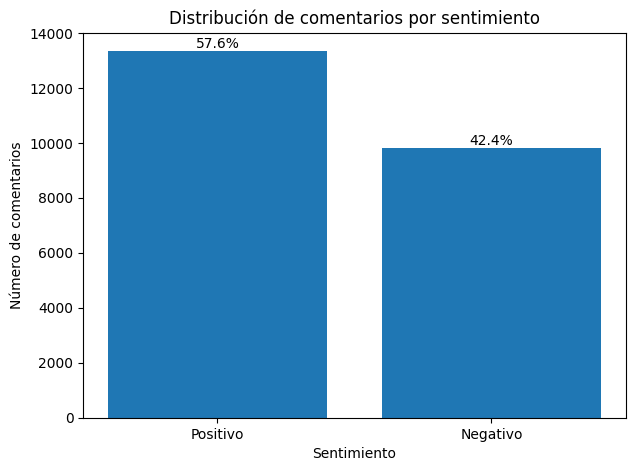

In [ ]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    class_distribution["Sentimiento"],
    class_distribution["Cantidad"]
)

plt.title("Distribución de comentarios por sentimiento")
plt.xlabel("Sentimiento")
plt.ylabel("Número de comentarios")

for bar, percentage in zip(
    bars,
    class_distribution["Porcentaje"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.1f}%",
        ha="center",
        va="bottom"
    )

plt.show()

#### Interpretación

El dataset presenta una distribución de **13.342 comentarios positivos (57,59 %)** y **9.826 comentarios negativos (42,41 %)**. La diferencia entre ambas clases es de **15,18 puntos porcentuales**, mientras que la clase minoritaria representa aproximadamente el **73,6 %** del tamaño de la clase mayoritaria.

Por tanto, existe un **desbalance moderado**, pero no lo suficientemente pronunciado como para justificar inicialmente técnicas de balanceo artificial. Ambas clases cuentan con una cantidad considerable de observaciones para el entrenamiento.

Sin embargo, debido a esta diferencia de proporciones, **accuracy no se utilizará como única medida de desempeño**, ya que un modelo que favorezca la clase mayoritaria podría obtener una precisión global aparentemente aceptable sin clasificar adecuadamente los comentarios negativos. Por esta razón se mantendrá **F1-macro como métrica principal**, complementada con accuracy, precision y recall.

Posteriormente, la división en conjuntos de entrenamiento, validación y prueba se realizará de forma **estratificada**, con el objetivo de conservar aproximadamente la misma distribución de clases en cada subconjunto.

### 3.2 Longitud de los comentarios

Para comprender las características del texto se analizará la longitud de los comentarios utilizando dos medidas:

- **Número de caracteres:** longitud total del texto.
- **Número de palabras:** cantidad aproximada de palabras presentes en cada comentario.

Este análisis permitirá identificar la longitud típica de los comentarios y detectar posibles textos extremadamente cortos o largos.

En esta etapa no se modifica el contenido de los comentarios; únicamente se generan variables auxiliares para el análisis exploratorio.

In [ ]:
eda_df = df.copy()

eda_df["n_caracteres"] = (
    eda_df["comentario"]
    .astype(str)
    .str.len()
)

eda_df["n_palabras"] = (
    eda_df["comentario"]
    .astype(str)
    .str.split()
    .str.len()
)

eda_df[
    ["comentario", "n_caracteres", "n_palabras"]
].head()

,comentario,n_caracteres,n_palabras
0,se debe mejorar en tener solo un coordinador p...,62,11
1,"nivel de educación, nivel de docentes",37,6
2,"la calidad de enseñanzas,",25,4
3,"la selecciom de los do3ntes, podran ser muy ac...",243,38
4,ensenanza,9,1


#### Estadísticas descriptivas de longitud

Se calculan medidas de tendencia central y percentiles para conocer tanto la longitud habitual de los comentarios como la presencia de posibles valores extremos.

La **mediana** resulta especialmente útil porque no se ve afectada en la misma medida que la media por comentarios excepcionalmente largos.

In [ ]:
length_summary = pd.DataFrame({
    "Caracteres": {
        "Media": eda_df["n_caracteres"].mean(),
        "Mediana": eda_df["n_caracteres"].median(),
        "Mínimo": eda_df["n_caracteres"].min(),
        "Percentil 25": eda_df["n_caracteres"].quantile(0.25),
        "Percentil 75": eda_df["n_caracteres"].quantile(0.75),
        "Percentil 90": eda_df["n_caracteres"].quantile(0.90),
        "Percentil 95": eda_df["n_caracteres"].quantile(0.95),
        "Percentil 99": eda_df["n_caracteres"].quantile(0.99),
        "Máximo": eda_df["n_caracteres"].max(),
    },
    "Palabras": {
        "Media": eda_df["n_palabras"].mean(),
        "Mediana": eda_df["n_palabras"].median(),
        "Mínimo": eda_df["n_palabras"].min(),
        "Percentil 25": eda_df["n_palabras"].quantile(0.25),
        "Percentil 75": eda_df["n_palabras"].quantile(0.75),
        "Percentil 90": eda_df["n_palabras"].quantile(0.90),
        "Percentil 95": eda_df["n_palabras"].quantile(0.95),
        "Percentil 99": eda_df["n_palabras"].quantile(0.99),
        "Máximo": eda_df["n_palabras"].max(),
    },
}).round(2)

length_summary

,Caracteres,Palabras
Media,91.76,15.25
Mediana,62.00,10.00
Mínimo,2.00,1.00
Percentil 25,38.00,6.00
Percentil 75,107.00,18.00
Percentil 90,178.00,30.00
Percentil 95,247.00,41.00
Percentil 99,497.65,85.00
Máximo,7638.00,1307.00


#### Distribución de la longitud en caracteres

Se visualiza la distribución de la longitud de los comentarios medida en caracteres.

Para evitar que unos pocos comentarios extremadamente largos dificulten la lectura del gráfico, la visualización se limita al **percentil 99**. Los datos originales no se eliminan ni modifican.

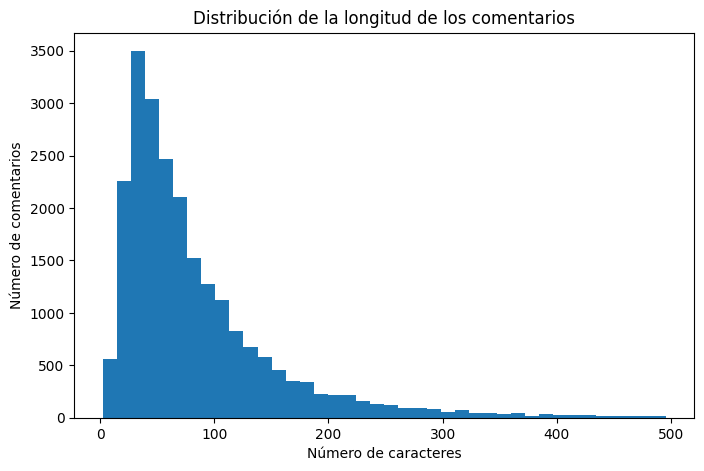

In [ ]:
p99_characters = eda_df["n_caracteres"].quantile(0.99)

plt.figure(figsize=(8, 5))

plt.hist(
    eda_df.loc[
        eda_df["n_caracteres"] <= p99_characters,
        "n_caracteres"
    ],
    bins=40
)

plt.title("Distribución de la longitud de los comentarios")
plt.xlabel("Número de caracteres")
plt.ylabel("Número de comentarios")

plt.show()

#### Distribución de la longitud en palabras

También se analiza la cantidad de palabras por comentario, ya que esta medida facilita la interpretación de la extensión real de los textos.

Al igual que en el gráfico anterior, la visualización se limita al percentil 99 para evitar que los valores extremos distorsionen la distribución principal.

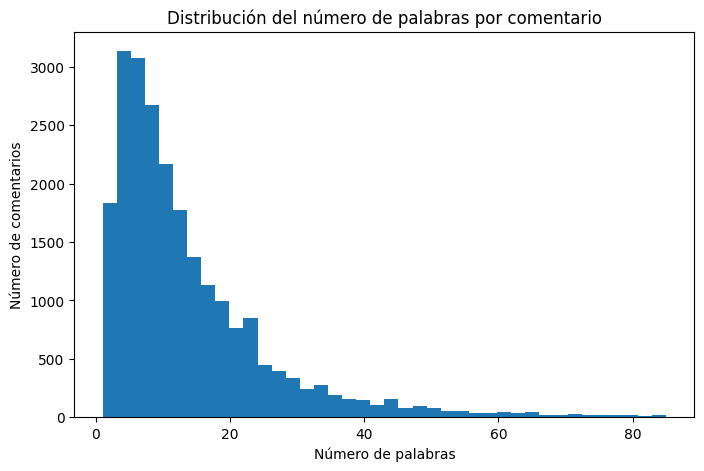

In [ ]:
p99_words = eda_df["n_palabras"].quantile(0.99)

plt.figure(figsize=(8, 5))

plt.hist(
    eda_df.loc[
        eda_df["n_palabras"] <= p99_words,
        "n_palabras"
    ],
    bins=40
)

plt.title("Distribución del número de palabras por comentario")
plt.xlabel("Número de palabras")
plt.ylabel("Número de comentarios")

plt.show()

#### Revisión de comentarios extremos

Además de las estadísticas generales, se revisan algunos de los comentarios más cortos y más largos.

Esto permite comprobar si los valores extremos corresponden a comentarios válidos o si podrían representar casos particulares que deban considerarse posteriormente durante la preparación de los datos.

In [ ]:
shortest_comments = (
    eda_df[
        ["comentario", "Valor", "n_palabras", "n_caracteres"]
    ]
    .sort_values(
        by=["n_palabras", "n_caracteres"]
    )
    .head(5)
)

shortest_comments

,comentario,Valor,n_palabras,n_caracteres
20692,wa,Positivo,1,2
7489,nqda,Positivo,1,4
22479,wifi,Positivo,1,4
2952,malla,Negativo,1,5
3013,orden,Negativo,1,5


In [ ]:
longest_comments = (
    eda_df[
        ["comentario", "Valor", "n_palabras", "n_caracteres"]
    ]
    .sort_values(
        by=["n_palabras", "n_caracteres"],
        ascending=False
    )
    .head(5)
)

longest_comments

,comentario,Valor,n_palabras,n_caracteres
22472,"a)sinceramente, que no suban las pensiones y a...",Positivo,1307,7638
18237,en mi caso soy del programa de working adult e...,Negativo,778,4643
18123,biblioteca:no hay lugares donde estudiar. no s...,Negativo,479,2820
20857,a lo largo de toda mi carrera universitaria se...,Negativo,402,2437
23010,"en la infraestructura, los 2 ""campus"" de c2 au...",Negativo,330,1853


#### Interpretación

La distribución de longitud en palabras presenta una **asimetría hacia la derecha**, evidenciando que predominan los comentarios relativamente cortos y que su frecuencia disminuye conforme aumenta la extensión del texto.

La mediana de **10 palabras**, frente a una media de **15,25**, refleja la influencia de comentarios más extensos sobre el promedio. Asimismo, el 90 % de los comentarios contiene 30 palabras o menos, mientras que aproximadamente el 1 % supera las 85 palabras.

Estos resultados confirman que el corpus está compuesto principalmente por textos breves, aunque presenta una pequeña proporción de comentarios considerablemente más largos. Por ahora, **no se considera necesario eliminar ni truncar observaciones basándose únicamente en su longitud**.

### 3.3 Identificación de comentarios duplicados

Se analizará la existencia de comentarios repetidos en el dataset, considerando únicamente el contenido de la columna `comentario`, independientemente de su sentimiento o categoría temática.

Este análisis es importante porque la presencia de textos idénticos en los conjuntos de entrenamiento y prueba podría producir **fuga de información (data leakage)**, generando una evaluación excesivamente optimista del desempeño del modelo.

Se identificarán:

- Cantidad de comentarios que aparecen más de una vez.
- Número de registros involucrados en repeticiones.
- Cantidad de duplicados excedentes.
- Porcentaje de registros duplicados respecto al total.
- Ejemplos de los comentarios más repetidos.

En esta etapa únicamente se identifican los duplicados exactos, sin aplicar transformaciones ni eliminar registros.

In [ ]:
# Identificar todas las apariciones de comentarios repetidos
duplicate_mask = df.duplicated(
    subset=["comentario"],
    keep=False
)

# Número de registros involucrados en repeticiones
repeated_rows = int(duplicate_mask.sum())

# Número de duplicados excedentes (sin contar la primera aparición)
duplicate_excess = int(
    df.duplicated(
        subset=["comentario"],
        keep="first"
    ).sum()
)

# Número de textos distintos que aparecen repetidos
repeated_texts = int(
    df.loc[duplicate_mask, "comentario"].nunique()
)

print(f"Total de registros: {len(df):,}")
print(f"Textos distintos repetidos: {repeated_texts:,}")
print(f"Registros involucrados en repeticiones: {repeated_rows:,}")
print(f"Duplicados excedentes: {duplicate_excess:,}")

Total de registros: 23,168
Textos distintos repetidos: 1
Registros involucrados en repeticiones: 2
Duplicados excedentes: 1


#### Proporción de comentarios duplicados

Se calcula qué porcentaje del dataset está involucrado en repeticiones y qué porcentaje corresponde a duplicados excedentes.

Se distingue entre ambas medidas para evitar confundir la cantidad total de apariciones repetidas con el número de registros adicionales respecto a una única aparición por comentario.

In [ ]:
total_rows = len(df)

repeated_percentage = (
    repeated_rows / total_rows * 100
)

duplicate_percentage = (
    duplicate_excess / total_rows * 100
)

duplicate_summary = pd.DataFrame({
    "Medida": [
        "Total de registros",
        "Textos distintos repetidos",
        "Registros involucrados en repeticiones",
        "Duplicados excedentes",
        "Porcentaje de registros involucrados (%)",
        "Porcentaje de duplicados excedentes (%)"
    ],
    "Resultado": [
        total_rows,
        repeated_texts,
        repeated_rows,
        duplicate_excess,
        round(repeated_percentage, 2),
        round(duplicate_percentage, 2)
    ]
})

duplicate_summary

,Medida,Resultado
0,Total de registros,23168.00
1,Textos distintos repetidos,1.00
2,Registros involucrados en repeticiones,2.00
3,Duplicados excedentes,1.00
4,Porcentaje de registros involucrados (%),0.01
5,Porcentaje de duplicados excedentes (%),0.00


#### Comentarios con mayor frecuencia de repetición

Se identifican los comentarios que aparecen con mayor frecuencia dentro del dataset.

Este análisis permite conocer si las repeticiones se concentran en unos pocos textos o si existen numerosos comentarios que se repiten.

Para facilitar la visualización, se mostrará una versión abreviada de cada comentario junto con su frecuencia de aparición.

In [ ]:
# Contar apariciones de cada comentario
comment_frequency = (
    df["comentario"]
    .value_counts()
    .rename_axis("comentario")
    .reset_index(name="frecuencia")
)

# Conservar únicamente comentarios repetidos
repeated_comments = comment_frequency[
    comment_frequency["frecuencia"] > 1
].copy()

# Crear una versión abreviada únicamente para visualización
repeated_comments["vista_previa"] = (
    repeated_comments["comentario"]
    .str.slice(0, 120)
)

# Mostrar los 10 comentarios más repetidos
repeated_comments[
    ["vista_previa", "frecuencia"]
].head(10)

,vista_previa,frecuencia
0,#¿NOMBRE?,2


#### Revisión de registros duplicados

Se examina una muestra de registros correspondientes a los comentarios más repetidos, conservando sus etiquetas de sentimiento y aspectos temáticos originales.

Esto permite observar cómo aparecen los textos repetidos dentro del dataset.

La verificación específica de posibles etiquetas contradictorias se realizará en el apartado 3.4.

In [ ]:
# Seleccionar los tres textos con mayor frecuencia de repetición
top_repeated_texts = (
    repeated_comments["comentario"]
    .head(3)
    .tolist()
)

# Obtener sus registros originales
duplicate_examples = df.loc[
    df["comentario"].isin(top_repeated_texts),
    ["comentario", "Valor", "nombreAspecto"]
].copy()

# Mostrar una muestra
duplicate_examples.head(15)

,comentario,Valor,nombreAspecto
152,#¿NOMBRE?,Negativo,Docentes
15596,#¿NOMBRE?,Negativo,Docentes


#### Interpretación

De los **23.168 registros**, se identificó únicamente **1 texto distinto repetido**, correspondiente a `#¿NOMBRE?`, presente en dos registros y con un único duplicado excedente (aproximadamente el **0,0043 % del dataset**).

Estos resultados evidencian que la presencia de duplicados exactos es prácticamente insignificante y no constituye un problema generalizado de calidad de los datos.

Sin embargo, el comentario identificado requiere una revisión adicional, ya que su contenido podría corresponder a un marcador o error de exportación, en lugar de una opinión estudiantil válida.

Antes de realizar la limpieza y división de los datos, se verificará la consistencia de las etiquetas de los comentarios repetidos para evitar posibles inconsistencias y fugas de información entre los conjuntos de entrenamiento y prueba.

**Decisión preliminar:** no se eliminan registros en esta etapa. El tratamiento del duplicado se definirá después de completar la revisión de consistencia y calidad textual.

### 3.4 Consistencia de etiquetas en comentarios duplicados

Después de identificar los comentarios repetidos, se verificará si un mismo texto aparece asociado a diferentes etiquetas de sentimiento.

Se considera una **contradicción de etiquetado** cuando dos o más registros contienen exactamente el mismo comentario, pero presentan diferentes valores en la variable objetivo `Valor`.

Por ejemplo, un mismo comentario clasificado simultáneamente como `Positivo` y `Negativo`.

Este análisis permite detectar posibles inconsistencias en las anotaciones, las cuales podrían introducir información contradictoria durante el entrenamiento y afectar la evaluación de los modelos.

En esta etapa únicamente se identifican las inconsistencias, sin modificar ni eliminar registros.

In [ ]:
# Obtener únicamente los registros con comentarios repetidos
duplicated_records = df.loc[
    duplicate_mask,
    ["comentario", "Valor", "nombreAspecto"]
].copy()

# Analizar las etiquetas asociadas a cada texto repetido
duplicate_label_analysis = (
    duplicated_records
    .groupby("comentario", dropna=False)
    .agg(
        n_registros=("Valor", "size"),
        n_etiquetas=("Valor", lambda x: x.nunique(dropna=False)),
        etiquetas=("Valor", lambda x: sorted(x.astype(str).unique()))
    )
    .reset_index()
)

duplicate_label_analysis

,comentario,n_registros,n_etiquetas,etiquetas
0,#¿NOMBRE?,2,1,[Negativo]


#### Identificación de etiquetas contradictorias

Se identificarán los comentarios repetidos que presentan más de una etiqueta de sentimiento.

Para ello, se seleccionarán aquellos textos cuyo número de etiquetas distintas (`n_etiquetas`) sea superior a uno.

También se contabilizarán los comentarios repetidos cuyas etiquetas son consistentes, permitiendo distinguir entre duplicación de registros e inconsistencia de anotación.

In [ ]:
# Comentarios repetidos con etiquetas contradictorias
contradictory_comments = duplicate_label_analysis[
    duplicate_label_analysis["n_etiquetas"] > 1
].copy()

# Comentarios repetidos con etiquetas consistentes
consistent_comments = duplicate_label_analysis[
    duplicate_label_analysis["n_etiquetas"] == 1
].copy()

print("Resultados del análisis:")
print(f"Textos repetidos analizados: {len(duplicate_label_analysis)}")
print(f"Textos con etiquetas consistentes: {len(consistent_comments)}")
print(f"Textos con etiquetas contradictorias: {len(contradictory_comments)}")

Resultados del análisis:
Textos repetidos analizados: 1
Textos con etiquetas consistentes: 1
Textos con etiquetas contradictorias: 0


In [ ]:
label_consistency_summary = pd.DataFrame({
    "Medida": [
        "Textos repetidos analizados",
        "Textos con etiquetas consistentes",
        "Textos con etiquetas contradictorias",
        "Registros involucrados en contradicciones"
    ],
    "Resultado": [
        len(duplicate_label_analysis),
        len(consistent_comments),
        len(contradictory_comments),
        int(contradictory_comments["n_registros"].sum())
    ]
})

label_consistency_summary

,Medida,Resultado
0,Textos repetidos analizados,1
1,Textos con etiquetas consistentes,1
2,Textos con etiquetas contradictorias,0
3,Registros involucrados en contradicciones,0


#### Revisión de los registros con etiquetas contradictorias

Si se identifican comentarios asociados a diferentes sentimientos, se mostrarán sus registros originales para comprobar las etiquetas y categorías temáticas correspondientes.

Esta revisión permitirá documentar los casos encontrados y establecer posteriormente una decisión de tratamiento durante la limpieza de datos.

In [ ]:
# Obtener los textos que presentan contradicciones
contradictory_texts = contradictory_comments["comentario"]

# Recuperar sus registros originales
contradictory_records = df.loc[
    df["comentario"].isin(contradictory_texts),
    ["comentario", "Valor", "nombreAspecto"]
].copy()

if contradictory_records.empty:
    print("No se encontraron comentarios con etiquetas contradictorias.")
else:
    display(contradictory_records)

No se encontraron comentarios con etiquetas contradictorias.


#### Interpretación

El análisis identificó **1 texto repetido con etiquetas consistentes y ningún caso de etiquetado contradictorio**. El comentario `#¿NOMBRE?` aparece dos veces y conserva la etiqueta `Negativo` en ambas observaciones.

Estos resultados indican que no existen inconsistencias de sentimiento entre los duplicados exactos detectados, por lo que no se evidencia un problema de contradicción de etiquetas en este análisis.

Sin embargo, la consistencia de las etiquetas no garantiza la validez del contenido del comentario identificado. Por ello, `#¿NOMBRE?` deberá revisarse durante la etapa de limpieza, considerando su posible origen como marcador o error de exportación.

**Decisión preliminar:** no se requiere resolver conflictos de etiquetado entre los duplicados exactos identificados. Su tratamiento definitivo se establecerá durante la limpieza y preparación del dataset.

### 3.5 Análisis del ruido textual

Se analizarán las características del texto que podrían representar irregularidades de escritura, formato o codificación dentro de los comentarios estudiantiles.

El objetivo es identificar y cuantificar posibles señales de ruido antes de establecer las decisiones de limpieza y preparación para el modelado.

Se examinarán los siguientes aspectos:

- Presencia de números dentro de palabras.
- Comentarios escritos completamente en mayúsculas.
- Símbolos especiales y signos de puntuación repetidos.
- Espacios innecesarios o irregularidades de formato.
- Presencia de tildes y posibles problemas de codificación.
- Marcadores o contenidos anómalos, como `#¿NOMBRE?`.

**Importante:** la detección de estos patrones no implica automáticamente que los comentarios sean incorrectos. Los casos identificados deberán revisarse antes de decidir si requieren algún tratamiento.

Durante esta etapa no se modificarán ni eliminarán registros del dataset original.

#### Identificación de posibles irregularidades textuales

Se utilizarán expresiones regulares y operaciones sobre cadenas de texto para detectar distintos patrones que podrían requerir revisión.

Las comprobaciones se realizarán sobre una serie auxiliar, conservando intactos los comentarios originales.

Los patrones detectados se almacenarán como máscaras booleanas, donde `True` indica que el comentario presenta la característica analizada y `False` indica que no se ha detectado.

In [ ]:
import re

# Serie auxiliar para el diagnóstico.
# No modifica el contenido original del DataFrame.
text_series = df["comentario"].fillna("").astype(str)

# Expresión para detectar dígitos intercalados entre letras.
# Ejemplo: do3ntes
embedded_digit_pattern = r"[^\W\d_]+\d+[^\W\d_]+"

# Detectar tres o más signos de puntuación iguales consecutivos.
# Ejemplos: !!!, ???, ...
repeated_punctuation_pattern = re.compile(
    r"([!?¡¿.,;:])\1{2,}"
)

# Patrones que podrían indicar problemas de codificación.
# Son señales heurísticas, no una comprobación definitiva.
encoding_pattern = r"Ã.|Â.|â€|�"


def is_all_uppercase(text):
    """
    Comprueba si todas las letras del comentario están
    en mayúsculas, considerando al menos tres letras.
    """
    letters = [char for char in text if char.isalpha()]

    return (
        len(letters) >= 3
        and all(char.isupper() for char in letters)
    )


# Construcción de las máscaras de diagnóstico
noise_masks = {

    "Contiene números": (
        text_series.str.contains(r"\d", regex=True)
    ),

    "Dígitos dentro de palabras": (
        text_series.str.contains(
            embedded_digit_pattern,
            regex=True
        )
    ),

    "Mayúsculas sostenidas": (
        text_series.apply(is_all_uppercase)
    ),

    "Símbolos a revisar": (
        text_series.str.contains(
            r"[#@$%^&*_=+\{\}\[\]\|<>~\\]",
            regex=True
        )
    ),

    "Puntuación repetida": (
        text_series.apply(
            lambda text: bool(
                repeated_punctuation_pattern.search(text)
            )
        )
    ),

    "Espacios repetidos": (
        text_series.str.contains(r" {2,}", regex=True)
    ),

    "Espacios al inicio o final": (
        text_series.ne(text_series.str.strip())
    ),

    "Saltos de línea o tabulaciones": (
        text_series.str.contains(
            r"[\n\r\t]",
            regex=True
        )
    ),

    "Posibles problemas de codificación": (
        text_series.str.contains(
            encoding_pattern,
            regex=True
        )
    ),

    "Marcador #¿NOMBRE?": (
        text_series.str.strip().str.upper().eq("#¿NOMBRE?")
    )
}

print("Patrones de diagnóstico definidos correctamente.")

Patrones de diagnóstico definidos correctamente.


#### Cuantificación de las irregularidades detectadas

Se calcula la cantidad y el porcentaje de comentarios que presentan cada uno de los patrones definidos.

Esto permitirá determinar qué características son frecuentes dentro del corpus y cuáles aparecen únicamente en casos aislados.

Las categorías no son excluyentes: un mismo comentario puede presentar varias características simultáneamente. Por esta razón, los porcentajes no necesariamente sumarán el 100 %.

In [ ]:
noise_summary = pd.DataFrame([
    {
        "Característica": name,
        "Cantidad": int(mask.sum()),
        "Porcentaje": round(
            mask.mean() * 100,
            2
        )
    }
    for name, mask in noise_masks.items()
])

noise_summary = (
    noise_summary
    .sort_values(
        by="Cantidad",
        ascending=False
    )
    .reset_index(drop=True)
)

noise_summary

,Característica,Cantidad,Porcentaje
0,Espacios repetidos,2651,11.44
1,Contiene números,887,3.83
2,Puntuación repetida,362,1.56
3,Símbolos a revisar,104,0.45
4,Dígitos dentro de palabras,49,0.21
5,Mayúsculas sostenidas,2,0.01
6,Marcador #¿NOMBRE?,2,0.01
7,Saltos de línea o tabulaciones,1,0.00
8,Espacios al inicio o final,0,0.00
9,Posibles problemas de codificación,0,0.00


##### Interpretación de la cuantificación

La irregularidad más frecuente corresponde a los **espacios repetidos**, presentes en 2.651 comentarios (11,44 %), seguida de la presencia de números (3,83 %) y la puntuación repetida (1,56 %).

Las demás características presentan una frecuencia inferior al 0,5 %. Entre ellas destacan los 49 comentarios (0,21 %) con dígitos intercalados entre letras y las dos apariciones del marcador `#¿NOMBRE?`, identificado previamente en el análisis de duplicados.

No se detectaron espacios al inicio o final de los comentarios ni posibles problemas de codificación mediante los patrones definidos. Sin embargo, esto último no descarta otras irregularidades que el método empleado pudiera no identificar.

Los resultados sugieren que la normalización de espacios podría ser una transformación pertinente durante la preparación de los datos. En cambio, la presencia de números, mayúsculas o signos de puntuación no debe considerarse automáticamente un error, pues estas características pueden formar parte del contenido original y aportar información contextual.

**Por ahora, no se modifica el dataset.** La necesidad de aplicar otras transformaciones se determinará mediante la revisión de ejemplos reales en el siguiente apartado.

#### Revisión de comentarios con posibles irregularidades

Después de cuantificar los patrones, se revisarán ejemplos reales de los comentarios identificados.

Esta revisión permitirá diferenciar entre características legítimas del lenguaje y posibles problemas de calidad textual.

Por ejemplo, un número puede representar información válida dentro de una opinión, mientras que un número intercalado entre las letras de una palabra podría corresponder a un error de escritura.

Se mostrarán hasta cinco ejemplos por característica, conservando su contenido y etiqueta originales.

In [ ]:
patterns_to_review = [
    "Dígitos dentro de palabras",
    "Mayúsculas sostenidas",
    "Símbolos a revisar",
    "Puntuación repetida",
    "Espacios repetidos",
    "Espacios al inicio o final",
    "Saltos de línea o tabulaciones",
    "Posibles problemas de codificación",
    "Marcador #¿NOMBRE?"
]

for pattern_name in patterns_to_review:

    mask = noise_masks[pattern_name]

    examples = df.loc[
        mask,
        ["comentario", "Valor", "nombreAspecto"]
    ].head(5)

    print(f"\n--- {pattern_name} ---")
    print(f"Total detectado: {int(mask.sum())}")

    if examples.empty:
        print("No se encontraron casos.")
    else:
        display(examples)


--- Dígitos dentro de palabras ---
Total detectado: 49


,comentario,Valor,nombreAspecto
3,"la selecciom de los do3ntes, podran ser muy ac...",Positivo,Docentes
237,su tecnologia y c6recimiento a pasos agintados,Positivo,Percepción General
679,desde que empece como estudiando de upn me he ...,Positivo,Percepción General
1180,"mejorar la selecion de los docentes, pueden se...",Negativo,Docentes
1730,estudiar com bu3nos profesionales y apremder t...,Positivo,Docentes



--- Mayúsculas sostenidas ---
Total detectado: 2


,comentario,Valor,nombreAspecto
152,#¿NOMBRE?,Negativo,Docentes
15596,#¿NOMBRE?,Negativo,Docentes



--- Símbolos a revisar ---
Total detectado: 104


...

,comentario,Valor,nombreAspecto
5,estamos disgusto de su empeño del profesor jor...,Negativo,Docentes
12,mala coordinación con respecto a la informació...,Negativo,Estrategia Académica
22,información entregada al alumno. igualdad de ...,Negativo,Percepción General
26,la metodología se vasallos en exceso a la expe...,Negativo,Estrategia Académica
42,en la calidad de los docentes en la preparaci...,Negativo,Docentes



--- Espacios al inicio o final ---
Total detectado: 0
No se encontraron casos.

--- Saltos de línea o tabulaciones ---
Total detectado: 1


,comentario,Valor,nombreAspecto
22090,vamos a poner un ejemplo: en la carrera de psi...,Negativo,Experiencia Académica



--- Posibles problemas de codificación ---
Total detectado: 0
No se encontraron casos.

--- Marcador #¿NOMBRE? ---
Total detectado: 2


,comentario,Valor,nombreAspecto
152,#¿NOMBRE?,Negativo,Docentes
15596,#¿NOMBRE?,Negativo,Docentes


##### Interpretación de los ejemplos identificados

La revisión de comentarios permitió observar diferentes tipos de irregularidades textuales. Se identificaron posibles errores de escritura, como `do3ntes`, `c6recimiento` y `bu3nos`, así como problemas menores de formato relacionados con espacios y puntuación repetida.

Sin embargo, también se encontraron expresiones potencialmente válidas, como `<3`, que pueden transmitir información relevante sobre el sentimiento del comentario. Por tanto, no todos los patrones detectados deben considerarse ruido ni eliminarse automáticamente.

Un hallazgo particular es el marcador `#¿NOMBRE?`, presente en dos registros. Además de constituir el único comentario duplicado identificado anteriormente, su contenido no representa una opinión estudiantil interpretable y requiere revisión durante la etapa de limpieza.

**Decisión preliminar:** considerar la normalización de espacios y revisar los casos con dígitos intercalados y contenidos anómalos. Se evitará eliminar indiscriminadamente números, símbolos o signos de puntuación, ya que podrían aportar información útil para la clasificación de sentimiento.

En esta etapa se conserva intacto el dataset original.

#### Presencia de tildes en los comentarios

Se analizará la presencia de vocales acentuadas dentro del corpus para obtener una característica descriptiva adicional de la escritura.

Este análisis no pretende identificar automáticamente errores ortográficos, ya que un comentario puede estar correctamente escrito sin contener ninguna palabra acentuada.

Por tanto, la ausencia de tildes no se considerará por sí sola un indicador de ruido textual.

In [ ]:
# Detectar vocales con tilde
accent_pattern = r"[áéíóúÁÉÍÓÚ]"

has_accents = text_series.str.contains(
    accent_pattern,
    regex=True
)

accent_summary = pd.DataFrame({
    "Característica": [
        "Comentarios con vocales acentuadas",
        "Comentarios sin vocales acentuadas"
    ],
    "Cantidad": [
        int(has_accents.sum()),
        int((~has_accents).sum())
    ],
    "Porcentaje": [
        round(has_accents.mean() * 100, 2),
        round((~has_accents).mean() * 100, 2)
    ]
})

accent_summary

,Característica,Cantidad,Porcentaje
0,Comentarios con vocales acentuadas,4599,19.85
1,Comentarios sin vocales acentuadas,18569,80.15


##### Interpretación de la presencia de tildes

De los **23.168 comentarios**, se identificaron **4.599 (19,85 %) con al menos una vocal acentuada**, mientras que **18.569 (80,15 %) no contienen vocales acentuadas**.

Aunque predomina la ausencia de tildes, este resultado no demuestra que existan errores ortográficos, ya que numerosos comentarios pueden estar correctamente escritos sin requerir palabras acentuadas. Además, la brevedad de los textos podría contribuir a esta distribución.

El análisis realizado es descriptivo y únicamente identifica la presencia de vocales acentuadas; no determina si las palabras que carecen de tilde están escritas correctamente.

**Decisión preliminar:** conservar las tildes originales y evitar tanto su eliminación como su corrección automática, dado que todavía no existe evidencia suficiente para justificar dichas transformaciones.

#### Resumen del diagnóstico de ruido textual

Se consolida el análisis realizado para determinar cuántos comentarios presentan al menos una de las señales detectadas.

Este resumen permite estimar la presencia global de características que requieren revisión, sin asumir que todos los casos identificados constituyen errores.

Los resultados servirán como evidencia para justificar las decisiones posteriores de limpieza.

In [ ]:
# DataFrame auxiliar con las máscaras del diagnóstico
noise_diagnostics = pd.DataFrame(
    noise_masks,
    index=df.index
)

# Comentarios que presentan al menos una característica
has_any_signal = noise_diagnostics.any(axis=1)

general_noise_summary = pd.DataFrame({
    "Medida": [
        "Total de comentarios",
        "Comentarios con alguna señal detectada",
        "Comentarios sin señales detectadas",
        "Porcentaje con alguna señal (%)"
    ],
    "Resultado": [
        len(df),
        int(has_any_signal.sum()),
        int((~has_any_signal).sum()),
        round(has_any_signal.mean() * 100, 2)
    ]
})

general_noise_summary

,Medida,Resultado
0,Total de comentarios,23168.00
1,Comentarios con alguna señal detectada,3530.00
2,Comentarios sin señales detectadas,19638.00
3,Porcentaje con alguna señal (%),15.24


#### Interpretación general

El análisis de ruido textual identificó que el **15,24 % de los comentarios presenta al menos una señal de posible irregularidad**, mientras que el 84,76 % restante no presenta coincidencias con los patrones definidos. Estos resultados no implican que todos los comentarios señalados contengan errores, ya que algunas características detectadas pueden formar parte legítima del lenguaje.

La irregularidad más frecuente corresponde a los **espacios repetidos (11,44 %)**, seguida de la presencia de números (3,83 %) y puntuación repetida (1,56 %). También se identificaron 49 comentarios (0,21 %) con dígitos intercalados entre letras, algunos de los cuales muestran posibles errores de escritura, como `do3ntes` y `bu3nos`.

La revisión de ejemplos permitió comprobar que ciertos elementos, como los símbolos expresivos (`<3`) o la puntuación repetida, podrían aportar información relevante para la clasificación de sentimiento. Por otra parte, se identificaron dos apariciones del marcador anómalo `#¿NOMBRE?`, cuyo contenido requiere revisión durante la limpieza.

Respecto a las tildes, el 80,15 % de los comentarios no contiene vocales acentuadas. Sin embargo, este resultado no constituye evidencia de errores ortográficos, puesto que un comentario puede estar correctamente escrito sin contener palabras que requieran tilde. Tampoco se detectaron posibles problemas de codificación mediante los patrones utilizados.

**Decisión preliminar:** los resultados justifican considerar una limpieza textual selectiva, priorizando la normalización de espacios y la revisión de posibles errores de escritura y contenidos anómalos. Se evitará eliminar indiscriminadamente tildes, números, símbolos o signos de puntuación, dado que podrían conservar información útil para la clasificación de sentimiento.

En esta etapa no se modifica el dataset original. Las transformaciones definitivas se establecerán durante la preparación de los datos, considerando las características de los dos enfoques que se compararán: TF-IDF + Regresión Logística y Transformer preentrenado.

### 3.6 Distribución de los aspectos temáticos

El dataset contiene la variable `nombreAspecto`, que identifica el aspecto temático al que pertenece cada comentario estudiantil.

Se analizará la distribución de esta variable para conocer cuántos comentarios corresponden a cada aspecto y determinar su representación porcentual dentro del corpus.

Este análisis permitirá comprender la composición temática de los datos e identificar posibles diferencias en la cantidad de comentarios disponibles por aspecto.

**Importante:** `nombreAspecto` es una variable contextual, mientras que `Valor` representa la etiqueta de sentimiento que se busca predecir. Por tanto, en esta sección se estudiará únicamente la distribución de los aspectos, sin relacionarlos todavía con las etiquetas `Positivo` y `Negativo`.

El análisis es descriptivo y no modifica el dataset original.

#### Cantidad y porcentaje de comentarios por aspecto

Se calculará la frecuencia absoluta y relativa de cada valor de `nombreAspecto`.

La frecuencia absoluta indica cuántos comentarios pertenecen a cada aspecto, mientras que el porcentaje permite conocer su representación respecto al total de registros.

Los resultados se ordenarán de mayor a menor cantidad de comentarios.

In [ ]:
# Conteo de comentarios por aspecto
aspect_counts = df["nombreAspecto"].value_counts(dropna=False)

# Construcción de la tabla resumen
aspect_summary = (
    aspect_counts
    .rename_axis("Aspecto")
    .reset_index(name="Cantidad")
)

# Calcular el porcentaje respecto al total de registros
aspect_summary["Porcentaje (%)"] = (
    aspect_summary["Cantidad"] / len(df) * 100
).round(2)

# Mostrar los resultados
display(aspect_summary)

# Comprobación de consistencia
print(f"Total de comentarios: {len(df):,}")
print(f"Total contabilizado por aspecto: {aspect_summary['Cantidad'].sum():,}")
print(f"Número de aspectos distintos: {df['nombreAspecto'].nunique(dropna=False)}")

,Aspecto,Cantidad,Porcentaje (%)
0,Docentes,7673,33.12
1,Experiencia Académica,6209,26.80
2,Estrategia Académica,5427,23.42
3,Percepción General,3859,16.66


Total de comentarios: 23,168
Total contabilizado por aspecto: 23,168
Número de aspectos distintos: 4


#### Visualización de la distribución de aspectos

Se utilizará un gráfico de barras horizontales para representar la cantidad de comentarios correspondiente a cada aspecto temático.

Este tipo de visualización facilita la comparación entre categorías, especialmente cuando sus nombres tienen diferentes longitudes.

Las barras se ordenarán de mayor a menor frecuencia y se incluirá la cantidad de comentarios correspondiente a cada categoría.

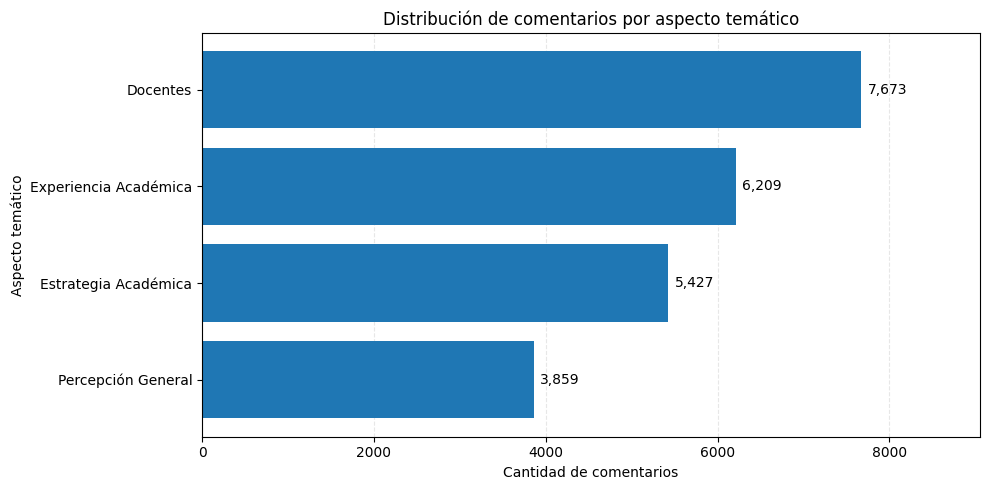

In [ ]:
# Datos para la visualización
aspect_names = aspect_summary["Aspecto"].astype(str)
aspect_values = aspect_summary["Cantidad"]

# Crear figura
fig, ax = plt.subplots(figsize=(10, 5))

# Gráfico de barras horizontales
bars = ax.barh(
    aspect_names,
    aspect_values
)

# Mostrar primero el aspecto con mayor frecuencia
ax.invert_yaxis()

# Etiquetas y título
ax.set_title("Distribución de comentarios por aspecto temático")
ax.set_xlabel("Cantidad de comentarios")
ax.set_ylabel("Aspecto temático")

# Añadir la cantidad al final de cada barra
for bar, value in zip(bars, aspect_values):
    ax.text(
        bar.get_width() + aspect_values.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,}",
        va="center"
    )

# Espacio adicional para visualizar las etiquetas
ax.set_xlim(0, aspect_values.max() * 1.18)

# Cuadrícula de referencia
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

#### Interpretación

El análisis de los **23.168 comentarios** evidencia una distribución temática no uniforme entre los cuatro aspectos identificados.

El aspecto con mayor representación es **Docentes**, con 7.673 comentarios (33,12 %), seguido de Experiencia Académica con 6.209 (26,80 %) y Estrategia Académica con 5.427 (23,42 %). Por su parte, Percepción General presenta la menor representación, con 3.859 comentarios (16,66 %).

Estos resultados muestran que el corpus reúne opiniones de diferentes contextos académicos, aunque existe una mayor concentración de comentarios relacionados con los docentes. Todos los aspectos cuentan con una cantidad considerable de observaciones.

Es importante señalar que esta distribución describe únicamente la composición temática del dataset y no permite determinar qué aspectos presentan más opiniones positivas o negativas. Para ello, será necesario analizar conjuntamente las variables `nombreAspecto` y `Valor`.

**Decisión preliminar:** conservar los cuatro aspectos y mantener `nombreAspecto` como información contextual. No se considera necesario realizar modificaciones basándose únicamente en su distribución, dado que el objetivo principal del proyecto es clasificar el sentimiento de los comentarios y no predecir su aspecto temático.

### 3.7 Relación entre el aspecto temático y el sentimiento

Después de analizar por separado la distribución del sentimiento y de los aspectos temáticos, se estudiará la relación descriptiva entre las variables `nombreAspecto` y `Valor`.

El objetivo es identificar cómo se distribuyen las etiquetas `Positivo` y `Negativo` dentro de cada aspecto académico y comprobar si existen diferencias relevantes en sus proporciones.

Para ello, se elaborarán tablas de frecuencias absolutas y relativas, acompañadas de una visualización mediante barras apiladas al 100 %.

**Importante:** la comparación principal se realizará utilizando los porcentajes calculados dentro de cada aspecto, ya que las categorías temáticas presentan diferentes cantidades de comentarios.

Este análisis es exploratorio y descriptivo. Las diferencias observadas no permiten establecer relaciones causales entre el aspecto académico y el sentimiento expresado.

No se realizarán modificaciones sobre el dataset original.

#### Distribución absoluta del sentimiento por aspecto

Se construirá una tabla de contingencia que muestre la cantidad de comentarios positivos y negativos correspondientes a cada aspecto temático.

Esta tabla permitirá conocer la distribución absoluta de las etiquetas e identificar cuántas observaciones aporta cada categoría al corpus.

In [ ]:
# Mantener el orden utilizado en el apartado 3.6
aspect_order = aspect_summary["Aspecto"].tolist()

# Definir el orden de las etiquetas de sentimiento
sentiment_order = ["Positivo", "Negativo"]

# Construir la tabla cruzada de frecuencias absolutas
aspect_sentiment_counts = pd.crosstab(
    df["nombreAspecto"],
    df["Valor"]
).reindex(
    index=aspect_order,
    columns=sentiment_order,
    fill_value=0
)

# Incorporar los totales por aspecto y el total general
aspect_sentiment_counts_total = aspect_sentiment_counts.copy()

aspect_sentiment_counts_total["Total"] = (
    aspect_sentiment_counts_total.sum(axis=1)
)

aspect_sentiment_counts_total.loc["Total"] = (
    aspect_sentiment_counts_total.sum(axis=0)
)

display(aspect_sentiment_counts_total)

# Comprobar que se contabilizaron todos los registros
print(f"Total de registros del dataset: {len(df):,}")
print(
    "Total contabilizado en la tabla: "
    f"{aspect_sentiment_counts.to_numpy().sum():,}"
)

assert aspect_sentiment_counts.to_numpy().sum() == len(df), (
    "La tabla cruzada no contabiliza todos los registros."
)

Valor,Positivo,Negativo,Total
nombreAspecto,,,
Docentes,5573,2100,7673
Experiencia Académica,2835,3374,6209
Estrategia Académica,2907,2520,5427
Percepción General,2027,1832,3859
Total,13342,9826,23168


Total de registros del dataset: 23,168
Total contabilizado en la tabla: 23,168


#### Distribución porcentual del sentimiento dentro de cada aspecto

Debido a que los aspectos temáticos contienen diferentes cantidades de comentarios, las frecuencias absolutas no son suficientes para comparar sus distribuciones de sentimiento.

Se calculará el porcentaje de comentarios positivos y negativos respecto al total de registros de cada aspecto.

De esta manera, cada fila representará el 100 % de su categoría temática, permitiendo comparar las proporciones de sentimiento independientemente del tamaño de cada grupo.

In [ ]:
# Calcular porcentajes respecto al total de cada aspecto (fila)
aspect_sentiment_percent = (
    aspect_sentiment_counts
    .div(
        aspect_sentiment_counts.sum(axis=1),
        axis=0
    )
    .mul(100)
)

# Construir tabla para visualización
aspect_sentiment_percent_display = (
    aspect_sentiment_percent
    .round(2)
    .copy()
)

aspect_sentiment_percent_display["Total (%)"] = (
    aspect_sentiment_percent.sum(axis=1).round(2)
)

display(aspect_sentiment_percent_display)

Valor,Positivo,Negativo,Total (%)
nombreAspecto,,,
Docentes,72.63,27.37,100.0
Experiencia Académica,45.66,54.34,100.0
Estrategia Académica,53.57,46.43,100.0
Percepción General,52.53,47.47,100.0


#### Visualización de la distribución del sentimiento por aspecto

Se representará la distribución porcentual mediante un gráfico de barras horizontales apiladas al 100 %.

Cada barra corresponderá a un aspecto temático y mostrará la proporción de comentarios positivos y negativos que lo componen.

Esta representación permitirá comparar visualmente la distribución del sentimiento entre los diferentes contextos académicos, evitando que las diferencias en el número total de comentarios distorsionen la comparación.

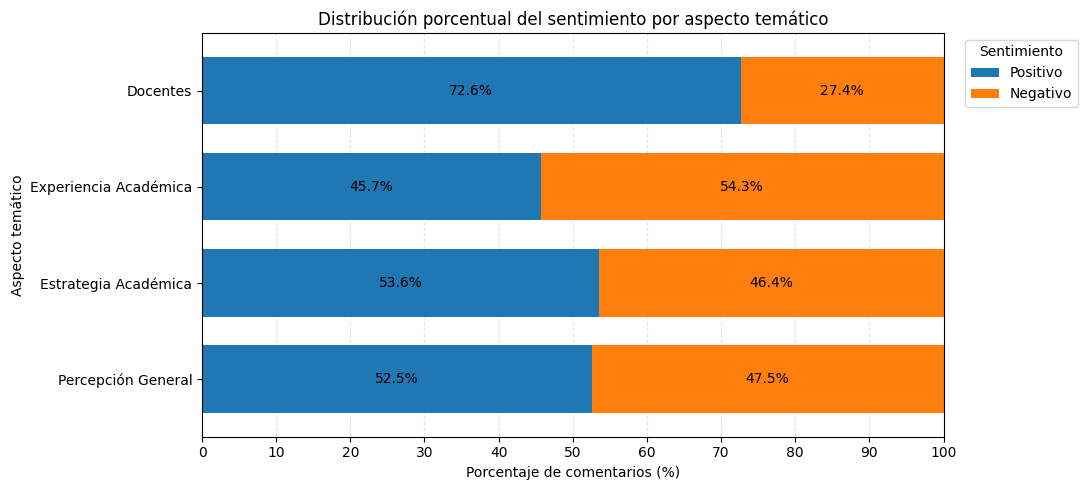

In [ ]:
# Crear figura
fig, ax = plt.subplots(figsize=(11, 5))

# Dibujar las barras apiladas utilizando los porcentajes
aspect_sentiment_percent[
    sentiment_order
].plot(
    kind="barh",
    stacked=True,
    ax=ax,
    width=0.7
)

# Mantener primero el aspecto con mayor cantidad de comentarios
ax.invert_yaxis()

# Añadir porcentajes dentro de cada segmento
for container in ax.containers:
    labels = [
        f"{bar.get_width():.1f}%"
        if bar.get_width() >= 5
        else ""
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=10
    )

# Configuración del gráfico
ax.set_title(
    "Distribución porcentual del sentimiento por aspecto temático"
)
ax.set_xlabel("Porcentaje de comentarios (%)")
ax.set_ylabel("Aspecto temático")

ax.set_xlim(0, 100)
ax.set_xticks(range(0, 101, 10))

ax.legend(
    title="Sentimiento",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

#### Interpretación

El análisis cruzado entre `nombreAspecto` y `Valor` evidencia diferencias en la distribución del sentimiento según el aspecto temático de los comentarios estudiantiles.

El aspecto **Docentes** presenta el mayor predominio de comentarios positivos, con un **72,63 %**, frente al 27,37 % de negativos. En contraste, **Experiencia Académica** es el único aspecto donde predominan los comentarios negativos, con un **54,34 %**, frente al 45,66 % de positivos.

Por su parte, **Estrategia Académica** y **Percepción General** presentan distribuciones relativamente equilibradas, con un ligero predominio de comentarios positivos (53,57 % y 52,53 %, respectivamente).

Estos resultados muestran que, aunque globalmente el dataset contiene una mayor proporción de comentarios positivos (57,59 %), esta tendencia no se mantiene de la misma manera en todos los contextos académicos.

Las diferencias observadas sugieren una asociación descriptiva entre el aspecto temático y la distribución del sentimiento, pero no permiten establecer relaciones causales.

**Decisión preliminar:** conservar los cuatro aspectos y mantener `nombreAspecto` como variable contextual para comprender la composición del corpus. El objetivo del modelado continuará siendo predecir la etiqueta `Valor` a partir del contenido textual de los comentarios, utilizando los mismos conjuntos de datos para comparar TF-IDF + Regresión Logística y el Transformer preentrenado.

### 3.8 Frecuencia de palabras y expresiones según el sentimiento

Se analizarán las palabras y expresiones más frecuentes en los comentarios estudiantiles, diferenciando entre las etiquetas `Positivo` y `Negativo`.

El objetivo es explorar el vocabulario utilizado en cada clase e identificar posibles patrones lingüísticos relacionados con la expresión del sentimiento.

Para ello, se estudiarán dos tipos de unidades:

- **Unigramas:** palabras individuales, como `bueno`, `docente` o `excelente`.
- **Bigramas:** secuencias de dos palabras consecutivas, como `muy bueno` o `no explica`.

Se calcularán frecuencias absolutas y relativas, acompañadas de tablas y gráficos para facilitar la comparación entre sentimientos.

**Consideraciones metodológicas:**

- Se utilizará una representación auxiliar de los comentarios, sin modificar el dataset original.
- Para el análisis de unigramas se excluirá un conjunto básico de palabras vacías del español.
- Se conservarán las negaciones (`no`, `nunca`, `sin`, `ni`, `tampoco`), debido a su posible importancia para interpretar el sentimiento.
- Para construir los bigramas se mantendrá el orden original de las palabras, evitando formar expresiones artificiales mediante la eliminación previa de palabras vacías.
- La frecuencia de una palabra no demuestra por sí sola su capacidad para predecir el sentimiento.

Este análisis tiene una finalidad exclusivamente descriptiva. La construcción definitiva de las representaciones TF-IDF se realizará posteriormente, utilizando únicamente los datos de entrenamiento.

#### Preparación del texto para el análisis de frecuencias

Se preparará una representación auxiliar del texto para identificar unigramas y bigramas mediante `CountVectorizer` de scikit-learn.

Para los unigramas se aplicará una lista básica de palabras vacías en español, compuesta por términos gramaticales muy frecuentes que suelen aportar poca información cuando se analizan de manera aislada.

Se conservarán expresamente las negaciones y otras palabras potencialmente relevantes para la interpretación del sentimiento.

El análisis mantendrá las tildes y utilizará letras en minúsculas únicamente dentro de la representación auxiliar. Los comentarios originales permanecerán intactos.

In [ ]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

# Representación auxiliar: no modifica df
texts_eda_38 = df["comentario"].fillna("").astype(str)

# Máscaras para separar los comentarios por sentimiento
sentiment_masks_38 = {
    "Positivo": df["Valor"].eq("Positivo").to_numpy(),
    "Negativo": df["Valor"].eq("Negativo").to_numpy()
}

# Verificar que todas las etiquetas correspondan a las clases esperadas
assert df["Valor"].isin(["Positivo", "Negativo"]).all(), (
    "Se encontraron etiquetas de sentimiento inesperadas."
)

# Lista básica de palabras vacías para el análisis descriptivo
spanish_stopwords_38 = {
    "a", "al", "algo", "algunas", "algunos", "ante", "antes",
    "como", "con", "cual", "cuando", "de", "del", "desde",
    "donde", "durante", "e", "el", "ella", "ellas", "ellos",
    "en", "entre", "era", "eran", "es", "esa", "esas", "ese",
    "eso", "esos", "esta", "estaba", "estaban", "estas",
    "este", "esto", "estos", "fue", "fueron", "ha", "han",
    "hasta", "hay", "la", "las", "le", "les", "lo", "los",
    "me", "mi", "mis", "mucha", "muchas", "mucho", "muchos",
    "nos", "nosotros", "o", "para", "por", "porque", "que",
    "se", "ser", "son", "su", "sus", "te", "tiene",
    "tienen", "tu", "tus", "un", "una", "unas", "uno",
    "unos", "y", "ya", "yo"
}

# Palabras que queremos conservar por su posible relevancia
protected_words_38 = {
    "no", "nunca", "sin", "ni", "tampoco",
    "muy", "pero", "bien", "mal"
}

spanish_stopwords_38 -= protected_words_38

# Patrón: palabras de al menos dos letras, conservando caracteres Unicode
token_pattern_38 = r"(?u)\b[^\W\d_]{2,}\b"

print("Comentarios disponibles:", len(texts_eda_38))
print("Positivos:", sentiment_masks_38["Positivo"].sum())
print("Negativos:", sentiment_masks_38["Negativo"].sum())
print("Palabras vacías definidas:", len(spanish_stopwords_38))

Comentarios disponibles: 23168
Positivos: 13342
Negativos: 9826
Palabras vacías definidas: 82


#### Palabras más frecuentes por sentimiento (unigramas)

Se identificarán las 15 palabras más frecuentes en los comentarios positivos y negativos, excluyendo las palabras vacías definidas anteriormente.

Para cada término se calcularán:

- **Frecuencia absoluta:** número total de apariciones dentro de los comentarios de una clase.
- **Frecuencia relativa por cada 1.000 palabras:** cantidad de apariciones del término por cada 1.000 apariciones de palabras contabilizadas en esa clase.

La frecuencia relativa permitirá realizar comparaciones más apropiadas entre ambos sentimientos, considerando que las clases contienen diferentes cantidades de comentarios.

Estas frecuencias corresponden a apariciones de palabras, no al número de comentarios distintos que las contienen.

In [ ]:
# Vectorizador exclusivo para el EDA
unigram_vectorizer_eda = CountVectorizer(
    lowercase=True,
    strip_accents=None,
    token_pattern=token_pattern_38,
    stop_words=list(spanish_stopwords_38),
    ngram_range=(1, 1)
)

# Construir matriz auxiliar de frecuencias
X_unigrams_eda = unigram_vectorizer_eda.fit_transform(
    texts_eda_38
)

# Obtener el vocabulario
unigram_terms_eda = unigram_vectorizer_eda.get_feature_names_out()

# Conteo total de cada palabra por sentimiento
unigram_counts_eda = {
    sentiment: np.asarray(
        X_unigrams_eda[mask].sum(axis=0)
    ).ravel()
    for sentiment, mask in sentiment_masks_38.items()
}


def top_ngram_table(counts, terms, eligible_mask=None, top_n=15):
    """
    Devuelve los términos más frecuentes y su frecuencia relativa
    por cada 1.000 apariciones contabilizadas.
    """

    if eligible_mask is None:
        eligible_mask = np.ones(len(terms), dtype=bool)

    # Total de apariciones consideradas
    total_occurrences = int(counts[eligible_mask].sum())

    # Índices de términos presentes y admitidos en el análisis
    valid_indices = np.flatnonzero(
        eligible_mask & (counts > 0)
    )

    # Ordenar por frecuencia descendente y, en caso de empate,
    # alfabéticamente
    ordered_indices = valid_indices[
        np.lexsort((
            terms[valid_indices],
            -counts[valid_indices]
        ))
    ][:top_n]

    result = pd.DataFrame({
        "Término": terms[ordered_indices],
        "Frecuencia": counts[ordered_indices].astype(int)
    })

    result["Por cada 1.000 apariciones"] = (
        result["Frecuencia"] / total_occurrences * 1000
        if total_occurrences > 0
        else 0.0
    )

    result["Por cada 1.000 apariciones"] = (
        result["Por cada 1.000 apariciones"].round(2)
    )

    return result


# Obtener los 15 unigramas principales de cada sentimiento
top_unigrams_eda = {
    sentiment: top_ngram_table(
        counts=unigram_counts_eda[sentiment],
        terms=unigram_terms_eda,
        top_n=15
    )
    for sentiment in sentiment_masks_38
}

print("15 palabras más frecuentes — Positivo")
display(top_unigrams_eda["Positivo"])

print("15 palabras más frecuentes — Negativo")
display(top_unigrams_eda["Negativo"])

15 palabras más frecuentes — Positivo


,Término,Frecuencia,Por cada 1.000 apariciones
0,enseñanza,3509,41.72
1,profesores,3098,36.84
2,calidad,2266,26.94
3,buena,2173,25.84
4,docentes,2165,25.74
5,muy,1604,19.07
6,universidad,1335,15.87
7,infraestructura,1240,14.74
8,buenos,1003,11.93
9,mas,759,9.03


15 palabras más frecuentes — Negativo


,Término,Frecuencia,Por cada 1.000 apariciones
0,no,4352,40.40
1,mas,2359,21.90
2,profesores,1899,17.63
3,horarios,1253,11.63
4,cursos,1159,10.76
5,docentes,1137,10.56
6,alumnos,1086,10.08
7,biblioteca,911,8.46
8,muy,884,8.21
9,mejorar,877,8.14


##### Visualización de los unigramas más frecuentes

Se representarán mediante gráficos de barras horizontales las 15 palabras más frecuentes en cada sentimiento.

Los gráficos mostrarán sus frecuencias absolutas para facilitar la lectura de los términos predominantes dentro de cada clase.

La comparación proporcional entre sentimientos se realizará posteriormente mediante frecuencias relativas.

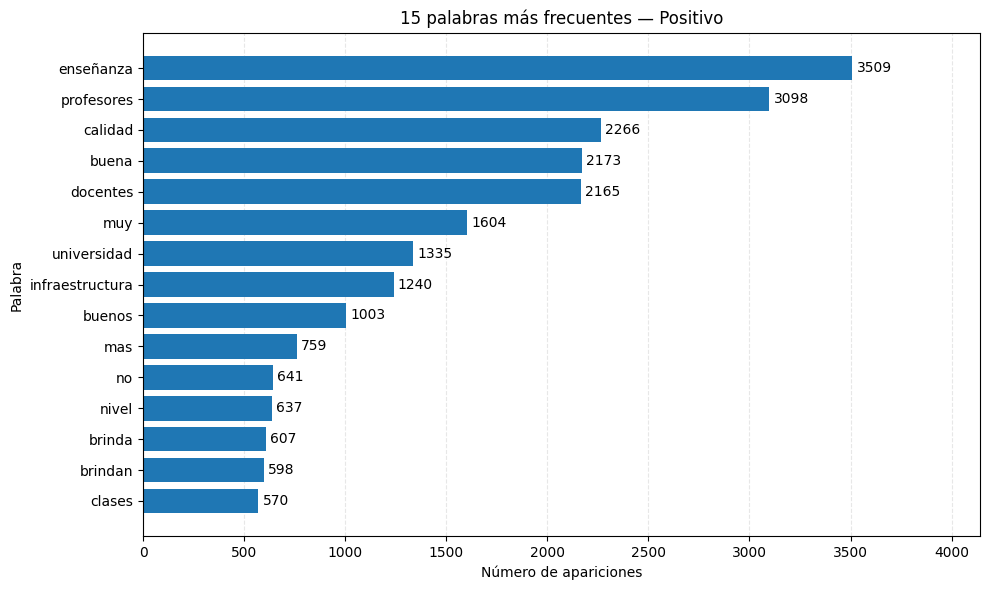

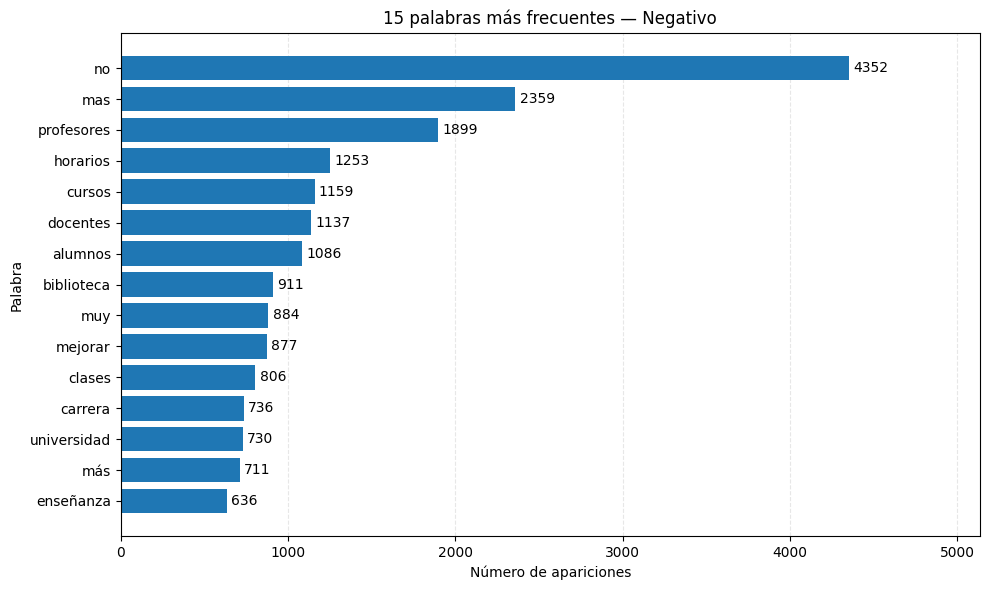

In [ ]:
for sentiment in ["Positivo", "Negativo"]:

    # Orden ascendente para representar la mayor frecuencia arriba
    plot_data = (
        top_unigrams_eda[sentiment]
        .sort_values("Frecuencia", ascending=True)
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    bars = ax.barh(
        plot_data["Término"],
        plot_data["Frecuencia"]
    )

    ax.bar_label(bars, padding=3)

    ax.set_title(
        f"15 palabras más frecuentes — {sentiment}"
    )
    ax.set_xlabel("Número de apariciones")
    ax.set_ylabel("Palabra")

    ax.set_xlim(
        0,
        plot_data["Frecuencia"].max() * 1.18
    )

    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

##### Interpretación de los unigramas

El análisis de unigramas permitió identificar diferencias en el vocabulario utilizado en los comentarios positivos y negativos.

En los comentarios **positivos**, las palabras más frecuentes incluyen `enseñanza` (3.509 apariciones), `profesores` (3.098), `calidad` (2.266) y `buena` (2.173). Estos resultados evidencian una presencia recurrente de vocabulario relacionado con la enseñanza, los docentes y las valoraciones académicas.

Por su parte, en los comentarios **negativos** destaca principalmente `no`, con 4.352 apariciones, seguida de `mas` (2.359), `profesores` (1.899) y `horarios` (1.253). La elevada frecuencia de `no` sugiere que las estructuras de negación constituyen un elemento lingüístico relevante dentro de esta clase.

Asimismo, se identificaron palabras compartidas entre ambos sentimientos, como `profesores`, `docentes` y `enseñanza`. Esto demuestra que la presencia de una palabra aislada no determina necesariamente el sentimiento del comentario, pues su interpretación depende del contexto.

Las frecuencias relativas permiten comparar el uso del vocabulario considerando las diferencias en la cantidad total de palabras de cada clase.

**Conclusión preliminar:** existen diferencias descriptivas en el vocabulario utilizado por sentimiento, pero los unigramas no siempre proporcionan suficiente información contextual. Por ello, se complementará este análisis mediante bigramas, que permiten estudiar expresiones formadas por dos palabras consecutivas.

#### Expresiones más frecuentes por sentimiento (bigramas)

Además de las palabras individuales, se analizarán los bigramas, es decir, secuencias de dos palabras consecutivas.

Este análisis permite recuperar una parte del contexto lingüístico que se pierde al estudiar palabras aisladas. Por ejemplo, las expresiones `muy bueno` y `no explica` contienen información que no se aprecia completamente mediante el conteo independiente de sus términos.

Para conservar la estructura original de las expresiones, los bigramas se construirán sin eliminar previamente las palabras vacías. Posteriormente, se excluirán del resumen aquellos pares compuestos exclusivamente por palabras vacías.

Se identificarán los 15 bigramas más frecuentes de cada sentimiento, utilizando tanto frecuencias absolutas como relativas.

In [ ]:
# Construir bigramas manteniendo las palabras consecutivas
bigram_vectorizer_eda = CountVectorizer(
    lowercase=True,
    strip_accents=None,
    token_pattern=token_pattern_38,
    stop_words=None,
    ngram_range=(2, 2)
)

X_bigrams_eda = bigram_vectorizer_eda.fit_transform(
    texts_eda_38
)

bigram_terms_eda = bigram_vectorizer_eda.get_feature_names_out()

# Excluir solamente los bigramas donde AMBAS palabras
# pertenecen a nuestra lista de palabras vacías
eligible_bigrams_eda = np.array([
    not all(
        word in spanish_stopwords_38
        for word in bigram.split()
    )
    for bigram in bigram_terms_eda
])

# Frecuencias de cada bigrama por sentimiento
bigram_counts_eda = {
    sentiment: np.asarray(
        X_bigrams_eda[mask].sum(axis=0)
    ).ravel()
    for sentiment, mask in sentiment_masks_38.items()
}

# Obtener los principales bigramas
top_bigrams_eda = {
    sentiment: top_ngram_table(
        counts=bigram_counts_eda[sentiment],
        terms=bigram_terms_eda,
        eligible_mask=eligible_bigrams_eda,
        top_n=15
    )
    for sentiment in sentiment_masks_38
}

print("15 bigramas más frecuentes — Positivo")
display(top_bigrams_eda["Positivo"])

print("15 bigramas más frecuentes — Negativo")
display(top_bigrams_eda["Negativo"])

15 bigramas más frecuentes — Positivo


,Término,Frecuencia,Por cada 1.000 apariciones
0,los profesores,1835,15.26
1,calidad de,1478,12.29
2,la calidad,1455,12.10
3,la enseñanza,1367,11.36
4,de enseñanza,1203,10.00
5,los docentes,1147,9.54
6,la universidad,749,6.23
7,la buena,559,4.65
8,enseñanza de,496,4.12
9,es muy,495,4.12


15 bigramas más frecuentes — Negativo


,Término,Frecuencia,Por cada 1.000 apariciones
0,los profesores,790,5.20
1,que no,666,4.39
2,los alumnos,648,4.27
3,la biblioteca,606,3.99
4,los horarios,597,3.93
5,la universidad,560,3.69
6,los cursos,451,2.97
7,los docentes,409,2.69
8,algunos profesores,399,2.63
9,calidad de,398,2.62


##### Visualización de los bigramas más frecuentes

Se elaborarán gráficos de barras horizontales con los 15 bigramas más frecuentes de cada sentimiento.

Estos gráficos permitirán identificar expresiones recurrentes dentro de los comentarios estudiantiles y complementar el análisis de palabras individuales.

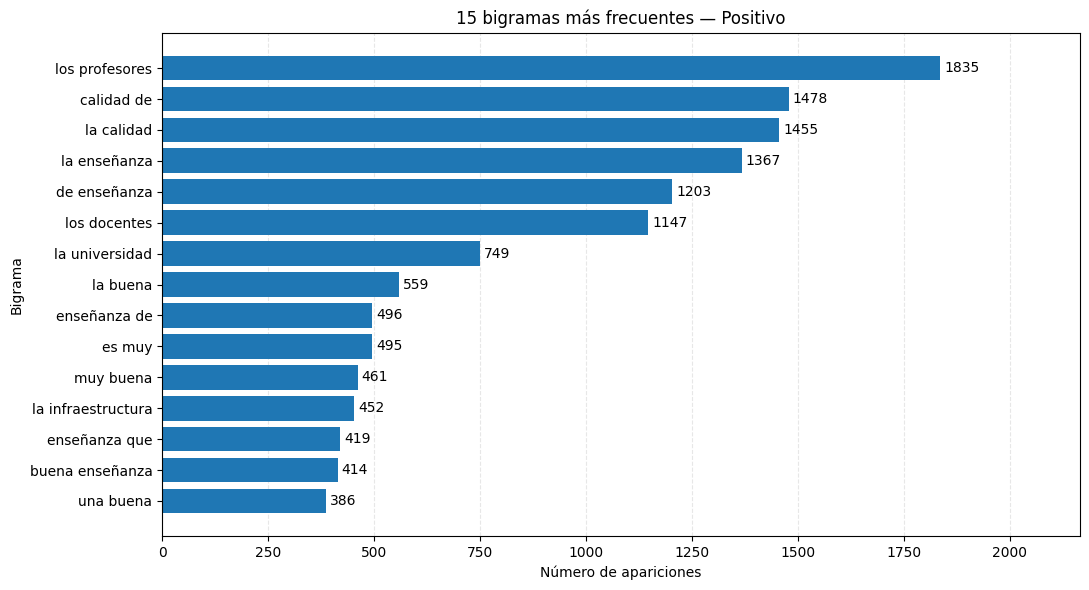

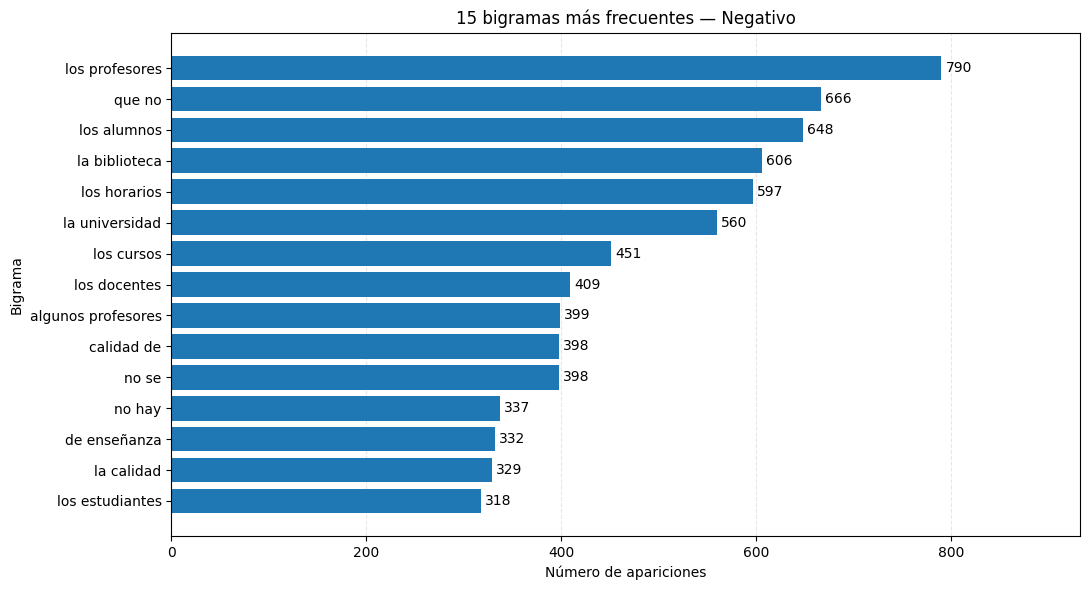

In [ ]:
for sentiment in ["Positivo", "Negativo"]:

    plot_data = (
        top_bigrams_eda[sentiment]
        .sort_values("Frecuencia", ascending=True)
    )

    fig, ax = plt.subplots(figsize=(11, 6))

    bars = ax.barh(
        plot_data["Término"],
        plot_data["Frecuencia"]
    )

    ax.bar_label(bars, padding=3)

    ax.set_title(
        f"15 bigramas más frecuentes — {sentiment}"
    )
    ax.set_xlabel("Número de apariciones")
    ax.set_ylabel("Bigrama")

    ax.set_xlim(
        0,
        plot_data["Frecuencia"].max() * 1.18
    )

    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

##### Interpretación de los bigramas

El análisis de bigramas permitió identificar expresiones recurrentes en los comentarios positivos y negativos, complementando la información obtenida mediante los unigramas.

En los comentarios **positivos** destacan expresiones relacionadas con la enseñanza y la calidad académica, como `calidad de` (1.478 apariciones), `la enseñanza` (1.367), `muy buena` (461) y `buena enseñanza` (414). Las dos últimas contienen elementos valorativos que permiten observar con mayor claridad expresiones de sentimiento favorable.

En los comentarios **negativos** sobresalen estructuras de negación como `que no` (666 apariciones), `no se` (398) y `no hay` (337). Estos resultados complementan el análisis de unigramas, donde `no` fue la palabra más frecuente de esta clase, y evidencian la importancia de preservar las negaciones durante el procesamiento textual.

También se identificaron expresiones compartidas, como `los profesores`, presente en ambas clases, aunque con diferentes frecuencias relativas. Esto demuestra que los bigramas pueden representar temas comunes sin determinar necesariamente un sentimiento específico.

**Conclusión preliminar:** los bigramas aportan información contextual adicional respecto a las palabras individuales y permiten reconocer expresiones valorativas y estructuras de negación. Sin embargo, su frecuencia no demuestra por sí sola capacidad predictiva, dado que el sentimiento también depende del contexto completo del comentario.

#### Comparación de frecuencias relativas entre sentimientos

Se compararán las frecuencias relativas de las palabras que aparecen entre los diez unigramas más frecuentes de cualquiera de las dos clases.

Para cada término se calculará su frecuencia por cada 1.000 apariciones de palabras contabilizadas en los comentarios positivos y negativos.

Este procedimiento permitirá observar diferencias descriptivas en el uso del vocabulario, reduciendo el efecto de las diferencias en el volumen total de texto disponible por clase.

Las diferencias de frecuencia no deben interpretarse automáticamente como evidencia de capacidad predictiva ni como exclusividad de una palabra respecto a determinado sentimiento.

In [ ]:
# Seleccionar la unión de los 10 unigramas principales de cada clase
selected_terms_eda = list(dict.fromkeys(
    top_unigrams_eda["Positivo"]["Término"].head(10).tolist()
    +
    top_unigrams_eda["Negativo"]["Término"].head(10).tolist()
))

# Totales de apariciones por sentimiento
unigram_totals_eda = {
    sentiment: int(counts.sum())
    for sentiment, counts in unigram_counts_eda.items()
}

# Obtener índice del vocabulario
unigram_vocabulary_eda = unigram_vectorizer_eda.vocabulary_

comparison_rows_eda = []

for term in selected_terms_eda:

    term_index = unigram_vocabulary_eda[term]

    positive_count = int(
        unigram_counts_eda["Positivo"][term_index]
    )

    negative_count = int(
        unigram_counts_eda["Negativo"][term_index]
    )

    positive_rate = (
        positive_count
        / unigram_totals_eda["Positivo"]
        * 1000
    )

    negative_rate = (
        negative_count
        / unigram_totals_eda["Negativo"]
        * 1000
    )

    comparison_rows_eda.append({
        "Término": term,
        "Positivo (por 1.000)": positive_rate,
        "Negativo (por 1.000)": negative_rate,
        "Diferencia (Pos. - Neg.)": (
            positive_rate - negative_rate
        )
    })

unigram_comparison_eda = pd.DataFrame(
    comparison_rows_eda
)

# Ordenar por la mayor frecuencia relativa observada
unigram_comparison_eda["Máxima frecuencia relativa"] = (
    unigram_comparison_eda[
        ["Positivo (por 1.000)", "Negativo (por 1.000)"]
    ].max(axis=1)
)

unigram_comparison_eda = (
    unigram_comparison_eda
    .sort_values(
        "Máxima frecuencia relativa",
        ascending=False
    )
    .drop(columns="Máxima frecuencia relativa")
    .reset_index(drop=True)
    .round(2)
)

display(unigram_comparison_eda)

,Término,Positivo (por 1.000),Negativo (por 1.000),Diferencia (Pos. - Neg.)
0,enseñanza,41.72,5.90,35.82
1,no,7.62,40.40,-32.78
2,profesores,36.84,17.63,19.21
3,calidad,26.94,5.56,21.38
4,buena,25.84,2.01,23.83
5,docentes,25.74,10.56,15.19
6,mas,9.03,21.90,-12.88
7,muy,19.07,8.21,10.87
8,universidad,15.87,6.78,9.10
9,infraestructura,14.74,5.50,9.25


##### Interpretación de la comparación de frecuencias relativas

La comparación de frecuencias relativas permitió identificar diferencias en el uso proporcional de determinadas palabras entre los comentarios positivos y negativos, considerando el total de apariciones de palabras contabilizadas en cada clase.

En los comentarios **positivos** destacan términos como `enseñanza` (41,72 frente a 5,90 por cada 1.000 apariciones), `buena` (25,84 frente a 2,01) y `calidad` (26,94 frente a 5,56), que presentan frecuencias relativas superiores a las registradas en los comentarios negativos.

Por su parte, en los comentarios **negativos** destaca especialmente la palabra `no`, con 40,40 apariciones por cada 1.000, frente a 7,62 en los positivos. Esta diferencia refuerza la relevancia de conservar las negaciones durante el procesamiento textual, en concordancia con las estructuras observadas anteriormente en el análisis de bigramas.

Asimismo, términos como `horarios`, `cursos`, `biblioteca` y `mejorar` muestran una mayor frecuencia relativa dentro de los comentarios negativos, mientras que palabras como `profesores` y `docentes` aparecen en ambas clases, aunque con diferentes proporciones.

Estos resultados permiten identificar diferencias descriptivas en el vocabulario asociado a cada sentimiento. Sin embargo, una mayor frecuencia relativa no implica que una palabra sea exclusiva de determinada clase ni garantiza su capacidad para predecir correctamente el sentimiento de un comentario.

**Conclusión:** la comparación evidencia diferencias en el uso proporcional del vocabulario y confirma la importancia de considerar el contexto lingüístico, especialmente las negaciones. Estos hallazgos servirán como referencia exploratoria para el modelado posterior, sin utilizar las frecuencias obtenidas sobre el dataset completo para ajustar los modelos definitivos.

#### Interpretación general

El análisis de unigramas y bigramas permitió identificar diferencias en el vocabulario y las expresiones utilizadas en los comentarios estudiantiles según su etiqueta de sentimiento.

En los comentarios **positivos** destacan palabras como `enseñanza`, `profesores`, `calidad` y `buena`, así como expresiones como `muy buena` y `buena enseñanza`. Estos resultados evidencian una presencia recurrente de vocabulario relacionado con la enseñanza, los docentes y las valoraciones favorables.

Por su parte, en los comentarios **negativos** destaca especialmente la palabra `no`, con 4.352 apariciones. Este hallazgo se complementa con la presencia de bigramas como `que no`, `no se` y `no hay`, lo que pone de manifiesto la importancia de las estructuras de negación dentro de esta clase.

La comparación de frecuencias relativas permitió observar que `enseñanza`, `buena` y `calidad` tienen una mayor presencia proporcional en los comentarios positivos, mientras que `no`, `horarios`, `cursos` y `mejorar` presentan una mayor frecuencia relativa en los negativos.

Asimismo, se identificaron términos y expresiones compartidos entre ambas clases, como `profesores`, `docentes` y `los profesores`. Esto demuestra que una palabra o expresión frecuente no determina necesariamente el sentimiento, ya que su interpretación depende del contexto completo del comentario.

**Conclusión:** existen diferencias descriptivas en el vocabulario utilizado por sentimiento. Los bigramas complementan el análisis de palabras individuales al conservar parte del contexto lingüístico, especialmente en expresiones valorativas y estructuras de negación.

**Decisión preliminar:** preservar las negaciones y evitar eliminar indiscriminadamente elementos que puedan aportar información semántica. El análisis realizado es exclusivamente exploratorio: no se modifican los comentarios originales ni se reutilizarán los vectorizadores ajustados sobre el dataset completo. Las representaciones definitivas se construirán posteriormente utilizando únicamente los datos de entrenamiento, para evitar fuga de información.

## Resultado de la etapa 3

El Análisis Exploratorio de Datos (EDA) permitió caracterizar los **23.168 comentarios estudiantiles**, identificar particularidades de su contenido textual y obtener evidencia para fundamentar las decisiones posteriores de limpieza, preparación y modelado.

### Principales hallazgos

| Dimensión analizada | Resultado |
|---|---|
| Distribución del sentimiento | 13.342 comentarios positivos (57,59 %) y 9.826 negativos (42,41 %), evidenciando un desbalance moderado. |
| Longitud de los comentarios | Predominan los textos breves, con una mediana de 10 palabras y una media de 15,25. El 90 % contiene 30 palabras o menos. |
| Duplicados exactos | Se identificó un único texto repetido (`#¿NOMBRE?`), presente en dos registros y con un duplicado excedente. |
| Consistencia de etiquetas | No se encontraron etiquetas contradictorias entre los comentarios duplicados. |
| Ruido textual | El 15,24 % de los comentarios presenta al menos una señal de posible irregularidad. La más frecuente corresponde a espacios repetidos (11,44 %). |
| Aspectos temáticos | Se identificaron cuatro aspectos, siendo Docentes el más representado (33,12 %) y Percepción General el de menor participación (16,66 %). |
| Aspecto y sentimiento | Las proporciones varían entre aspectos: Docentes presenta un 72,63 % de comentarios positivos, mientras que Experiencia Académica registra un 54,34 % de negativos. |
| Análisis lingüístico | Los unigramas y bigramas muestran diferencias descriptivas en el vocabulario de ambas clases. Destaca la presencia de `no` y de estructuras de negación en los comentarios negativos. |

### Implicaciones para la preparación y el modelado

Los resultados permiten establecer las siguientes consideraciones metodológicas:

1. **Distribución de datos:** realizar una división estratificada en entrenamiento, validación y prueba, conservando aproximadamente las proporciones originales de sentimiento. Se utilizará F1-macro como métrica principal de evaluación, complementada con accuracy, precision y recall.

2. **Calidad de los registros:** revisar el contenido anómalo `#¿NOMBRE?` y resolver su tratamiento antes de dividir los datos, evitando que textos idénticos aparezcan simultáneamente en diferentes conjuntos.

3. **Preparación textual:** considerar una limpieza selectiva, priorizando la normalización de espacios y la revisión de posibles errores de escritura. Se evitará eliminar indiscriminadamente tildes, números, símbolos, signos de puntuación y negaciones, debido a que pueden conservar información relevante para el sentimiento.

4. **Representación del texto:** preservar los comentarios originales y definir el preprocesamiento correspondiente a cada enfoque. Los vectorizadores y demás transformaciones que requieran ajuste deberán entrenarse exclusivamente con el conjunto de entrenamiento, evitando fugas de información.

5. **Contexto temático:** conservar `nombreAspecto` como información contextual para comprender el corpus, manteniendo como objetivo principal la predicción de `Valor` a partir del contenido textual del comentario.

### Conclusión de la etapa

El EDA evidencia que el dataset contiene una cantidad considerable de observaciones de ambas clases, predominio de comentarios breves, una presencia mínima de duplicados exactos y determinadas irregularidades textuales que requieren un tratamiento selectivo.

Asimismo, se identificaron diferencias en la distribución del sentimiento por aspecto temático y patrones lingüísticos relevantes, especialmente relacionados con las estructuras de negación.

**La etapa exploratoria se completa sin modificar el dataset original.** Sus resultados constituyen la base para iniciar la siguiente fase: limpieza y preparación de los datos, previa a la implementación y comparación del modelo base TF-IDF + Regresión Logística y el Transformer preentrenado.

## 4. Limpieza y preparación de los datos

Una vez completada la exploración y análisis de datos (EDA), se procederá a la limpieza y preparación del dataset, utilizando los hallazgos de la etapa anterior como fundamento para las decisiones metodológicas.

El objetivo de esta etapa es obtener un conjunto de datos depurado, consistente y reproducible, que pueda utilizarse como base común para los dos enfoques de clasificación de sentimiento que se compararán:

- **Modelo base:** TF-IDF + Regresión Logística.
- **Modelo principal:** Transformer preentrenado mediante fine-tuning.

La preparación comprenderá la revisión de registros anómalos y duplicados, la aplicación de una normalización textual mínima, la codificación de la variable objetivo y la división de los datos en conjuntos de entrenamiento, validación y prueba.

Se adoptará un enfoque de **limpieza conservadora**, procurando corregir irregularidades justificadas sin eliminar información lingüística potencialmente relevante para la clasificación de sentimiento.

Asimismo, se preservará el dataset original y se documentarán las modificaciones realizadas, garantizando la trazabilidad y reproducibilidad del procedimiento.

### Organización de la etapa

| Apartado | Actividad |
|---|---|
| 4.1 | Definición de criterios de limpieza. |
| 4.2 | Tratamiento de registros anómalos y duplicados. |
| 4.3 | Normalización textual mínima. |
| 4.4 | Preparación de la variable objetivo. |
| 4.5 | División en entrenamiento, validación y prueba. |
| 4.6 | Verificación final y exportación de los conjuntos preparados. |

Las transformaciones específicas de cada enfoque, como la vectorización TF-IDF y la tokenización del Transformer, se realizarán posteriormente durante sus respectivas etapas de modelado.

### 4.1 Definición de criterios de limpieza

Antes de modificar el dataset, se establecen los criterios que orientarán su limpieza y preparación, tomando como referencia los resultados obtenidos durante el Análisis Exploratorio de Datos (EDA).

El propósito es garantizar que las transformaciones realizadas respondan a necesidades identificadas en los datos, evitando modificaciones arbitrarias que puedan alterar el significado de los comentarios estudiantiles.

#### Criterios establecidos a partir del EDA

| Hallazgo del EDA | Criterio de preparación |
|---|---|
| Distribución moderadamente desbalanceada: 57,59 % de comentarios positivos y 42,41 % negativos. | Conservar la distribución original de las clases y realizar una división estratificada. No aplicar técnicas de balanceo artificial en esta etapa. |
| Predominio de comentarios breves, con una mediana de 10 palabras. | No eliminar ni truncar observaciones únicamente por su longitud. |
| Presencia de un duplicado exacto correspondiente a `#¿NOMBRE?`. | Revisar su validez como comentario estudiantil y documentar su tratamiento antes de dividir los datos. |
| Ausencia de contradicciones de sentimiento entre los duplicados exactos identificados. | Repetir la verificación de duplicados y consistencia de etiquetas después de la normalización textual. |
| Espacios repetidos presentes en el 11,44 % de los comentarios. | Aplicar una normalización mínima de espacios innecesarios. |
| Identificación de posibles errores de escritura, como `do3ntes` y `bu3nos`. | No realizar correcciones ortográficas automáticas, debido al riesgo de alterar el contenido original. |
| Presencia de números, símbolos y signos de puntuación potencialmente expresivos. | Conservar estos elementos inicialmente y evitar su eliminación indiscriminada. |
| El 80,15 % de los comentarios no contiene vocales acentuadas. | Preservar las tildes existentes. No interpretar su ausencia como evidencia automática de errores ortográficos. |
| Presencia destacada de `no` y estructuras de negación en los comentarios negativos. | Preservar las negaciones y evitar transformaciones que puedan modificar el sentido de las opiniones. |
| Distribución temática diferenciada entre los cuatro aspectos académicos. | Conservar `nombreAspecto` como información contextual, sin incorporarlo como variable predictora en el problema definido. |

#### Principios metodológicos de preparación

A partir de los criterios anteriores, se establecen las siguientes directrices:

1. **Preservación de los datos originales.** Todas las operaciones se realizarán sobre una copia del dataset, manteniendo disponible la información original para su consulta y verificación.

2. **Tratamiento documentado de registros anómalos.** Se revisarán los contenidos que no representen opiniones estudiantiles interpretables. Cualquier exclusión deberá contar con una justificación explícita y registrar la cantidad de observaciones afectadas.

3. **Control de duplicados.** Se comprobará la presencia de comentarios idénticos o equivalentes después de la normalización mínima. Antes de resolverlos, se verificará la consistencia de sus etiquetas para evitar introducir contradicciones o fugas de información entre los conjuntos.

4. **Normalización textual conservadora.** Se priorizarán las correcciones de formato, como los espacios innecesarios, sin eliminar automáticamente tildes, puntuación, símbolos, números o negaciones.

5. **Preparación de la variable objetivo.** Se mantendrá `Valor` como etiqueta de sentimiento y se establecerá una codificación común: `Negativo = 0` y `Positivo = 1`.

6. **División reproducible de los datos.** Una vez finalizada la limpieza, se utilizará una distribución de **70 % para entrenamiento, 15 % para validación y 15 % para prueba**, con semilla aleatoria `42` y estratificación por sentimiento. Se verificará que no existan comentarios equivalentes compartidos entre los conjuntos.

7. **Prevención de fuga de información.** Las transformaciones que requieran aprender parámetros o construir vocabularios se ajustarán exclusivamente con los datos de entrenamiento. El conjunto de prueba permanecerá reservado para la evaluación final.

8. **Consistencia entre los modelos.** Ambos enfoques utilizarán los mismos registros de entrenamiento, validación y prueba. El preprocesamiento específico de TF-IDF y del Transformer se implementará posteriormente en sus respectivas etapas.

#### Resultado esperado del apartado

Se establece un conjunto de criterios metodológicos fundamentados en los hallazgos del EDA, que servirá como referencia para ejecutar y verificar las operaciones posteriores de limpieza y preparación.

**En esta sección todavía no se modifica el dataset.** La aplicación de los criterios comenzará en el apartado 4.2, donde se revisarán los registros anómalos y los duplicados identificados.

### 4.2 Tratamiento de registros anómalos y duplicados

A partir de los hallazgos del EDA y los criterios establecidos en 4.1, se procederá a revisar y tratar los registros anómalos y duplicados identificados en el dataset.

El objetivo es resolver los casos que puedan afectar la calidad de los datos o introducir problemas durante el modelado, mediante decisiones justificadas y verificables.

El procedimiento se realizará de manera incremental:

1. Crear una copia de trabajo y registrar el estado inicial del dataset.
2. Revisar los registros anómalos identificados durante el EDA.
3. Aplicar y documentar los tratamientos justificados.
4. Comprobar nuevamente la existencia de duplicados exactos y la consistencia de sus etiquetas.
5. Verificar la integridad del dataset resultante y resumir los cambios realizados.

Se preservará el dataset original y se registrará la cantidad de observaciones afectadas por cada operación.

**Importante:** en esta etapa no se realizará una eliminación generalizada de comentarios. Cada tratamiento deberá responder a un criterio explícito y contar con una verificación posterior.

#### 4.2.1 Creación de una copia de trabajo y registro del estado inicial

Antes de aplicar cualquier modificación, se creará una copia independiente del DataFrame original (`df`), denominada `df_clean`.

Todas las operaciones posteriores de limpieza se realizarán sobre esta copia, preservando el dataset original para consultas, comparaciones y verificaciones.

Asimismo, se registrará el estado inicial de los datos, considerando:

- Cantidad total de registros y columnas.
- Nombres de las variables disponibles.
- Distribución de la variable objetivo `Valor`.
- Comprobación de que la copia conserva el contenido del dataset original.

Esta información servirá como referencia para documentar las modificaciones realizadas y verificar posteriormente su impacto sobre el número de observaciones y la distribución de las clases.

In [ ]:
# Crear una copia independiente del dataset original
df_clean = df.copy(deep=True)

# Registrar las características iniciales
initial_count_42 = len(df_clean)
initial_columns_42 = df_clean.columns.tolist()

# Inicializar el registro de las operaciones de limpieza
cleaning_log_42 = []

# Mostrar el estado inicial
initial_summary_42 = pd.DataFrame({
    "Característica": [
        "Total de registros",
        "Total de columnas",
        "Variables disponibles"
    ],
    "Resultado": [
        initial_count_42,
        len(initial_columns_42),
        ", ".join(initial_columns_42)
    ]
})

print("Estado inicial del dataset:")
display(initial_summary_42)

# Registrar la distribución inicial de sentimiento
initial_sentiment_42 = (
    df_clean["Valor"]
    .value_counts(dropna=False)
    .rename_axis("Sentimiento")
    .reset_index(name="Cantidad")
)

initial_sentiment_42["Porcentaje (%)"] = (
    initial_sentiment_42["Cantidad"]
    / initial_count_42
    * 100
).round(2)

print("\nDistribución inicial del sentimiento:")
display(initial_sentiment_42)

# Verificar que la copia conserva los datos originales
assert df_clean.equals(df), (
    "La copia de trabajo no coincide con el dataset original."
)

print("\nVerificación correcta: df_clean conserva el contenido de df.")

Estado inicial del dataset:


,Característica,Resultado
0,Total de registros,23168
1,Total de columnas,3
2,Variables disponibles,"comentario, Valor, nombreAspecto"



Distribución inicial del sentimiento:


,Sentimiento,Cantidad,Porcentaje (%)
0,Positivo,13342,57.59
1,Negativo,9826,42.41



Verificación correcta: df_clean conserva el contenido de df.


#### 4.2.2 Revisión de los registros anómalos identificados

Durante el análisis exploratorio se identificó el texto `#¿NOMBRE?`, presente en dos registros y clasificado como `Negativo` en ambas apariciones.

Aunque este contenido no presenta contradicciones de etiquetado, su estructura resulta anómala respecto a los comentarios estudiantiles, por lo que requiere una revisión específica antes de continuar con la preparación.

En este subapartado se realizarán las siguientes comprobaciones:

- Identificar todas las apariciones del marcador.
- Recuperar sus registros originales y los índices correspondientes.
- Examinar sus etiquetas de sentimiento y aspectos temáticos.
- Verificar si existen diferencias textuales entre sus apariciones.

La identificación se limitará al marcador observado durante el EDA, evitando clasificar automáticamente como inválidos otros comentarios que contengan símbolos o formatos inusuales.

**En esta etapa únicamente se inspeccionarán los registros.** La decisión sobre su conservación o exclusión se documentará y ejecutará en el apartado 4.2.3.

In [ ]:
# Marcador anómalo identificado durante el EDA
anomalous_marker_42 = "#¿NOMBRE?"

# Identificar las apariciones del marcador
anomalous_mask_42 = (
    df_clean["comentario"]
    .astype("string")
    .str.strip()
    .str.upper()
    .eq(anomalous_marker_42)
    .fillna(False)
)

# Recuperar los registros completos identificados
anomalous_records_42 = df_clean.loc[
    anomalous_mask_42
].copy()

# Conservar el índice original para facilitar la trazabilidad
anomalous_records_42.insert(
    0,
    "indice_original",
    anomalous_records_42.index
)

print(
    "Total de registros identificados:",
    len(anomalous_records_42)
)

# Mostrar los registros encontrados
if anomalous_records_42.empty:
    print("No se encontraron registros con el marcador indicado.")
else:
    display(
        anomalous_records_42[
            [
                "indice_original",
                "comentario",
                "Valor",
                "nombreAspecto"
            ]
        ]
    )

Total de registros identificados: 2


,indice_original,comentario,Valor,nombreAspecto
152,152,#¿NOMBRE?,Negativo,Docentes
15596,15596,#¿NOMBRE?,Negativo,Docentes


##### Verificación del contenido original y la consistencia de las etiquetas

Se examinará el contenido exacto de cada registro identificado para comprobar si las apariciones del marcador presentan diferencias de formato que no resulten evidentes en la visualización habitual del DataFrame.

También se resumirá la distribución de las etiquetas de sentimiento y los aspectos temáticos asociados a estos registros.

Esta revisión permitirá fundamentar la decisión de tratamiento y conservar evidencia de los datos originales antes de realizar cualquier exclusión.

In [ ]:
# Mostrar el contenido exacto de los comentarios identificados
print("Contenido textual de los registros encontrados:")

if anomalous_records_42.empty:
    print("No se encontraron registros para revisar.")

else:
    for idx, comentario in anomalous_records_42[
        "comentario"
    ].items():

        print(
            f"Índice {idx}: {comentario!r}"
        )

    # Resumen de las etiquetas de sentimiento
    print("\nDistribución de etiquetas:")

    display(
        anomalous_records_42["Valor"]
        .value_counts(dropna=False)
        .rename_axis("Sentimiento")
        .reset_index(name="Cantidad")
    )

    # Resumen de los aspectos temáticos
    print("\nDistribución de aspectos temáticos:")

    display(
        anomalous_records_42["nombreAspecto"]
        .value_counts(dropna=False)
        .rename_axis("Aspecto")
        .reset_index(name="Cantidad")
    )

    # Verificar cuántas etiquetas distintas tiene el marcador
    n_labels_42 = anomalous_records_42["Valor"].nunique(
        dropna=False
    )

    print(
        "\nNúmero de etiquetas distintas:",
        n_labels_42
    )

Contenido textual de los registros encontrados:
Índice 152: '#¿NOMBRE?'
Índice 15596: '#¿NOMBRE?'

Distribución de etiquetas:


,Sentimiento,Cantidad
0,Negativo,2



Distribución de aspectos temáticos:


,Aspecto,Cantidad
0,Docentes,2



Número de etiquetas distintas: 1


##### Interpretación de la revisión

La inspección identificó dos registros cuyo contenido textual es exactamente `#¿NOMBRE?`, ambos asociados al sentimiento `Negativo` y al aspecto temático `Docentes`.

Este marcador coincide con un mensaje de error reconocido de Microsoft Excel, que puede aparecer cuando una fórmula contiene elementos que el programa no consigue interpretar. Su presencia en el dataset sugiere una posible anomalía originada durante el procesamiento de los datos, aunque no es posible determinar su causa exacta ni recuperar el comentario original con la información disponible.

Si bien ambos registros presentan etiquetas consistentes, su contenido no constituye una opinión estudiantil interpretable. Por tanto, conservarlos introduciría observaciones cuya etiqueta de sentimiento no puede justificarse a partir del texto disponible.

**Decisión:** excluir las dos apariciones de `#¿NOMBRE?` del dataset destinado al modelado, conservando su identificación y documentando el motivo de exclusión.

Esta decisión afecta únicamente a los dos registros identificados y no implica eliminar automáticamente otros comentarios que contengan símbolos o formatos inusuales.

#### 4.2.3 Tratamiento justificado de los registros anómalos

A partir de la revisión efectuada en 4.2.2, se determinó que las dos apariciones de `#¿NOMBRE?` no constituyen comentarios estudiantiles interpretables.

Aunque ambas observaciones presentan etiquetas consistentes (`Negativo`) y pertenecen al aspecto `Docentes`, su contenido coincide con el formato de un mensaje de error de Microsoft Excel. Esto sugiere una posible anomalía durante el procesamiento de los datos, sin que sea posible determinar su origen exacto ni recuperar las opiniones originales con la información disponible.

Por tanto, se establece la siguiente decisión:

**Excluir ambas apariciones del dataset destinado al modelado**, conservando sus registros originales y documentando el motivo de la exclusión.

El tratamiento se realizará exclusivamente sobre `df_clean`, preservando `df` como referencia del dataset original.

Antes de ejecutar la exclusión, se registrarán los índices y el contenido de las observaciones afectadas. Posteriormente, se verificará que únicamente se hayan retirado los registros aprobados.

In [ ]:
# 4.2.3 — Registro y exclusión controlada de los comentarios anómalos

# Verificar el estado inicial de la copia de trabajo
assert df_clean.equals(df), (
    "df_clean ya presenta modificaciones. "
    "Revisar el estado de la copia antes de aplicar este tratamiento."
)

assert anomalous_mask_42.index.equals(df_clean.index), (
    "La máscara de registros anómalos no coincide con el índice de df_clean."
)

# Recuperar los registros que serán excluidos
excluded_records_42 = df_clean.loc[
    anomalous_mask_42
].copy()

# Verificar que se identificaron exactamente los dos casos revisados
assert len(excluded_records_42) == 2, (
    "La cantidad de registros anómalos no coincide con "
    "los dos casos identificados durante la revisión."
)

# Incorporar información para mantener la trazabilidad
excluded_records_42.insert(
    0,
    "indice_original",
    excluded_records_42.index
)

excluded_records_42["motivo_exclusion"] = (
    "Marcador #¿NOMBRE?: contenido textual no interpretable "
    "como opinión estudiantil."
)

print("Registros cuya exclusión ha sido aprobada:")

display(
    excluded_records_42[
        [
            "indice_original",
            "comentario",
            "Valor",
            "nombreAspecto",
            "motivo_exclusion"
        ]
    ]
)

# Registrar la cantidad anterior al tratamiento
records_before_423 = len(df_clean)

# Excluir únicamente los registros identificados
df_clean = df_clean.loc[
    ~anomalous_mask_42
].copy()

# Registrar el resultado de la operación
records_removed_423 = len(excluded_records_42)
records_after_423 = len(df_clean)

# Incorporar la operación al registro de limpieza
cleaning_log_42.append({
    "apartado": "4.2.3",
    "operacion": "Exclusión de registros anómalos",
    "criterio": "Marcador #¿NOMBRE? no interpretable",
    "registros_antes": records_before_423,
    "registros_afectados": records_removed_423,
    "registros_despues": records_after_423
})

print("\nResultado del tratamiento:")
print(f"Registros iniciales: {records_before_423:,}")
print(f"Registros excluidos: {records_removed_423:,}")
print(f"Registros restantes: {records_after_423:,}")

Registros cuya exclusión ha sido aprobada:


,indice_original,comentario,Valor,nombreAspecto,motivo_exclusion
152,152,#¿NOMBRE?,Negativo,Docentes,Marcador #¿NOMBRE?: contenido textual no inter...
15596,15596,#¿NOMBRE?,Negativo,Docentes,Marcador #¿NOMBRE?: contenido textual no inter...



Resultado del tratamiento:
Registros iniciales: 23,168
Registros excluidos: 2
Registros restantes: 23,166


##### Verificación del tratamiento aplicado

Después de ejecutar la exclusión, se comprobará que:

- El marcador `#¿NOMBRE?` ya no se encuentre en la copia de trabajo.
- El número de registros excluidos corresponda exactamente a los casos aprobados.
- El DataFrame original permanezca disponible sin modificaciones.
- Los registros restantes conserven su contenido y sus índices originales.

Esta comprobación permitirá verificar que el tratamiento se aplicó de manera controlada y no afectó accidentalmente a otras observaciones.

In [ ]:
# 4.2.3 — Verificación de la exclusión

# Comprobar si permanece alguna aparición del marcador
remaining_marker_mask_42 = (
    df_clean["comentario"]
    .astype("string")
    .str.strip()
    .str.upper()
    .eq(anomalous_marker_42)
    .fillna(False)
)

remaining_markers_42 = int(remaining_marker_mask_42.sum())

# Verificar las cantidades
assert records_removed_423 == 2, (
    "La cantidad de registros excluidos es inesperada."
)

assert records_after_423 == records_before_423 - records_removed_423, (
    "La cantidad final no coincide con las exclusiones registradas."
)

# Verificar la eliminación del marcador
assert remaining_markers_42 == 0, (
    "Todavía existen apariciones del marcador en df_clean."
)

# Verificar que el dataset original conserva su estado inicial
assert len(df) == initial_count_42, (
    "El número de registros del dataset original ha cambiado."
)

# Verificar que no se modificaron los registros conservados
assert df_clean.equals(df.loc[df_clean.index]), (
    "Se detectaron modificaciones adicionales en los registros conservados."
)

# Comprobar que los índices excluidos ya no estén en df_clean
assert not df_clean.index.isin(excluded_records_42.index).any(), (
    "Uno o más registros excluidos permanecen en la copia de trabajo."
)

verification_423 = pd.DataFrame({
    "Comprobación": [
        "Registros excluidos",
        "Apariciones restantes de #¿NOMBRE?",
        "Registros finales",
        "Registros originales conservados",
        "Integridad de los registros restantes"
    ],
    "Resultado": [
        records_removed_423,
        remaining_markers_42,
        len(df_clean),
        len(df),
        "Correcta"
    ]
})

display(verification_423)

print("Verificación correcta: exclusión aplicada sin cambios adicionales.")

,Comprobación,Resultado
0,Registros excluidos,2
1,Apariciones restantes de #¿NOMBRE?,0
2,Registros finales,23166
3,Registros originales conservados,23168
4,Integridad de los registros restantes,Correcta


Verificación correcta: exclusión aplicada sin cambios adicionales.


#### 4.2.4 Verificación de duplicados exactos y consistencia de etiquetas

Después del tratamiento de los registros anómalos, se repetirá el análisis de duplicados exactos utilizando la copia de trabajo (`df_clean`).

El objetivo es comprobar si permanecen comentarios idénticos y verificar la consistencia de sus etiquetas de sentimiento.

Se calcularán las siguientes medidas:

- Textos distintos que aparecen más de una vez.
- Registros involucrados en repeticiones.
- Duplicados excedentes.
- Textos repetidos con etiquetas contradictorias.

En caso de encontrarse nuevos duplicados, se revisarán antes de decidir su tratamiento. No se aplicará una eliminación automática de observaciones.

**Alcance:** esta comprobación considera la igualdad exacta del texto en su estado actual. Tras la normalización textual del apartado 4.3, se repetirá el análisis para identificar posibles equivalencias originadas por diferencias de formato.

In [ ]:
# 4.2.4 — Verificación de duplicados exactos después del tratamiento

# Identificar todas las apariciones de comentarios repetidos
remaining_duplicate_mask_42 = df_clean.duplicated(
    subset=["comentario"],
    keep=False
)

# Obtener los registros involucrados
remaining_duplicated_records_42 = df_clean.loc[
    remaining_duplicate_mask_42,
    ["comentario", "Valor", "nombreAspecto"]
].copy()

# Calcular las medidas de duplicación
remaining_repeated_texts_42 = int(
    remaining_duplicated_records_42["comentario"].nunique(
        dropna=False
    )
)

remaining_repeated_rows_42 = int(
    remaining_duplicate_mask_42.sum()
)

remaining_duplicate_excess_42 = int(
    df_clean.duplicated(
        subset=["comentario"],
        keep="first"
    ).sum()
)

duplicate_summary_424 = pd.DataFrame({
    "Medida": [
        "Registros analizados",
        "Textos distintos repetidos",
        "Registros involucrados en repeticiones",
        "Duplicados excedentes"
    ],
    "Resultado": [
        len(df_clean),
        remaining_repeated_texts_42,
        remaining_repeated_rows_42,
        remaining_duplicate_excess_42
    ]
})

print("Resumen de duplicados exactos:")
display(duplicate_summary_424)

print("\nRegistros repetidos encontrados:")

if remaining_duplicated_records_42.empty:
    print("No se encontraron duplicados exactos.")
else:
    display(remaining_duplicated_records_42)

Resumen de duplicados exactos:


,Medida,Resultado
0,Registros analizados,23166
1,Textos distintos repetidos,0
2,Registros involucrados en repeticiones,0
3,Duplicados excedentes,0



Registros repetidos encontrados:
No se encontraron duplicados exactos.


##### Verificación de consistencia de etiquetas

Si permanecen comentarios duplicados, se comprobará cuántas etiquetas distintas tiene asignado cada texto.

Un comentario repetido con una sola etiqueta se considerará consistente respecto al sentimiento, mientras que la presencia de diferentes etiquetas (`Positivo` y `Negativo`) constituirá una contradicción que requerirá revisión.

Esta comprobación complementa el control de duplicados y permite identificar posibles inconsistencias antes de continuar con la preparación de los datos.

In [ ]:
# 4.2.4 — Análisis de consistencia de etiquetas

if remaining_duplicated_records_42.empty:

    # Crear una tabla vacía con la estructura esperada
    duplicate_label_summary_42 = pd.DataFrame(
        columns=[
            "comentario",
            "n_registros",
            "n_etiquetas",
            "etiquetas"
        ]
    )

else:

    # Agrupar los comentarios repetidos y analizar sus etiquetas
    duplicate_label_summary_42 = (
        remaining_duplicated_records_42
        .groupby("comentario", dropna=False)
        .agg(
            n_registros=("Valor", "size"),
            n_etiquetas=(
                "Valor",
                lambda x: x.nunique(dropna=False)
            ),
            etiquetas=(
                "Valor",
                lambda x: sorted(x.astype(str).unique())
            )
        )
        .reset_index()
    )

# Identificar los textos con etiquetas contradictorias
remaining_conflicts_42 = duplicate_label_summary_42.loc[
    duplicate_label_summary_42["n_etiquetas"] > 1
].copy()

# Tabla resumen
consistency_summary_424 = pd.DataFrame({
    "Medida": [
        "Textos repetidos analizados",
        "Textos con etiquetas consistentes",
        "Textos con etiquetas contradictorias",
        "Registros involucrados en contradicciones"
    ],
    "Resultado": [
        len(duplicate_label_summary_42),
        int(
            (duplicate_label_summary_42["n_etiquetas"] == 1).sum()
        ),
        len(remaining_conflicts_42),
        int(remaining_conflicts_42["n_registros"].sum())
    ]
})

print("Resumen de consistencia de etiquetas:")
display(consistency_summary_424)

if remaining_conflicts_42.empty:
    print("\nNo se detectaron etiquetas contradictorias.")
else:
    print("\nSe encontraron inconsistencias que requieren revisión:")
    display(remaining_conflicts_42)

Resumen de consistencia de etiquetas:


,Medida,Resultado
0,Textos repetidos analizados,0
1,Textos con etiquetas consistentes,0
2,Textos con etiquetas contradictorias,0
3,Registros involucrados en contradicciones,0



No se detectaron etiquetas contradictorias.


#### 4.2.5 Validación y resumen del tratamiento

Finalmente, se realizará una verificación integral del procedimiento aplicado en el apartado 4.2.

El objetivo es comprobar que la limpieza se ejecutó conforme a los criterios establecidos, sin introducir modificaciones adicionales ni comprometer la integridad del dataset.

Se verificarán los siguientes aspectos:

- Cantidad inicial, registros excluidos y cantidad final.
- Ausencia del marcador anómalo identificado.
- Ausencia de duplicados exactos y contradicciones pendientes.
- Conservación de las variables y etiquetas esperadas.
- Integridad de los registros conservados respecto al dataset original.
- Cambios producidos en la distribución del sentimiento.

También se presentará el registro de operaciones de limpieza para garantizar la trazabilidad del procedimiento.

Las comprobaciones de este apartado corresponden al estado actual de los comentarios, previo a la normalización textual que se realizará en 4.3.

In [ ]:
# 4.2.5 — Validación integral del tratamiento

# 1. Verificar las cantidades
assert len(df_clean) == initial_count_42 - len(excluded_records_42), (
    "La cantidad final de registros no coincide con las exclusiones."
)

# 2. Verificar que únicamente se excluyeron los registros aprobados
expected_df_42 = df.drop(
    index=excluded_records_42.index
)

assert df_clean.equals(expected_df_42), (
    "df_clean presenta diferencias adicionales respecto al dataset original."
)

# 3. Verificar que el dataset original conserva sus dimensiones
assert len(df) == initial_count_42, (
    "El número de registros de df ha cambiado."
)

assert df.columns.tolist() == initial_columns_42, (
    "Las columnas originales han cambiado."
)

# 4. Verificar los índices y las variables conservadas
assert df_clean.index.is_unique, (
    "Se encontraron índices duplicados en df_clean."
)

assert df_clean.columns.tolist() == initial_columns_42, (
    "La estructura de columnas de df_clean ha cambiado."
)

# 5. Verificar integridad de los comentarios y etiquetas
assert df_clean["comentario"].notna().all(), (
    "Se encontraron comentarios nulos."
)

assert df_clean["comentario"].astype("string").str.strip().ne("").all(), (
    "Se encontraron comentarios vacíos."
)

assert df_clean["Valor"].isin(["Positivo", "Negativo"]).all(), (
    "Se encontraron etiquetas inesperadas."
)

# 6. Verificar ausencia del marcador
assert remaining_markers_42 == 0, (
    "Todavía existen registros con el marcador anómalo."
)

# 7. Verificar que no quedan duplicados exactos ni contradicciones
assert remaining_duplicate_excess_42 == 0, (
    "Se encontraron duplicados exactos pendientes de revisión."
)

assert len(remaining_conflicts_42) == 0, (
    "Se encontraron etiquetas contradictorias pendientes."
)

print("Todas las verificaciones de integridad se completaron correctamente.")

Todas las verificaciones de integridad se completaron correctamente.


In [ ]:
# 4.2.5 — Resumen de registros iniciales y finales

treatment_summary_42 = pd.DataFrame({
    "Medida": [
        "Registros originales",
        "Registros anómalos excluidos",
        "Registros resultantes",
        "Duplicados exactos restantes",
        "Textos con etiquetas contradictorias",
        "Apariciones restantes del marcador"
    ],
    "Resultado": [
        initial_count_42,
        len(excluded_records_42),
        len(df_clean),
        remaining_duplicate_excess_42,
        len(remaining_conflicts_42),
        remaining_markers_42
    ]
})

print("Resumen del tratamiento:")
display(treatment_summary_42)

# Mostrar el registro de operaciones realizadas
print("\nRegistro de operaciones de limpieza:")

cleaning_log_df_42 = pd.DataFrame(cleaning_log_42)

display(cleaning_log_df_42)

Resumen del tratamiento:


,Medida,Resultado
0,Registros originales,23168
1,Registros anómalos excluidos,2
2,Registros resultantes,23166
3,Duplicados exactos restantes,0
4,Textos con etiquetas contradictorias,0
5,Apariciones restantes del marcador,0



Registro de operaciones de limpieza:


,apartado,operacion,criterio,registros_antes,registros_afectados,registros_despues
0,4.2.3,Exclusión de registros anómalos,Marcador #¿NOMBRE? no interpretable,23168,2,23166


##### Distribución del sentimiento después del tratamiento

Se comparará la distribución de la variable objetivo antes y después de las exclusiones realizadas.

Esta comparación permitirá comprobar el impacto del tratamiento sobre la cantidad y proporción de comentarios positivos y negativos, verificando que no se haya producido una alteración importante en la composición del corpus.

In [ ]:
# 4.2.5 — Comparación de la distribución del sentimiento

sentiment_order_42 = ["Positivo", "Negativo"]

# Distribución anterior al tratamiento
sentiment_before_42 = (
    df["Valor"]
    .value_counts()
    .reindex(sentiment_order_42, fill_value=0)
)

# Distribución posterior al tratamiento
sentiment_after_42 = (
    df_clean["Valor"]
    .value_counts()
    .reindex(sentiment_order_42, fill_value=0)
)

# Construcción de la tabla comparativa
sentiment_comparison_42 = pd.DataFrame({
    "Sentimiento": sentiment_order_42,
    "Antes": sentiment_before_42.to_numpy(),
    "Después": sentiment_after_42.to_numpy()
})

sentiment_comparison_42["Registros excluidos"] = (
    sentiment_comparison_42["Antes"]
    - sentiment_comparison_42["Después"]
)

sentiment_comparison_42["Antes (%)"] = (
    sentiment_comparison_42["Antes"]
    / len(df)
    * 100
).round(2)

sentiment_comparison_42["Después (%)"] = (
    sentiment_comparison_42["Después"]
    / len(df_clean)
    * 100
).round(2)

display(sentiment_comparison_42)

# Comprobar que las diferencias corresponden
# a las etiquetas de los registros excluidos
excluded_sentiment_counts_42 = (
    excluded_records_42["Valor"]
    .value_counts()
    .reindex(sentiment_order_42, fill_value=0)
)

assert (
    sentiment_comparison_42["Registros excluidos"].to_numpy()
    == excluded_sentiment_counts_42.to_numpy()
).all(), (
    "Las diferencias de distribución no coinciden "
    "con los registros excluidos."
)

print("\nComparación de clases verificada correctamente.")

,Sentimiento,Antes,Después,Registros excluidos,Antes (%),Después (%)
0,Positivo,13342,13342,0,57.59,57.59
1,Negativo,9826,9824,2,42.41,42.41



Comparación de clases verificada correctamente.


#### Resultado del apartado 4.2

El tratamiento de registros anómalos permitió excluir de manera controlada las dos apariciones del marcador `#¿NOMBRE?`, cuyo contenido no representa una opinión estudiantil interpretable.

Como resultado, el dataset pasó de **23.168 a 23.166 registros**, conservando los 13.342 comentarios positivos y reduciendo los negativos de 9.826 a 9.824.

La verificación posterior confirmó la ausencia de duplicados exactos y de etiquetas contradictorias entre los registros restantes. Asimismo, se comprobó que las modificaciones realizadas corresponden exclusivamente a las exclusiones documentadas.

El dataset original (`df`) se mantiene como referencia, mientras que `df_clean` constituye la copia de trabajo para continuar con la preparación.

**Resultado:** se dispone de un conjunto de datos depurado respecto a los registros anómalos identificados durante el EDA, con un procedimiento de exclusión documentado y verificable.

La siguiente etapa será **4.3 Normalización textual mínima**, donde se corregirán irregularidades de formato sin eliminar indiscriminadamente información lingüística relevante. Después de aplicar dicha normalización, se comprobará nuevamente si aparecen comentarios textualmente equivalentes antes de realizar la división de los datos.

### 4.3 Normalización textual mínima

Una vez completado el tratamiento de registros anómalos y duplicados, se procederá a la normalización textual mínima de los **23.166 comentarios restantes**.

El objetivo de esta etapa es corregir irregularidades de formato identificadas durante el EDA, manteniendo el contenido lingüístico de los comentarios y evitando transformaciones que puedan alterar su significado o eliminar información relevante para la clasificación de sentimiento.

Se adoptará un enfoque conservador, priorizando la normalización de espacios innecesarios y preservando elementos como tildes, mayúsculas, números, puntuación y negaciones.

Para garantizar la trazabilidad, se conservará la columna `comentario` con su contenido previo a la normalización y se creará una columna independiente, denominada `comentario_limpio`, que almacenará el texto resultante.

El procedimiento comprenderá los siguientes apartados:

| Apartado | Actividad |
|---|---|
| 4.3.1 | Definición de las transformaciones permitidas. |
| 4.3.2 | Aplicación de la normalización textual mínima. |
| 4.3.3 | Verificación de los cambios realizados. |
| 4.3.4 | Detección de equivalencias y duplicados posteriores a la normalización. |
| 4.3.5 | Validación final y resumen del procedimiento. |

**Importante:** la normalización realizada en esta etapa será común para ambos enfoques de clasificación. La vectorización TF-IDF y la tokenización del Transformer se implementarán posteriormente durante sus respectivas etapas de modelado.

#### 4.3.1 Definición de las transformaciones permitidas

A partir del análisis de ruido textual realizado en el apartado 3.5, se establecen las reglas que orientarán la normalización de los comentarios.

El EDA identificó que la irregularidad de formato más frecuente corresponde a los **espacios repetidos (11,44 %)**. Asimismo, se encontraron posibles errores de escritura y elementos expresivos que requieren un tratamiento cuidadoso, dado que no toda característica inusual constituye necesariamente ruido textual.

Por esta razón, se aplicarán únicamente transformaciones mínimas de formato, preservando los elementos lingüísticos que puedan aportar información para determinar el sentimiento.

##### Transformaciones definidas

| Elemento | Decisión | Justificación |
|---|---|---|
| Espacios consecutivos | Normalizar a un único espacio. | Corrige la irregularidad de formato más frecuente identificada en el EDA. |
| Espacios iniciales y finales | Eliminar si existen. | Evita diferencias innecesarias de formato sin modificar el contenido verbal. |
| Tabulaciones y saltos de línea | Normalizar como separadores de texto. | Permite obtener un formato consistente; las secuencias de espacios en blanco se representarán mediante un único espacio. |
| Mayúsculas y minúsculas | Conservar. | No se requiere una conversión global durante la preparación común. |
| Tildes y letra `ñ` | Conservar. | Preserva la escritura original y las características del español. |
| Signos de puntuación | Conservar. | Pueden aportar información expresiva y contextual. |
| Números y símbolos | Conservar inicialmente. | Su presencia no implica necesariamente un error textual. |
| Negaciones | Conservar. | El análisis de unigramas y bigramas evidenció la importancia de expresiones como `no`, `no hay` y `no se`. |
| Posibles errores ortográficos | No corregir automáticamente. | No existe evidencia suficiente para reconstruir las palabras afectadas sin riesgo de alterar su significado. |
| Palabras vacías (*stopwords*) | No eliminar. | Su tratamiento, si corresponde, deberá definirse durante el modelado específico de cada enfoque. |
| Longitud de los comentarios | No truncar ni modificar. | El EDA no identificó una justificación para establecer un límite arbitrario de longitud. |

##### Criterios de implementación

La normalización se realizará siguiendo estas directrices:

1. **Preservar el texto previo:** mantener la columna `comentario` sin modificaciones y almacenar el resultado en una nueva columna denominada `comentario_limpio`.

2. **Aplicar únicamente correcciones de formato:** sustituir las secuencias de espacios en blanco, incluidos espacios repetidos, tabulaciones y saltos de línea, por un único espacio, y eliminar los espacios iniciales y finales.

3. **Evitar modificaciones lingüísticas:** no aplicar corrección ortográfica automática, eliminación de puntuación, conversión global a minúsculas, supresión de tildes ni eliminación de palabras vacías.

4. **Mantener la trazabilidad:** conservar los índices originales y documentar las transformaciones realizadas para poder comparar el texto anterior y posterior a la normalización.

5. **Verificar los resultados:** comprobar posteriormente cuántos comentarios fueron modificados, revisar ejemplos reales y confirmar que ningún registro haya quedado vacío como consecuencia de la normalización.

6. **Revisar las posibles equivalencias:** repetir la detección de duplicados sobre `comentario_limpio`, ya que dos textos originalmente diferentes podrían volverse idénticos después de corregir sus espacios. También se comprobará la consistencia de sus etiquetas antes de decidir cualquier tratamiento adicional.

##### Ejemplos de las transformaciones previstas

| Texto original | Texto normalizado |
|---|---|
| `Los  docentes   explican bien` | `Los docentes explican bien` |
| `Muy buena   enseñanza` | `Muy buena enseñanza` |
| `Los docentes no  explican bien!!!` | `Los docentes no explican bien!!!` |
| `Los do3ntes explican bien` | `Los do3ntes explican bien` |

Los ejemplos ilustran que únicamente se corregirán las irregularidades de formato previstas, conservando el contenido verbal, las negaciones y los caracteres expresivos.

**Resultado esperado del apartado:** disponer de un conjunto explícito de reglas de normalización, fundamentadas en los resultados del EDA, que permita preparar los comentarios de manera consistente y reproducible sin alterar innecesariamente su significado.

En este subapartado todavía no se modifica el dataset. Las transformaciones definidas se implementarán en **4.3.2 Aplicación de la normalización textual mínima**.

#### 4.3.2 Aplicación de la normalización textual mínima

Se implementarán las reglas establecidas en 4.3.1 mediante una función de normalización textual mínima.

La función realizará únicamente las siguientes operaciones:

1. Sustituir secuencias de espacios en blanco, incluidos espacios consecutivos, tabulaciones y saltos de línea, por un único espacio.
2. Eliminar los espacios innecesarios al inicio y al final del comentario.

No se aplicarán conversiones a minúsculas, eliminación de tildes, corrección ortográfica, supresión de palabras vacías ni eliminación de números, símbolos o signos de puntuación.

La normalización se aplicará sobre la copia de trabajo `df_clean`. Para preservar la trazabilidad, la columna `comentario` conservará el contenido previo a esta etapa y el resultado se almacenará en una nueva columna denominada `comentario_limpio`.

Antes de aplicar la función al dataset, se comprobará su comportamiento mediante ejemplos controlados.

In [ ]:
import re


def normalizar_texto_minimo(texto: str) -> str:
    """
    Aplica una normalización textual mínima y conservadora.

    Transformaciones:
    - Sustituye secuencias de espacios en blanco por un único espacio.
    - Elimina espacios iniciales y finales.

    No modifica tildes, mayúsculas, puntuación, números,
    símbolos, negaciones ni el contenido verbal del comentario.
    """

    # Verificar que el valor recibido sea una cadena de texto
    if not isinstance(texto, str):
        raise TypeError(
            "La normalización requiere un comentario de tipo str."
        )

    # Normalizar las secuencias de espacios en blanco
    texto_normalizado = re.sub(r"\s+", " ", texto)

    # Eliminar espacios iniciales y finales
    texto_normalizado = texto_normalizado.strip()

    return texto_normalizado


print("Función de normalización definida correctamente.")

Función de normalización definida correctamente.


##### Comprobación de la función de normalización

Antes de aplicar la función sobre el dataset, se comprobará su comportamiento mediante ejemplos controlados que incluyen espacios repetidos, espacios iniciales y finales, tabulaciones y saltos de línea.

También se verificará que los elementos lingüísticos que hemos decidido conservar, como tildes, mayúsculas, negaciones, números y signos de puntuación, permanezcan intactos.

Esta comprobación permitirá validar la implementación de las reglas acordadas antes de procesar los comentarios reales.

In [ ]:
normalization_tests_432 = [
    (
        "Los  docentes   explican bien",
        "Los docentes explican bien"
    ),
    (
        "  Muy buena   enseñanza  ",
        "Muy buena enseñanza"
    ),
    (
        "Los docentes no  explican bien!!!",
        "Los docentes no explican bien!!!"
    ),
    (
        "Los do3ntes explican bien",
        "Los do3ntes explican bien"
    ),
    (
        "Excelente\tcalidad\nacadémica",
        "Excelente calidad académica"
    ),
    (
        "NO hay suficientes profesores!!! <3",
        "NO hay suficientes profesores!!! <3"
    )
]

# Ejecutar y verificar cada caso
for original, expected in normalization_tests_432:

    result = normalizar_texto_minimo(original)

    assert result == expected, (
        f"Normalización inesperada.\n"
        f"Original: {original!r}\n"
        f"Esperado: {expected!r}\n"
        f"Obtenido: {result!r}"
    )

print(
    f"Pruebas superadas: {len(normalization_tests_432)} "
    f"de {len(normalization_tests_432)}."
)

Pruebas superadas: 6 de 6.


##### Aplicación sobre los comentarios del dataset

Una vez comprobado el funcionamiento de la función, se aplicará sobre los comentarios conservados después del tratamiento del apartado 4.2.

El resultado se almacenará en `comentario_limpio`, manteniendo intacta la columna `comentario`.

Antes de ejecutar la normalización, se verificará que todos los valores de entrada sean cadenas de texto válidas. Asimismo, se conservarán los índices originales y no se realizará ninguna eliminación de registros.

La evaluación de los cambios producidos se desarrollará posteriormente en 4.3.3.

In [ ]:
# 4.3.2 — Aplicación de la normalización textual mínima

# Registrar el estado anterior a la normalización
records_before_432 = len(df_clean)
index_before_432 = df_clean.index.copy()

# Conservar una copia de la columna original para verificar su integridad
original_comments_432 = df_clean["comentario"].copy(deep=True)

# Comprobar que los comentarios sean cadenas de texto válidas
assert df_clean["comentario"].map(
    lambda value: isinstance(value, str)
).all(), (
    "Existen comentarios que no son cadenas de texto. "
    "Revisarlos antes de continuar."
)

# Crear una nueva columna con el texto normalizado
df_clean["comentario_limpio"] = (
    df_clean["comentario"].map(normalizar_texto_minimo)
)

print("Normalización textual mínima aplicada correctamente.")
print(f"Registros procesados: {len(df_clean):,}")

print("\nColumnas disponibles:")
print(df_clean.columns.tolist())

Normalización textual mínima aplicada correctamente.
Registros procesados: 23,166

Columnas disponibles:
['comentario', 'Valor', 'nombreAspecto', 'comentario_limpio']


In [ ]:
# 4.3.2 — Comprobaciones básicas posteriores a la normalización

# Verificar que no se eliminaron ni añadieron registros
assert len(df_clean) == records_before_432, (
    "La cantidad de registros cambió durante la normalización."
)

# Verificar que se conservaron los índices originales
assert df_clean.index.equals(index_before_432), (
    "Los índices originales fueron modificados."
)

# Verificar que no cambió el contenido de la columna original
assert df_clean["comentario"].equals(original_comments_432), (
    "La columna comentario fue modificada."
)

# Verificar que se creó la nueva columna
assert "comentario_limpio" in df_clean.columns, (
    "No se encontró la columna comentario_limpio."
)

# Verificar que la normalización no produjo valores nulos
assert df_clean["comentario_limpio"].notna().all(), (
    "La normalización produjo comentarios nulos."
)

print("Comprobaciones básicas superadas:")
print("- Cantidad de registros conservada.")
print("- Índices originales conservados.")
print("- Columna comentario preservada.")
print("- Columna comentario_limpio creada.")
print("- Sin valores nulos generados.")

Comprobaciones básicas superadas:
- Cantidad de registros conservada.
- Índices originales conservados.
- Columna comentario preservada.
- Columna comentario_limpio creada.
- Sin valores nulos generados.


#### 4.3.3 Verificación de los cambios realizados

Después de aplicar la normalización textual mínima, se analizarán los cambios producidos al comparar las columnas `comentario` y `comentario_limpio`.

El objetivo es cuantificar el impacto de la normalización y comprobar que las modificaciones corresponden exclusivamente a las reglas definidas en 4.3.1.

Para ello, se realizarán las siguientes comprobaciones:

1. Identificar la cantidad y el porcentaje de comentarios modificados.
2. Comparar la presencia de irregularidades de formato antes y después de normalizar.
3. Revisar ejemplos reales de los textos originales y normalizados.
4. Verificar que se conservaron los caracteres y elementos lingüísticos distintos de los espacios en blanco.

Esta evaluación permitirá determinar si la normalización se ejecutó correctamente sin alterar innecesariamente el contenido de los comentarios.

**Importante:** en este apartado no se realizarán nuevas transformaciones ni se eliminarán registros.

In [ ]:
# 4.3.3 — Identificar los comentarios modificados

# Comparar el texto original con el normalizado
changed_mask_433 = (
    df_clean["comentario"]
    .ne(df_clean["comentario_limpio"])
)

# Calcular las cantidades
total_comments_433 = len(df_clean)

changed_comments_433 = int(changed_mask_433.sum())

unchanged_comments_433 = int((~changed_mask_433).sum())

changed_percentage_433 = (
    changed_comments_433 / total_comments_433 * 100
)

unchanged_percentage_433 = (
    unchanged_comments_433 / total_comments_433 * 100
)

# Construir la tabla resumen
normalization_summary_433 = pd.DataFrame({
    "Medida": [
        "Total de comentarios",
        "Comentarios modificados",
        "Comentarios sin modificaciones",
        "Porcentaje modificado (%)",
        "Porcentaje sin modificaciones (%)"
    ],
    "Resultado": [
        total_comments_433,
        changed_comments_433,
        unchanged_comments_433,
        round(changed_percentage_433, 2),
        round(unchanged_percentage_433, 2)
    ]
})

display(normalization_summary_433)

# Comprobar que todos los registros fueron contabilizados
assert (
    changed_comments_433 + unchanged_comments_433
    == total_comments_433
), "El resumen no contabiliza correctamente todos los comentarios."

,Medida,Resultado
0,Total de comentarios,23166.00
1,Comentarios modificados,2655.00
2,Comentarios sin modificaciones,20511.00
3,Porcentaje modificado (%),11.46
4,Porcentaje sin modificaciones (%),88.54


##### Comparación de las irregularidades antes y después de normalizar

Se comprobará el efecto de la normalización sobre las características de formato contempladas en 4.3.1:

- Espacios consecutivos.
- Secuencias de dos o más caracteres de espacio en blanco.
- Tabulaciones y saltos de línea.
- Espacios innecesarios al inicio o final del comentario.

Los resultados se presentarán mediante una tabla comparativa que indique la cantidad de comentarios que contienen cada característica antes y después de la normalización.

Las categorías pueden superponerse: un mismo comentario podría presentar simultáneamente espacios repetidos y saltos de línea.

Esta comparación permitirá comprobar que las irregularidades de formato previstas fueron corregidas.

In [ ]:
# 4.3.3 — Comparación de irregularidades de formato

original_texts_433 = df_clean["comentario"]
normalized_texts_433 = df_clean["comentario_limpio"]


def format_diagnostics_433(texts):
    """
    Identifica características de formato sin modificar el texto.
    Devuelve el número de comentarios que presenta cada patrón.
    """

    return {
        "Espacios consecutivos": int(
            texts.str.contains(r" {2,}", regex=True).sum()
        ),

        "Secuencias de espacios en blanco": int(
            texts.str.contains(r"\s{2,}", regex=True).sum()
        ),

        "Tabulaciones o saltos de línea": int(
            texts.str.contains(r"[\t\r\n]", regex=True).sum()
        ),

        "Espacios al inicio o final": int(
            texts.ne(texts.str.strip()).sum()
        )
    }


# Obtener los resultados antes y después
format_before_433 = format_diagnostics_433(original_texts_433)

format_after_433 = format_diagnostics_433(normalized_texts_433)

# Construir tabla comparativa
format_comparison_433 = pd.DataFrame({
    "Característica": list(format_before_433.keys()),
    "Antes": list(format_before_433.values()),
    "Después": list(format_after_433.values())
})

display(format_comparison_433)

,Característica,Antes,Después
0,Espacios consecutivos,2651,0
1,Secuencias de espacios en blanco,2652,0
2,Tabulaciones o saltos de línea,1,0
3,Espacios al inicio o final,0,0


##### Revisión de comentarios antes y después de la normalización

Se recuperarán hasta diez comentarios cuyo contenido haya cambiado durante la normalización.

Para cada registro se mostrará el texto anterior y posterior al tratamiento, conservando su índice original para facilitar la trazabilidad.

También se utilizará `repr()` para visualizar explícitamente diferencias de formato que podrían resultar difíciles de distinguir en la presentación habitual del DataFrame, como espacios repetidos, tabulaciones y saltos de línea.

Esta revisión permitirá comprobar mediante ejemplos reales que las modificaciones corresponden a las transformaciones previstas y que se conserva el contenido lingüístico de los comentarios.

Los ejemplos mostrados corresponden a los primeros registros modificados, por lo que no deben interpretarse como una muestra estadísticamente representativa del conjunto.

In [ ]:
# 4.3.3 — Revisar ejemplos de comentarios modificados

modified_examples_433 = df_clean.loc[
    changed_mask_433,
    ["comentario", "comentario_limpio", "Valor", "nombreAspecto"]
].head(10).copy()

# Conservar los índices originales como columna visible
modified_examples_433.insert(
    0,
    "indice_original",
    modified_examples_433.index
)

# Utilizar repr() para hacer visibles las diferencias de formato
modified_examples_433["Antes (repr)"] = (
    modified_examples_433["comentario"].map(repr)
)

modified_examples_433["Después (repr)"] = (
    modified_examples_433["comentario_limpio"].map(repr)
)

if modified_examples_433.empty:

    print("No se encontraron comentarios modificados.")

else:

    print("Ejemplos de los comentarios modificados:")

    display(
        modified_examples_433[
            [
                "indice_original",
                "Antes (repr)",
                "Después (repr)",
                "Valor",
                "nombreAspecto"
            ]
        ]
    )

Ejemplos de los comentarios modificados:


,indice_original,Antes (repr),Después (repr),Valor,nombreAspecto
5,5,'estamos disgusto de su empeño del profesor jo...,'estamos disgusto de su empeño del profesor jo...,Negativo,Docentes
12,12,'mala coordinación con respecto a la informaci...,'mala coordinación con respecto a la informaci...,Negativo,Estrategia Académica
22,22,'información entregada al alumno. igualdad de...,'información entregada al alumno. igualdad de ...,Negativo,Percepción General
26,26,'la metodología se vasallos en exceso a la exp...,'la metodología se vasallos en exceso a la exp...,Negativo,Estrategia Académica
42,42,'en la calidad de los docentes en la preparac...,'en la calidad de los docentes en la preparaci...,Negativo,Docentes
46,46,'debe haber mas horas practicas para los alum...,'debe haber mas horas practicas para los alumn...,Negativo,Estrategia Académica
65,65,'prestigio infraestructura calidad','prestigio infraestructura calidad',Negativo,Percepción General
66,66,'horarios de clases accesible para jovenes qu...,'horarios de clases accesible para jovenes que...,Negativo,Estrategia Académica
67,67,"'mejor evaluación en docentes, en cuqnto metod...","'mejor evaluación en docentes, en cuqnto metod...",Negativo,Docentes
75,75,'solicito que amplien el servicio de bibliotec...,'solicito que amplien el servicio de bibliotec...,Negativo,Estrategia Académica


##### Verificación de integridad de la normalización

Finalmente, se comprobará que la normalización textual haya respetado los criterios definidos en 4.3.1.

Se verificará que:

- No se hayan eliminado ni añadido registros.
- La columna original `comentario` permanezca sin modificaciones.
- La columna `comentario_limpio` no contenga valores nulos o textos vacíos.
- No permanezcan las irregularidades de formato previstas.
- Se conserve la secuencia original de caracteres distintos de los espacios en blanco.
- La función de normalización sea idempotente, es decir, que aplicarla nuevamente sobre un texto ya normalizado no produzca cambios adicionales.

Estas comprobaciones permitirán validar el resultado antes de continuar con la detección de posibles equivalencias textuales.

In [ ]:
# 4.3.3 — Validación de integridad de la normalización

# 1. Verificar que se conserva la cantidad de registros
assert len(df_clean) == records_before_432, (
    "La cantidad de registros cambió durante la normalización."
)

# 2. Verificar que se conservaron los índices originales
assert df_clean.index.equals(index_before_432), (
    "Los índices originales fueron modificados."
)

# 3. Verificar que la columna original permanece intacta
assert df_clean["comentario"].equals(original_comments_432), (
    "La columna original comentario fue modificada."
)

# 4. Verificar ausencia de valores nulos o comentarios vacíos
assert df_clean["comentario_limpio"].notna().all(), (
    "Se encontraron valores nulos después de la normalización."
)

assert df_clean["comentario_limpio"].str.strip().ne("").all(), (
    "Se encontraron comentarios vacíos después de la normalización."
)

# 5. Verificar que se corrigieron las irregularidades previstas
assert all(value == 0 for value in format_after_433.values()), (
    "Persisten irregularidades de formato después de normalizar."
)

# 6. Verificar que se conservan los caracteres no espaciales
non_whitespace_preserved_433 = all(
    re.findall(r"\S+", original)
    == re.findall(r"\S+", normalized)

    for original, normalized in zip(
        df_clean["comentario"],
        df_clean["comentario_limpio"]
    )
)

assert non_whitespace_preserved_433, (
    "Se detectaron modificaciones en caracteres distintos "
    "de los espacios en blanco."
)

# 7. Comprobar la idempotencia de la función
normalized_again_433 = (
    df_clean["comentario_limpio"]
    .map(normalizar_texto_minimo)
)

assert normalized_again_433.equals(
    df_clean["comentario_limpio"]
), (
    "La normalización produjo cambios al aplicarse nuevamente."
)

# Resumen de verificaciones
integrity_summary_433 = pd.DataFrame({
    "Verificación": [
        "Cantidad de registros conservada",
        "Índices originales conservados",
        "Columna comentario preservada",
        "Sin comentarios nulos o vacíos",
        "Irregularidades de formato corregidas",
        "Caracteres no espaciales conservados",
        "Normalización idempotente"
    ],
    "Resultado": ["Correcto"] * 7
})

display(integrity_summary_433)

print("Todas las verificaciones de integridad fueron superadas.")

,Verificación,Resultado
0,Cantidad de registros conservada,Correcto
1,Índices originales conservados,Correcto
2,Columna comentario preservada,Correcto
3,Sin comentarios nulos o vacíos,Correcto
4,Irregularidades de formato corregidas,Correcto
5,Caracteres no espaciales conservados,Correcto
6,Normalización idempotente,Correcto


Todas las verificaciones de integridad fueron superadas.


#### Interpretación de los cambios realizados

La comparación entre `comentario` y `comentario_limpio` permite cuantificar el impacto de la normalización textual mínima sobre los registros conservados después del tratamiento de anomalías.

El análisis considera tanto la cantidad de comentarios modificados como las características específicas de formato corregidas. Asimismo, la revisión de ejemplos reales permite contrastar el contenido original con su representación normalizada.

Las comprobaciones de integridad permiten determinar si el procedimiento conservó la información lingüística y se limitó a las transformaciones establecidas en 4.3.1.

Los resultados de estas verificaciones servirán como evidencia para documentar el efecto de la normalización y continuar con el análisis de posibles equivalencias textuales.

**Decisión pendiente:** revisar los resultados obtenidos y establecer la interpretación definitiva antes de avanzar al apartado 4.3.4.

#### 4.3.4 Detección de equivalencias y duplicados posteriores a la normalización

Después de aplicar y verificar la normalización textual mínima, se comprobará si existen comentarios que se hayan vuelto idénticos como resultado de las correcciones de formato.

Por ejemplo, los comentarios `Los docentes explican bien` y `Los  docentes explican bien` son diferentes en su representación original, pero producen el mismo contenido después de normalizar los espacios.

Para identificar estos casos se utilizará la columna `comentario_limpio`, conservando `comentario` como referencia del contenido anterior a la normalización.

El análisis comprenderá:

1. Comparar la cantidad de duplicados exactos antes y después de la normalización.
2. Identificar los textos normalizados que aparecen más de una vez.
3. Comprobar si dichos textos tienen etiquetas de sentimiento consistentes o contradictorias.
4. Revisar los registros involucrados, incluyendo sus índices originales.

La comparación considera exclusivamente la igualdad del texto después de aplicar las reglas de 4.3.1. No identifica automáticamente comentarios semánticamente similares, diferencias ortográficas ni variantes de mayúsculas o tildes.

**En este apartado no se eliminarán registros ni se modificarán etiquetas.** Los hallazgos permitirán fundamentar cualquier tratamiento adicional antes de dividir los datos en entrenamiento, validación y prueba.

In [ ]:
# 4.3.4 — Comparación de duplicados antes y después de normalizar

# Verificar la disponibilidad de las columnas necesarias
required_columns_434 = {
    "comentario",
    "comentario_limpio",
    "Valor",
    "nombreAspecto"
}

assert required_columns_434.issubset(df_clean.columns), (
    "Faltan columnas necesarias para el análisis de equivalencias."
)

# Duplicados excedentes en el texto anterior a la normalización
original_duplicate_excess_434 = int(
    df_clean.duplicated(
        subset=["comentario"],
        keep="first"
    ).sum()
)

# Identificar todas las apariciones de textos normalizados repetidos
normalized_duplicate_mask_434 = df_clean.duplicated(
    subset=["comentario_limpio"],
    keep=False
)

# Recuperar los registros involucrados
normalized_duplicate_records_434 = df_clean.loc[
    normalized_duplicate_mask_434,
    [
        "comentario",
        "comentario_limpio",
        "Valor",
        "nombreAspecto"
    ]
].copy()

# Calcular las medidas de duplicación
normalized_repeated_texts_434 = int(
    normalized_duplicate_records_434[
        "comentario_limpio"
    ].nunique(dropna=False)
)

normalized_repeated_rows_434 = int(
    normalized_duplicate_mask_434.sum()
)

normalized_duplicate_excess_434 = int(
    df_clean.duplicated(
        subset=["comentario_limpio"],
        keep="first"
    ).sum()
)

# Tabla comparativa
duplicate_comparison_434 = pd.DataFrame({
    "Medida": [
        "Total de registros",
        "Duplicados excedentes antes de normalizar",
        "Textos normalizados distintos repetidos",
        "Registros involucrados en repeticiones",
        "Duplicados excedentes después de normalizar"
    ],
    "Resultado": [
        len(df_clean),
        original_duplicate_excess_434,
        normalized_repeated_texts_434,
        normalized_repeated_rows_434,
        normalized_duplicate_excess_434
    ]
})

display(duplicate_comparison_434)

,Medida,Resultado
0,Total de registros,23166
1,Duplicados excedentes antes de normalizar,0
2,Textos normalizados distintos repetidos,35
3,Registros involucrados en repeticiones,74
4,Duplicados excedentes después de normalizar,39


##### Consistencia de etiquetas de los textos normalizados repetidos

Una vez identificados los comentarios equivalentes, se comprobará si sus apariciones conservan la misma etiqueta de sentimiento.

Se calcularán las siguientes medidas para cada texto normalizado repetido:

- Número de registros involucrados.
- Cantidad de versiones textuales originales distintas.
- Número de etiquetas de sentimiento diferentes.
- Etiquetas asociadas al comentario.

Se considerará una contradicción cuando un mismo texto normalizado aparezca asociado a diferentes valores de `Valor`.

Esta revisión permitirá distinguir entre duplicados con anotaciones consistentes y posibles conflictos de etiquetado que deban resolverse antes del modelado.

In [ ]:
# 4.3.4 — Analizar las etiquetas de los comentarios equivalentes

if normalized_duplicate_records_434.empty:

    # Mantener una estructura consistente si no existen duplicados
    equivalent_groups_434 = pd.DataFrame(
        columns=[
            "comentario_limpio",
            "n_registros",
            "n_originales",
            "n_etiquetas",
            "etiquetas"
        ]
    )

else:

    equivalent_groups_434 = (
        normalized_duplicate_records_434
        .groupby("comentario_limpio", dropna=False)
        .agg(
            n_registros=("Valor", "size"),

            n_originales=(
                "comentario",
                lambda x: x.nunique(dropna=False)
            ),

            n_etiquetas=(
                "Valor",
                lambda x: x.nunique(dropna=False)
            ),

            etiquetas=(
                "Valor",
                lambda x: sorted(x.astype(str).unique())
            )
        )
        .reset_index()
        .sort_values(
            "n_registros",
            ascending=False
        )
    )

# Separar los grupos según la consistencia de sus etiquetas
consistent_groups_434 = equivalent_groups_434.loc[
    equivalent_groups_434["n_etiquetas"] == 1
].copy()

conflicting_groups_434 = equivalent_groups_434.loc[
    equivalent_groups_434["n_etiquetas"] > 1
].copy()

# Resumen del análisis
equivalence_summary_434 = pd.DataFrame({
    "Medida": [
        "Textos normalizados repetidos",
        "Grupos con etiquetas consistentes",
        "Grupos con etiquetas contradictorias",
        "Registros involucrados en contradicciones"
    ],
    "Resultado": [
        len(equivalent_groups_434),
        len(consistent_groups_434),
        len(conflicting_groups_434),
        int(conflicting_groups_434["n_registros"].sum())
    ]
})

print("Resumen de consistencia:")
display(equivalence_summary_434)

print("\nDetalle de los textos equivalentes:")

if equivalent_groups_434.empty:
    print("No se encontraron textos repetidos después de normalizar.")
else:
    display(equivalent_groups_434.head(20))

Resumen de consistencia:


,Medida,Resultado
0,Textos normalizados repetidos,35
1,Grupos con etiquetas consistentes,31
2,Grupos con etiquetas contradictorias,4
3,Registros involucrados en contradicciones,8



Detalle de los textos equivalentes:


,comentario_limpio,n_registros,n_originales,n_etiquetas,etiquetas
20,la enseñanza de los docentes,4,4,1,[Positivo]
15,la calidad de la enseñanza,3,3,1,[Positivo]
13,la calidad de docentes,3,3,1,[Positivo]
2,calidad educativa,2,2,2,"[Negativo, Positivo]"
1,calidad de la enseñanza,2,2,2,"[Negativo, Positivo]"
0,calidad de enseñanza,2,2,1,[Positivo]
3,cambio de malla curricular,2,2,1,[Negativo]
7,el sistema de evaluacion,2,2,2,"[Negativo, Positivo]"
8,en los cursos,2,2,1,[Negativo]
5,el metodo de enseñanza,2,2,1,[Positivo]


##### Revisión de los comentarios equivalentes

Se recuperarán los registros asociados a los textos normalizados repetidos para revisar sus versiones anteriores y posteriores a la normalización.

Se conservarán los índices originales, las etiquetas de sentimiento y los aspectos temáticos de cada registro.

Se utilizará `repr()` para facilitar la identificación de diferencias de formato, como espacios consecutivos, que podrían no apreciarse claramente en la visualización habitual del DataFrame.

Esta inspección permitirá comprobar si las coincidencias fueron producidas por las transformaciones previstas y examinar cualquier posible contradicción de etiquetas.

Los registros se mostrarán únicamente con fines de diagnóstico; no se aplicarán eliminaciones ni modificaciones adicionales.

In [ ]:
# 4.3.4 — Inspección de los registros equivalentes

equivalent_examples_434 = normalized_duplicate_records_434.copy()

# Conservar explícitamente el índice original
equivalent_examples_434.insert(
    0,
    "indice_original",
    equivalent_examples_434.index
)

# Mostrar el contenido de forma explícita
equivalent_examples_434["Antes (repr)"] = (
    equivalent_examples_434["comentario"].map(repr)
)

equivalent_examples_434["Después (repr)"] = (
    equivalent_examples_434["comentario_limpio"].map(repr)
)

# Ordenar para presentar juntos los registros equivalentes
equivalent_examples_434 = equivalent_examples_434.sort_values(
    ["comentario_limpio", "indice_original"]
)

if equivalent_examples_434.empty:

    print(
        "No existen registros equivalentes pendientes "
        "de revisión."
    )

else:

    print(
        "Total de registros involucrados:",
        len(equivalent_examples_434)
    )

    print("\nPrimeros 20 registros equivalentes:")

    display(
        equivalent_examples_434[
            [
                "indice_original",
                "Antes (repr)",
                "Después (repr)",
                "Valor",
                "nombreAspecto"
            ]
        ].head(20)
    )

    if len(equivalent_examples_434) > 20:
        print(
            "\nSe muestran únicamente los primeros 20 registros. "
            "El análisis considera todos los casos identificados."
        )

Total de registros involucrados: 74

Primeros 20 registros equivalentes:


,indice_original,Antes (repr),Después (repr),Valor,nombreAspecto
585,585,'calidad de enseñanza','calidad de enseñanza',Positivo,Estrategia Académica
5235,5235,'calidad de enseñanza','calidad de enseñanza',Positivo,Estrategia Académica
714,714,'calidad de la enseñanza','calidad de la enseñanza',Positivo,Estrategia Académica
4900,4900,'calidad de la enseñanza','calidad de la enseñanza',Negativo,Estrategia Académica
664,664,'calidad educativa','calidad educativa',Positivo,Estrategia Académica
17840,17840,'calidad educativa','calidad educativa',Negativo,Experiencia Académica
15637,15637,'cambio de malla curricular','cambio de malla curricular',Negativo,Estrategia Académica
20888,20888,'cambio de malla curricular','cambio de malla curricular',Negativo,Experiencia Académica
9895,9895,'el buen nivel de los profesores','el buen nivel de los profesores',Positivo,Docentes
13011,13011,'el buen nivel de los profesores','el buen nivel de los profesores',Positivo,Docentes



Se muestran únicamente los primeros 20 registros. El análisis considera todos los casos identificados.


In [ ]:
# 4.3.4 — Revisar los registros con posibles contradicciones

if conflicting_groups_434.empty:

    conflicting_records_434 = df_clean.iloc[0:0].copy()

    print(
        "No se encontraron textos normalizados "
        "con etiquetas contradictorias."
    )

else:

    # Obtener los textos normalizados con etiquetas contradictorias
    conflicting_texts_434 = conflicting_groups_434[
        "comentario_limpio"
    ]

    # Recuperar todos los registros involucrados
    conflicting_records_434 = df_clean.loc[
        df_clean["comentario_limpio"].isin(conflicting_texts_434),
        [
            "comentario",
            "comentario_limpio",
            "Valor",
            "nombreAspecto"
        ]
    ].copy()

    conflicting_records_434.insert(
        0,
        "indice_original",
        conflicting_records_434.index
    )

    print(
        "Se encontraron registros con etiquetas contradictorias. "
        "Es necesario revisarlos antes de continuar."
    )

    display(conflicting_records_434)

Se encontraron registros con etiquetas contradictorias. Es necesario revisarlos antes de continuar.


,indice_original,comentario,comentario_limpio,Valor,nombreAspecto
99,99,el sistema de evaluacion,el sistema de evaluacion,Negativo,Estrategia Académica
664,664,calidad educativa,calidad educativa,Positivo,Estrategia Académica
714,714,calidad de la enseñanza,calidad de la enseñanza,Positivo,Estrategia Académica
4900,4900,calidad de la enseñanza,calidad de la enseñanza,Negativo,Estrategia Académica
6796,6796,mejorar los horarios,mejorar los horarios,Negativo,Estrategia Académica
9706,9706,mejorar los horarios,mejorar los horarios,Positivo,Estrategia Académica
15603,15603,el sistema de evaluacion,el sistema de evaluacion,Positivo,Estrategia Académica
17840,17840,calidad educativa,calidad educativa,Negativo,Experiencia Académica


#### Interpretación de las equivalencias posteriores a la normalización

La comparación entre `comentario` y `comentario_limpio` permite comprobar si la normalización mínima ha producido coincidencias entre textos que anteriormente presentaban diferencias de formato.

El análisis contempla tanto la cantidad de comentarios repetidos como la consistencia de sus etiquetas de sentimiento, permitiendo distinguir entre equivalencias textuales y posibles conflictos de anotación.

La identificación de textos equivalentes no implica automáticamente que sus registros sean inválidos. Sin embargo, constituye un aspecto relevante para prevenir fugas de información durante la posterior división en entrenamiento, validación y prueba.

**Decisión pendiente:** revisar los resultados obtenidos y determinar si los casos identificados requieren un tratamiento adicional. En caso de conservar registros equivalentes, deberá garantizarse que todas las apariciones de un mismo texto normalizado permanezcan dentro del mismo conjunto de datos.

En este apartado no se modifica el dataset.

##### 4.3.4.1 Revisión individual de los comentarios con etiquetas contradictorias

El análisis realizado en 4.3.4 identificó **cuatro textos normalizados asociados a etiquetas de sentimiento contradictorias**, que involucran ocho registros del dataset.

Los textos identificados son:

- `calidad educativa`
- `calidad de la enseñanza`
- `el sistema de evaluacion`
- `mejorar los horarios`

Debido a que el objetivo del proyecto consiste en clasificar el sentimiento a partir del contenido textual, resulta necesario revisar estas observaciones antes de utilizarlas para entrenar y evaluar los modelos.

La revisión comprenderá:

1. Recuperar los ocho registros y sus índices originales.
2. Examinar el contenido textual antes y después de la normalización.
3. Comparar las etiquetas de sentimiento y los aspectos temáticos.
4. Contrastar los registros con la información disponible en el dataset original.

La finalidad es determinar si existe evidencia suficiente para justificar una etiqueta concreta o si las contradicciones permanecen sin resolver.

**En esta subsección no se modifican etiquetas ni se eliminan registros.** Cualquier decisión de tratamiento se establecerá después de examinar los resultados.

In [ ]:
# 4.3.4.1 — Recuperar los registros con etiquetas contradictorias

# Comprobar que existen grupos contradictorios para revisar
assert not conflicting_groups_434.empty, (
    "No existen grupos contradictorios pendientes de revisión."
)

# Obtener los textos normalizados que presentan contradicciones
conflicting_texts_4341 = (
    conflicting_groups_434["comentario_limpio"]
)

# Recuperar todos los registros involucrados
conflict_review_4341 = df_clean.loc[
    df_clean["comentario_limpio"].isin(conflicting_texts_4341),
    [
        "comentario",
        "comentario_limpio",
        "Valor",
        "nombreAspecto"
    ]
].copy()

# Incorporar el índice original para mantener la trazabilidad
conflict_review_4341.insert(
    0,
    "indice_original",
    conflict_review_4341.index
)

# Crear representaciones explícitas para visualizar
# diferencias de espacios y otros caracteres
conflict_review_4341["Original (repr)"] = (
    conflict_review_4341["comentario"].map(repr)
)

conflict_review_4341["Normalizado (repr)"] = (
    conflict_review_4341["comentario_limpio"].map(repr)
)

# Ordenar los registros para presentar juntos los textos equivalentes
conflict_review_4341 = conflict_review_4341.sort_values(
    ["comentario_limpio", "indice_original"]
)

print("Grupos contradictorios:", len(conflicting_groups_434))
print("Registros involucrados:", len(conflict_review_4341))

# Verificar que coinciden con los resultados previos
assert len(conflicting_groups_434) == 4, (
    "La cantidad de grupos no coincide con el diagnóstico anterior."
)

assert len(conflict_review_4341) == 8, (
    "La cantidad de registros no coincide con el diagnóstico anterior."
)

# Mostrar todos los registros, sin truncar las columnas de texto
with pd.option_context(
    "display.max_colwidth", None,
    "display.max_rows", None
):
    display(
        conflict_review_4341[
            [
                "indice_original",
                "Original (repr)",
                "Normalizado (repr)",
                "Valor",
                "nombreAspecto"
            ]
        ]
    )

Grupos contradictorios: 4
Registros involucrados: 8


,indice_original,Original (repr),Normalizado (repr),Valor,nombreAspecto
714,714,'calidad de la enseñanza','calidad de la enseñanza',Positivo,Estrategia Académica
4900,4900,'calidad de la enseñanza','calidad de la enseñanza',Negativo,Estrategia Académica
664,664,'calidad educativa','calidad educativa',Positivo,Estrategia Académica
17840,17840,'calidad educativa','calidad educativa',Negativo,Experiencia Académica
99,99,'el sistema de evaluacion','el sistema de evaluacion',Negativo,Estrategia Académica
15603,15603,'el sistema de evaluacion','el sistema de evaluacion',Positivo,Estrategia Académica
6796,6796,'mejorar los horarios','mejorar los horarios',Negativo,Estrategia Académica
9706,9706,'mejorar los horarios','mejorar los horarios',Positivo,Estrategia Académica


###### Comparación de los grupos contradictorios

Después de recuperar los registros individuales, se elaborará un resumen por texto normalizado.

Para cada grupo se comprobará:

- La cantidad de registros involucrados.
- El número de versiones textuales originales diferentes.
- Las etiquetas de sentimiento encontradas.
- Los aspectos temáticos asociados.

Este análisis permitirá comprobar si las contradicciones se presentan entre textos que únicamente diferían en su formato y si existen diferencias en la información contextual registrada.

La presencia de un aspecto temático diferente no permite resolver automáticamente una contradicción, ya que el objetivo del modelo es predecir el sentimiento a partir del texto.

In [ ]:
# 4.3.4.1 — Comparación de los grupos contradictorios

conflict_group_summary_4341 = (
    conflict_review_4341
    .groupby("comentario_limpio", dropna=False)
    .agg(
        n_registros=("Valor", "size"),

        n_originales=(
            "comentario",
            lambda x: x.nunique(dropna=False)
        ),

        n_etiquetas=(
            "Valor",
            lambda x: x.nunique(dropna=False)
        ),

        etiquetas=(
            "Valor",
            lambda x: sorted(x.astype(str).unique())
        ),

        aspectos=(
            "nombreAspecto",
            lambda x: sorted(x.astype(str).unique())
        )
    )
    .reset_index()
)

print("Resumen de los grupos con etiquetas contradictorias:")

with pd.option_context("display.max_colwidth", None):
    display(conflict_group_summary_4341)

# Verificar que todos los grupos presentan dos etiquetas diferentes
assert conflict_group_summary_4341["n_etiquetas"].eq(2).all(), (
    "Se detectó un grupo que no presenta las dos etiquetas esperadas."
)

Resumen de los grupos con etiquetas contradictorias:


,comentario_limpio,n_registros,n_originales,n_etiquetas,etiquetas,aspectos
0,calidad de la enseñanza,2,2,2,"[Negativo, Positivo]",[Estrategia Académica]
1,calidad educativa,2,2,2,"[Negativo, Positivo]","[Estrategia Académica, Experiencia Académica]"
2,el sistema de evaluacion,2,2,2,"[Negativo, Positivo]",[Estrategia Académica]
3,mejorar los horarios,2,2,2,"[Negativo, Positivo]",[Estrategia Académica]


###### Contraste con los registros del dataset original

Finalmente, se contrastarán los ocho casos con los registros correspondientes del dataset original (`df`), utilizando sus índices conservados.

Esta comprobación permitirá verificar si los textos, etiquetas y aspectos temáticos permanecen iguales a los datos inicialmente cargados.

Es importante distinguir entre dos situaciones:

- Una contradicción presente desde el dataset original.
- Una contradicción introducida accidentalmente durante la preparación.

Asimismo, debe considerarse que el dataset disponible contiene únicamente `comentario`, `Valor` y `nombreAspecto`. Si estos campos no proporcionan información suficiente para resolver las discrepancias, no se asignarán nuevas etiquetas mediante suposiciones.

El objetivo de esta revisión es documentar la evidencia disponible, no reconstruir comentarios ni inferir anotaciones originales que no conocemos.

In [ ]:
# 4.3.4.1 — Contrastar los registros con el dataset original

# Recuperar los mismos registros utilizando sus índices originales
source_records_4341 = df.loc[
    conflict_review_4341.index,
    ["comentario", "Valor", "nombreAspecto"]
].copy()

# Comparar los valores originales con los conservados en df_clean
preserved_records_4341 = conflict_review_4341[
    ["comentario", "Valor", "nombreAspecto"]
]

source_matches_4341 = source_records_4341.equals(
    preserved_records_4341
)

assert source_matches_4341, (
    "Se encontraron diferencias entre los registros originales "
    "y la información conservada en df_clean."
)

print("Registros originales contrastados:", len(source_records_4341))
print("Coincidencia con los datos originales:", source_matches_4341)

print(
    "\nLa información original de los registros contradictorios "
    "se ha conservado sin modificaciones."
)

Registros originales contrastados: 8
Coincidencia con los datos originales: True

La información original de los registros contradictorios se ha conservado sin modificaciones.


###### Interpretación y decisión de tratamiento

La revisión identificó cuatro textos normalizados asociados simultáneamente a las etiquetas `Positivo` y `Negativo`, involucrando un total de ocho registros.

El contraste con el dataset original confirmó que estas discrepancias ya estaban presentes en las anotaciones disponibles y no fueron introducidas mediante modificaciones accidentales durante la preparación.

Como verificación adicional, se consultaron la publicación científica asociada al dataset (*A Context-Aware Framework for Sentiment Analysis of Student Feedback to Inform Educational Strategies in Latin America*, DOI: 10.3390/educsci16030399), el repositorio oficial de GitHub y el registro de Zenodo (DOI: 10.5281/zenodo.18797217).

El artículo documenta que las etiquetas fueron asignadas manualmente por docentes y que los comentarios neutros o ambiguos fueron descartados durante el preprocesamiento. Sin embargo, los materiales públicos examinados no proporcionan información individual adicional que permita resolver las cuatro contradicciones identificadas.

Dado que el proyecto busca predecir el sentimiento exclusivamente a partir del contenido textual, conservar entradas equivalentes con etiquetas diferentes introduciría información contradictoria en el aprendizaje supervisado.

**Decisión:** excluir las ocho observaciones involucradas en los cuatro grupos contradictorios, sin seleccionar arbitrariamente una de sus etiquetas originales.

Los registros excluidos y el motivo de su tratamiento se conservarán para garantizar la trazabilidad. Esta decisión no supone afirmar que las anotaciones originales fueran incorrectas, sino reconocer que las discrepancias no pueden resolverse con la información disponible.

El tratamiento se ejecutará de manera controlada en 4.3.4.2, preservando el dataset original.

##### 4.3.4.2 Tratamiento documentado de los registros contradictorios

La revisión individual realizada en 4.3.4.1 permitió confirmar cuatro grupos de comentarios que, después de la normalización textual, presentan exactamente el mismo contenido, pero están asociados simultáneamente a las etiquetas `Positivo` y `Negativo`.

Estos grupos involucran ocho registros cuyas discrepancias no pudieron resolverse mediante la información disponible en el dataset original ni mediante la documentación pública consultada.

Debido a que el objetivo del proyecto consiste en predecir el sentimiento exclusivamente a partir del contenido textual, se establece la exclusión de ambas observaciones de cada grupo contradictorio, evitando seleccionar arbitrariamente una de sus etiquetas.

El tratamiento se realizará mediante el siguiente procedimiento:

1. Verificar que los registros identificados coincidan con los ocho casos revisados.
2. Conservar una copia de las observaciones excluidas, sus índices originales y el motivo de exclusión.
3. Retirar únicamente estos registros de `df_clean`.
4. Comprobar que la exclusión no afectó a otras observaciones.
5. Verificar que no permanezcan contradicciones entre los textos normalizados.

**Alcance:** esta operación no constituye una eliminación generalizada de duplicados. Los grupos con etiquetas consistentes se conservarán para su posterior revisión.

El dataset original (`df`) permanecerá sin modificaciones.

In [ ]:
# 4.3.4.2 — Verificación previa de los registros contradictorios

# Obtener los textos normalizados con etiquetas contradictorias
conflicting_texts_4342 = (
    conflicting_groups_434["comentario_limpio"]
    .tolist()
)

# Recuperar todos los registros asociados a dichos textos
conflict_mask_4342 = df_clean[
    "comentario_limpio"
].isin(conflicting_texts_4342)

records_to_exclude_4342 = df_clean.loc[
    conflict_mask_4342
].copy()

# Verificar que coincidan con los resultados de 4.3.4.1
assert len(conflicting_texts_4342) == 4, (
    "La cantidad de grupos contradictorios es inesperada."
)

assert len(records_to_exclude_4342) == 8, (
    "La cantidad de registros identificados es inesperada."
)

assert set(records_to_exclude_4342.index) == set(
    conflict_review_4341.index
), (
    "Los registros identificados no coinciden "
    "con los ocho casos revisados anteriormente."
)

# Comprobar nuevamente la contradicción por grupo
precheck_groups_4342 = (
    records_to_exclude_4342
    .groupby("comentario_limpio")
    .agg(
        n_registros=("Valor", "size"),
        n_etiquetas=("Valor", "nunique")
    )
)

assert precheck_groups_4342["n_registros"].eq(2).all(), (
    "Algún grupo no contiene exactamente dos registros."
)

assert precheck_groups_4342["n_etiquetas"].eq(2).all(), (
    "Algún grupo no presenta las dos etiquetas esperadas."
)

# Comprobar que la información original fue preservada
assert records_to_exclude_4342[
    ["comentario", "Valor", "nombreAspecto"]
].equals(
    df.loc[
        records_to_exclude_4342.index,
        ["comentario", "Valor", "nombreAspecto"]
    ]
), (
    "Los registros no coinciden con la información original."
)

print("Verificación previa completada.")
print(f"Grupos contradictorios: {len(precheck_groups_4342)}")
print(f"Registros aprobados para exclusión: {len(records_to_exclude_4342)}")

Verificación previa completada.
Grupos contradictorios: 4
Registros aprobados para exclusión: 8


###### Registro de los casos aprobados para exclusión

Antes de modificar la copia de trabajo, se conservarán los ocho registros contradictorios en una tabla auxiliar.

Esta tabla incluirá sus índices originales, el comentario anterior y posterior a la normalización, la etiqueta de sentimiento, el aspecto temático y la justificación del tratamiento.

De esta manera, las observaciones excluidas permanecerán disponibles para consultas, auditoría y eventual revisión si posteriormente se obtiene información adicional de la fuente original.

La exclusión no implica afirmar que las etiquetas originales sean incorrectas, sino reconocer que sus contradicciones no pueden resolverse con la información disponible para el problema de clasificación definido.

In [ ]:
# 4.3.4.2 — Registro y exclusión de los registros contradictorios

# Conservar el estado anterior a esta operación
df_before_4342 = df_clean.copy(deep=True)

records_before_4342 = len(df_clean)

# Crear el registro de exclusiones
excluded_conflicts_4342 = records_to_exclude_4342.copy(deep=True)

# Incorporar los índices originales como información explícita
excluded_conflicts_4342.insert(
    0,
    "indice_original",
    excluded_conflicts_4342.index
)

# Documentar el motivo de exclusión
excluded_conflicts_4342["motivo_exclusion"] = (
    "Texto normalizado idéntico con etiquetas contradictorias; "
    "discrepancia no resoluble con la información disponible."
)

print("Registros que serán excluidos:")

with pd.option_context(
    "display.max_colwidth", None,
    "display.max_rows", None
):
    display(
        excluded_conflicts_4342[
            [
                "indice_original",
                "comentario",
                "comentario_limpio",
                "Valor",
                "nombreAspecto",
                "motivo_exclusion"
            ]
        ]
    )

# Ejecutar la exclusión exclusivamente mediante los índices aprobados
df_clean = df_clean.drop(
    index=excluded_conflicts_4342.index
).copy()

# Registrar las cantidades resultantes
records_removed_4342 = len(excluded_conflicts_4342)

records_after_4342 = len(df_clean)

print("\nResultado de la exclusión:")
print(f"Registros anteriores: {records_before_4342:,}")
print(f"Registros excluidos: {records_removed_4342:,}")
print(f"Registros restantes: {records_after_4342:,}")

Registros que serán excluidos:


,indice_original,comentario,comentario_limpio,Valor,nombreAspecto,motivo_exclusion
99,99,el sistema de evaluacion,el sistema de evaluacion,Negativo,Estrategia Académica,Texto normalizado idéntico con etiquetas contradictorias; discrepancia no resoluble con la información disponible.
664,664,calidad educativa,calidad educativa,Positivo,Estrategia Académica,Texto normalizado idéntico con etiquetas contradictorias; discrepancia no resoluble con la información disponible.
714,714,calidad de la enseñanza,calidad de la enseñanza,Positivo,Estrategia Académica,Texto normalizado idéntico con etiquetas contradictorias; discrepancia no resoluble con la información disponible.
4900,4900,calidad de la enseñanza,calidad de la enseñanza,Negativo,Estrategia Académica,Texto normalizado idéntico con etiquetas contradictorias; discrepancia no resoluble con la información disponible.
6796,6796,mejorar los horarios,mejorar los horarios,Negativo,Estrategia Académica,Texto normalizado idéntico con etiquetas contradictorias; discrepancia no resoluble con la información disponible.
9706,9706,mejorar los horarios,mejorar los horarios,Positivo,Estrategia Académica,Texto normalizado idéntico con etiquetas contradictorias; discrepancia no resoluble con la información disponible.
15603,15603,el sistema de evaluacion,el sistema de evaluacion,Positivo,Estrategia Académica,Texto normalizado idéntico con etiquetas contradictorias; discrepancia no resoluble con la información disponible.
17840,17840,calidad educativa,calidad educativa,Negativo,Experiencia Académica,Texto normalizado idéntico con etiquetas contradictorias; discrepancia no resoluble con la información disponible.



Resultado de la exclusión:
Registros anteriores: 23,166
Registros excluidos: 8
Registros restantes: 23,158


###### Verificación de la exclusión aplicada

Después de excluir los registros contradictorios, se comprobará que el procedimiento se ejecutó de manera controlada.

La verificación permitirá confirmar que:

- Se excluyeron exactamente los ocho registros aprobados.
- No se modificaron accidentalmente los registros conservados.
- Los índices y las columnas existentes permanecen intactos.
- El dataset original continúa disponible sin modificaciones.
- No quedan textos normalizados asociados a etiquetas contradictorias.

También se comprobará la cantidad de duplicados consistentes que permanece en el dataset, dado que su tratamiento corresponde a una decisión metodológica independiente.

Si todas las verificaciones se superan, la operación se incorporará al registro de limpieza.

In [ ]:
# 4.3.4.2 — Verificación posterior al tratamiento

# 1. Verificar las cantidades
assert records_before_4342 == 23166, (
    "La cantidad inicial no coincide con el estado previsto."
)

assert records_removed_4342 == 8, (
    "No se excluyeron exactamente los ocho registros aprobados."
)

assert records_after_4342 == 23158, (
    "La cantidad final de registros es inesperada."
)

# 2. Reconstruir el resultado esperado desde el estado anterior
expected_df_4342 = df_before_4342.drop(
    index=excluded_conflicts_4342.index
)

# Verificar que únicamente se retiraron las observaciones aprobadas
assert df_clean.equals(expected_df_4342), (
    "Se detectaron cambios adicionales a las exclusiones aprobadas."
)

# 3. Verificar que los registros excluidos ya no estén presentes
assert not df_clean.index.isin(
    excluded_conflicts_4342.index
).any(), (
    "Alguno de los registros excluidos permanece en df_clean."
)

# 4. Verificar que se conservaron las columnas y los índices restantes
assert df_clean.columns.equals(df_before_4342.columns), (
    "La estructura de columnas fue modificada."
)

assert df_clean.index.equals(expected_df_4342.index), (
    "Los índices de los registros conservados fueron alterados."
)

# 5. Verificar que el contenido previo a la normalización
#    continúa coincidiendo con el dataset original
assert df_clean[
    ["comentario", "Valor", "nombreAspecto"]
].equals(
    df.loc[
        df_clean.index,
        ["comentario", "Valor", "nombreAspecto"]
    ]
), (
    "Se detectaron modificaciones en los datos originales conservados."
)

# 6. Recalcular la consistencia de etiquetas sobre comentario_limpio
remaining_label_groups_4342 = (
    df_clean
    .groupby("comentario_limpio")["Valor"]
    .nunique(dropna=False)
)

remaining_conflicts_4342 = remaining_label_groups_4342[
    remaining_label_groups_4342 > 1
]

assert remaining_conflicts_4342.empty, (
    "Todavía existen textos normalizados con etiquetas contradictorias."
)

# 7. Calcular los duplicados normalizados que permanecen
remaining_duplicate_mask_4342 = df_clean.duplicated(
    subset=["comentario_limpio"],
    keep=False
)

remaining_repeated_texts_4342 = int(
    df_clean.loc[
        remaining_duplicate_mask_4342,
        "comentario_limpio"
    ].nunique()
)

remaining_duplicate_excess_4342 = int(
    df_clean.duplicated(
        subset=["comentario_limpio"],
        keep="first"
    ).sum()
)

# 8. Registrar la operación únicamente después de validar el resultado
cleaning_log_42.append({
    "apartado": "4.3.4.2",
    "operacion": "Exclusión de registros con etiquetas contradictorias",
    "criterio": (
        "Mismo texto normalizado con etiquetas diferentes "
        "sin evidencia suficiente para resolverlas"
    ),
    "registros_antes": records_before_4342,
    "registros_afectados": records_removed_4342,
    "registros_despues": records_after_4342
})

# Resumen de las comprobaciones
verification_summary_4342 = pd.DataFrame({
    "Comprobación": [
        "Registros iniciales",
        "Registros excluidos",
        "Registros restantes",
        "Textos con etiquetas contradictorias restantes",
        "Textos normalizados repetidos restantes",
        "Duplicados excedentes restantes",
        "Integridad de los registros conservados"
    ],
    "Resultado": [
        records_before_4342,
        records_removed_4342,
        records_after_4342,
        len(remaining_conflicts_4342),
        remaining_repeated_texts_4342,
        remaining_duplicate_excess_4342,
        "Correcta"
    ]
})

display(verification_summary_4342)

print("\nTodas las verificaciones fueron superadas.")

,Comprobación,Resultado
0,Registros iniciales,23166
1,Registros excluidos,8
2,Registros restantes,23158
3,Textos con etiquetas contradictorias restantes,0
4,Textos normalizados repetidos restantes,31
5,Duplicados excedentes restantes,35
6,Integridad de los registros conservados,Correcta



Todas las verificaciones fueron superadas.


###### Interpretación del tratamiento

La exclusión controlada de los registros con etiquetas contradictorias permite resolver los casos en los que un mismo texto normalizado estaba asociado simultáneamente a sentimientos diferentes, sin seleccionar arbitrariamente una de las anotaciones originales.

El procedimiento conserva una copia de las observaciones retiradas y su justificación, permitiendo mantener la trazabilidad de los cambios realizados.

La verificación posterior permite comprobar que las exclusiones se limitaron a los registros aprobados y que los datos restantes conservan su integridad.

**Estado del tratamiento:** la resolución de los grupos contradictorios constituye una operación independiente del tratamiento de los duplicados con etiquetas consistentes. Estos últimos permanecerán disponibles para su revisión y posterior decisión metodológica.

##### 4.3.4.3 Revisión y tratamiento de duplicados con etiquetas consistentes

Después de excluir los ocho registros involucrados en contradicciones de sentimiento, permanecen 31 grupos de comentarios normalizados repetidos, con etiquetas consistentes.

Estos grupos comprenden 66 registros y 35 duplicados excedentes.

A diferencia de los casos contradictorios, las observaciones de estos grupos no presentan conflictos de etiquetado. Sin embargo, conservar textos idénticos sin controlar su distribución podría ocasionar que un mismo comentario aparezca simultáneamente en entrenamiento, validación y prueba.

Para el presente proyecto se adoptará el **texto normalizado único como unidad de observación para el modelado**, conservando una aparición por cada comentario equivalente.

La selección se realizará mediante un criterio reproducible: mantener el registro con el menor índice original de cada grupo, independientemente de su etiqueta o aspecto temático.

Antes de ejecutar el tratamiento, se comprobarán las frecuencias, las etiquetas y los aspectos asociados a los grupos repetidos. Posteriormente, se documentarán los registros excedentes y se verificará que su exclusión no haya afectado a otras observaciones.

**Importante:** la deduplicación responde al diseño metodológico del experimento y no supone afirmar que las respuestas repetidas sean inválidas o que procedan necesariamente de errores de recopilación.

###### Revisión de los grupos repetidos

Se analizarán nuevamente los textos normalizados repetidos que permanecen después del tratamiento de los registros contradictorios.

Para cada grupo se registrará:

- Número de apariciones del comentario.
- Cantidad de versiones textuales originales.
- Número de etiquetas de sentimiento diferentes.
- Etiquetas encontradas.
- Cantidad de aspectos temáticos distintos.
- Aspectos asociados a sus apariciones.

La revisión de los aspectos es relevante porque un mismo texto podría haberse registrado en diferentes contextos académicos. Esta información se conservará en el registro de tratamiento, aunque el modelado utilizará exclusivamente el contenido textual como entrada.

En esta fase no se modificará `df_clean`.

In [ ]:
# 4.3.4.3 — Revisión de los duplicados consistentes

# Verificar las columnas necesarias
required_columns_4343 = {
    "comentario",
    "comentario_limpio",
    "Valor",
    "nombreAspecto"
}

assert required_columns_4343.issubset(df_clean.columns), (
    "Faltan columnas necesarias para revisar los duplicados."
)

# Conservar una copia del estado previo al tratamiento
df_before_4343 = df_clean.copy(deep=True)

records_before_4343 = len(df_before_4343)

# Identificar todas las apariciones de textos normalizados repetidos
repeated_mask_4343 = df_before_4343.duplicated(
    subset=["comentario_limpio"],
    keep=False
)

# Recuperar los registros involucrados
repeated_records_4343 = df_before_4343.loc[
    repeated_mask_4343,
    [
        "comentario",
        "comentario_limpio",
        "Valor",
        "nombreAspecto"
    ]
].copy()

# Resumir las características de cada grupo
consistent_group_summary_4343 = (
    repeated_records_4343
    .groupby("comentario_limpio", dropna=False)
    .agg(
        n_registros=("Valor", "size"),

        n_originales=(
            "comentario",
            lambda x: x.nunique(dropna=False)
        ),

        n_etiquetas=(
            "Valor",
            lambda x: x.nunique(dropna=False)
        ),

        etiquetas=(
            "Valor",
            lambda x: sorted(x.astype(str).unique())
        ),

        n_aspectos=(
            "nombreAspecto",
            lambda x: x.nunique(dropna=False)
        ),

        aspectos=(
            "nombreAspecto",
            lambda x: sorted(x.astype(str).unique())
        )
    )
    .reset_index()
    .sort_values(
        ["n_registros", "comentario_limpio"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

# Calcular las medidas generales
repeated_groups_4343 = len(consistent_group_summary_4343)

repeated_rows_4343 = len(repeated_records_4343)

duplicate_excess_4343 = int(
    df_before_4343.duplicated(
        subset=["comentario_limpio"],
        keep="first"
    ).sum()
)

# Verificar la consistencia de las etiquetas
assert consistent_group_summary_4343["n_etiquetas"].eq(1).all(), (
    "Se encontraron etiquetas contradictorias pendientes de revisión."
)

# Contrastar las cantidades con el diagnóstico previo
assert records_before_4343 == 23158, (
    "El dataset no coincide con el estado previsto después de 4.3.4.2."
)

assert (
    repeated_groups_4343 == 31
    and repeated_rows_4343 == 66
    and duplicate_excess_4343 == 35
), (
    "Las cantidades de duplicados difieren del diagnóstico anterior."
)

# Presentar el resumen general
review_summary_4343 = pd.DataFrame({
    "Medida": [
        "Registros actuales",
        "Grupos de textos repetidos",
        "Registros involucrados",
        "Duplicados excedentes",
        "Grupos con etiquetas contradictorias",
        "Grupos presentes en más de un aspecto"
    ],
    "Resultado": [
        records_before_4343,
        repeated_groups_4343,
        repeated_rows_4343,
        duplicate_excess_4343,
        int(
            (consistent_group_summary_4343["n_etiquetas"] > 1).sum()
        ),
        int(
            (consistent_group_summary_4343["n_aspectos"] > 1).sum()
        )
    ]
})

display(review_summary_4343)

print("\nDetalle de los 31 grupos:")

with pd.option_context(
    "display.max_rows", None,
    "display.max_colwidth", None
):
    display(consistent_group_summary_4343)

,Medida,Resultado
0,Registros actuales,23158
1,Grupos de textos repetidos,31
2,Registros involucrados,66
3,Duplicados excedentes,35
4,Grupos con etiquetas contradictorias,0
5,Grupos presentes en más de un aspecto,11



Detalle de los 31 grupos:


,comentario_limpio,n_registros,n_originales,n_etiquetas,etiquetas,n_aspectos,aspectos
0,la enseñanza de los docentes,4,4,1,[Positivo],1,[Docentes]
1,la calidad de docentes,3,3,1,[Positivo],1,[Docentes]
2,la calidad de la enseñanza,3,3,1,[Positivo],2,"[Docentes, Estrategia Académica]"
3,calidad de enseñanza,2,2,1,[Positivo],1,[Estrategia Académica]
4,cambio de malla curricular,2,2,1,[Negativo],2,"[Estrategia Académica, Experiencia Académica]"
5,el buen nivel de los profesores,2,2,1,[Positivo],1,[Docentes]
6,el metodo de enseñanza,2,2,1,[Positivo],2,"[Docentes, Estrategia Académica]"
7,el nivel educativo,2,2,1,[Positivo],2,"[Estrategia Académica, Experiencia Académica]"
8,en los cursos,2,2,1,[Negativo],1,[Estrategia Académica]
9,en mis horarios,2,2,1,[Negativo],2,"[Estrategia Académica, Experiencia Académica]"


###### Inspección de las observaciones equivalentes

Se recuperarán los registros originales de los grupos consistentes, mostrando sus índices, versiones textuales, etiquetas y aspectos temáticos.

La comparación permitirá comprobar que los registros se consideran equivalentes por su contenido después de normalizar, aunque anteriormente pudieran presentar diferencias de espacios.

Se utilizará `repr()` para visualizar explícitamente dichas diferencias.

Esta inspección permitirá documentar los casos antes de seleccionar la observación que se conservará.

In [ ]:
# 4.3.4.3 — Inspección de los registros equivalentes

consistent_examples_4343 = repeated_records_4343.copy()

# Incorporar el índice original como una columna explícita
consistent_examples_4343.insert(
    0,
    "indice_original",
    consistent_examples_4343.index
)

# Representar explícitamente el texto anterior y posterior
consistent_examples_4343["Original (repr)"] = (
    consistent_examples_4343["comentario"].map(repr)
)

consistent_examples_4343["Normalizado (repr)"] = (
    consistent_examples_4343["comentario_limpio"].map(repr)
)

# Presentar juntos los registros de un mismo grupo
consistent_examples_4343 = (
    consistent_examples_4343
    .sort_values(
        ["comentario_limpio", "indice_original"]
    )
)

print(
    "Total de registros equivalentes:",
    len(consistent_examples_4343)
)

with pd.option_context(
    "display.max_rows", 100,
    "display.max_colwidth", 100
):
    display(
        consistent_examples_4343[
            [
                "indice_original",
                "Original (repr)",
                "Normalizado (repr)",
                "Valor",
                "nombreAspecto"
            ]
        ]
    )

Total de registros equivalentes: 66


,indice_original,Original (repr),Normalizado (repr),Valor,nombreAspecto
585,585,'calidad de enseñanza','calidad de enseñanza',Positivo,Estrategia Académica
5235,5235,'calidad de enseñanza','calidad de enseñanza',Positivo,Estrategia Académica
15637,15637,'cambio de malla curricular','cambio de malla curricular',Negativo,Estrategia Académica
20888,20888,'cambio de malla curricular','cambio de malla curricular',Negativo,Experiencia Académica
9895,9895,'el buen nivel de los profesores','el buen nivel de los profesores',Positivo,Docentes
13011,13011,'el buen nivel de los profesores','el buen nivel de los profesores',Positivo,Docentes
360,360,'el metodo de enseñanza','el metodo de enseñanza',Positivo,Docentes
9959,9959,'el metodo de enseñanza','el metodo de enseñanza',Positivo,Estrategia Académica
4676,4676,'el nivel educativo','el nivel educativo',Positivo,Estrategia Académica
17188,17188,'el nivel educativo','el nivel educativo',Positivo,Experiencia Académica


###### Criterio de selección y registro de los duplicados excedentes

Después de verificar que los 31 grupos presentan etiquetas consistentes, se procederá a conservar una única observación por cada texto normalizado.

Para garantizar la reproducibilidad se establece el siguiente criterio:

**Conservar el registro con el menor índice original dentro de cada grupo de textos equivalentes.**

La selección no dependerá de la etiqueta de sentimiento ni del aspecto temático.

Los 35 registros excedentes se almacenarán previamente en una tabla auxiliar que incluirá su índice original, contenido textual, etiqueta, aspecto temático, motivo de exclusión e índice del registro conservado.

Este procedimiento permitirá mantener la trazabilidad de las respuestas repetidas y evitar la sobrerrepresentación de determinados textos en el experimento.

La deduplicación se aplicará únicamente sobre `df_clean`; el dataset original permanecerá intacto.

In [ ]:
# 4.3.4.3 — Selección reproducible de registros

# Verificar que la copia de trabajo no cambió desde la revisión
assert df_clean.equals(df_before_4343), (
    "df_clean cambió después de la revisión de los grupos."
)

assert df_before_4343.index.is_unique, (
    "Se encontraron índices originales duplicados."
)

# Ordenar por índice original para conservar el menor de cada grupo
ordered_df_4343 = df_before_4343.sort_index(
    kind="stable"
)

# Identificar los registros excedentes
# La primera aparición de cada texto normalizado se conserva
excess_mask_4343 = ordered_df_4343.duplicated(
    subset=["comentario_limpio"],
    keep="first"
)

# Registros seleccionados para conservar
kept_records_4343 = ordered_df_4343.loc[
    ~excess_mask_4343
].copy()

# Registros excedentes que serán excluidos
excluded_consistent_4343 = ordered_df_4343.loc[
    excess_mask_4343
].copy()

# Construir una correspondencia:
# texto normalizado -> índice del registro conservado
kept_index_map_4343 = pd.Series(
    kept_records_4343.index,
    index=kept_records_4343["comentario_limpio"]
)

# Incorporar información de trazabilidad
excluded_consistent_4343.insert(
    0,
    "indice_original",
    excluded_consistent_4343.index
)

excluded_consistent_4343["indice_conservado"] = (
    excluded_consistent_4343["comentario_limpio"]
    .map(kept_index_map_4343)
)

excluded_consistent_4343["motivo_exclusion"] = (
    "Duplicado con etiqueta consistente; se conserva "
    "una observación por texto normalizado."
)

# Verificar que la selección coincide con el diagnóstico
assert len(excluded_consistent_4343) == 35, (
    "La cantidad de registros excedentes es inesperada."
)

assert excluded_consistent_4343["indice_conservado"].notna().all(), (
    "Algún registro excluido no tiene una observación conservada asociada."
)

# Comprobar que cada grupo conserva su menor índice original
for normalized_text, group in repeated_records_4343.groupby(
    "comentario_limpio"
):
    assert kept_index_map_4343.loc[normalized_text] == group.index.min(), (
        "El criterio de selección no se aplicó correctamente."
    )

print("Selección reproducible completada.")
print(f"Registros excedentes identificados: {len(excluded_consistent_4343)}")

print("\nRegistro de las exclusiones previstas:")

with pd.option_context(
    "display.max_rows", None,
    "display.max_colwidth", 100
):
    display(
        excluded_consistent_4343[
            [
                "indice_original",
                "indice_conservado",
                "comentario",
                "comentario_limpio",
                "Valor",
                "nombreAspecto",
                "motivo_exclusion"
            ]
        ]
    )

Selección reproducible completada.
Registros excedentes identificados: 35

Registro de las exclusiones previstas:


,indice_original,indice_conservado,comentario,comentario_limpio,Valor,nombreAspecto,motivo_exclusion
1251,1251,16,la calidad de enseñanza,la calidad de enseñanza,Positivo,Estrategia Académica,Duplicado con etiqueta consistente; se conserva una observación por texto normalizado.
2340,2340,93,la metodologia de enseñanza,la metodologia de enseñanza,Positivo,Estrategia Académica,Duplicado con etiqueta consistente; se conserva una observación por texto normalizado.
2510,2510,1036,la forma de enseñanza,la forma de enseñanza,Positivo,Estrategia Académica,Duplicado con etiqueta consistente; se conserva una observación por texto normalizado.
2706,2706,708,la flexibilidad de los horarios,la flexibilidad de los horarios,Positivo,Estrategia Académica,Duplicado con etiqueta consistente; se conserva una observación por texto normalizado.
3141,3141,1486,la malla curricular,la malla curricular,Negativo,Estrategia Académica,Duplicado con etiqueta consistente; se conserva una observación por texto normalizado.
4326,4326,579,las enseñanzas,las enseñanzas,Positivo,Docentes,Duplicado con etiqueta consistente; se conserva una observación por texto normalizado.
4536,4536,13,la calidad de los profesores,la calidad de los profesores,Positivo,Docentes,Duplicado con etiqueta consistente; se conserva una observación por texto normalizado.
5235,5235,585,calidad de enseñanza,calidad de enseñanza,Positivo,Estrategia Académica,Duplicado con etiqueta consistente; se conserva una observación por texto normalizado.
6113,6113,2593,las clases son buenas,las clases son buenas,Positivo,Docentes,Duplicado con etiqueta consistente; se conserva una observación por texto normalizado.
8239,8239,195,la enseñanza que brindan,la enseñanza que brindan,Positivo,Docentes,Duplicado con etiqueta consistente; se conserva una observación por texto normalizado.


In [ ]:
# 4.3.4.3 — Aplicación de la deduplicación controlada

# Verificación previa de las cantidades
assert len(df_clean) == 23158, (
    "El dataset no coincide con el estado previsto."
)

assert len(excluded_consistent_4343) == duplicate_excess_4343, (
    "Las exclusiones previstas no coinciden con los duplicados detectados."
)

# Registrar las cantidades anteriores
records_before_dedup_4343 = len(df_clean)

# Excluir únicamente los registros excedentes identificados
df_clean = df_clean.drop(
    index=excluded_consistent_4343.index
).copy()

# Registrar las cantidades resultantes
records_removed_4343 = len(excluded_consistent_4343)

records_after_4343 = len(df_clean)

print("Deduplicación aplicada.")
print(f"Registros anteriores: {records_before_dedup_4343:,}")
print(f"Registros excluidos: {records_removed_4343:,}")
print(f"Registros restantes: {records_after_4343:,}")

Deduplicación aplicada.
Registros anteriores: 23,158
Registros excluidos: 35
Registros restantes: 23,123


###### Verificación de la deduplicación aplicada

Después de ejecutar el tratamiento, se comprobará que:

- Se excluyeron exclusivamente los 35 registros excedentes.
- Cada texto normalizado aparece una sola vez.
- No existen etiquetas contradictorias entre comentarios equivalentes.
- Los índices originales y la estructura de columnas se conservaron.
- El contenido y las etiquetas de los registros restantes coinciden con el dataset original.
- Las transformaciones realizadas corresponden únicamente a las operaciones de normalización previamente aprobadas.

También se actualizará el registro de limpieza para documentar esta operación de manera independiente de la exclusión de los ocho registros contradictorios.

In [ ]:
# 4.3.4.3 — Validación posterior a la deduplicación

# 1. Verificar las cantidades
assert records_removed_4343 == 35, (
    "No se excluyó la cantidad esperada de registros."
)

assert records_after_4343 == 23123, (
    "La cantidad final de registros es inesperada."
)

# 2. Reconstruir el resultado esperado
expected_df_4343 = df_before_4343.drop(
    index=excluded_consistent_4343.index
)

assert df_clean.equals(expected_df_4343), (
    "Se detectaron modificaciones adicionales a las exclusiones aprobadas."
)

# 3. Verificar que los índices excluidos ya no estén presentes
assert not df_clean.index.isin(
    excluded_consistent_4343.index
).any(), (
    "Alguno de los registros excluidos permanece en df_clean."
)

# 4. Verificar que ya no existen duplicados normalizados
remaining_duplicates_4343 = int(
    df_clean.duplicated(
        subset=["comentario_limpio"],
        keep=False
    ).sum()
)

assert remaining_duplicates_4343 == 0, (
    "Persisten comentarios normalizados repetidos."
)

# 5. Verificar la conservación del contenido original
assert df_clean[
    ["comentario", "Valor", "nombreAspecto"]
].equals(
    df.loc[
        df_clean.index,
        ["comentario", "Valor", "nombreAspecto"]
    ]
), (
    "Los registros conservados difieren de los datos originales."
)

# 6. Verificar la consistencia de la normalización
assert df_clean["comentario_limpio"].equals(
    df_clean["comentario"].map(normalizar_texto_minimo)
), (
    "Se encontraron diferencias respecto a la normalización definida."
)

# 7. Verificar las etiquetas esperadas
assert df_clean["Valor"].isin(
    ["Positivo", "Negativo"]
).all(), (
    "Se encontraron etiquetas inesperadas."
)

# 8. Verificar la integridad de columnas e índices
assert df_clean.columns.equals(df_before_4343.columns), (
    "La estructura de columnas fue modificada."
)

assert df_clean.index.is_unique, (
    "Se encontraron índices duplicados."
)

# Registrar la operación después de superar las verificaciones
# Evitar duplicar el registro si se ejecuta nuevamente esta celda
if not any(
    entry.get("apartado") == "4.3.4.3"
    for entry in cleaning_log_42
):
    cleaning_log_42.append({
        "apartado": "4.3.4.3",
        "operacion": "Deduplicación de textos normalizados consistentes",
        "criterio": (
            "Conservar el registro de menor índice original "
            "por cada texto normalizado"
        ),
        "registros_antes": records_before_dedup_4343,
        "registros_afectados": records_removed_4343,
        "registros_despues": records_after_4343
    })

# Tabla de comprobaciones
verification_summary_4343 = pd.DataFrame({
    "Comprobación": [
        "Registros anteriores",
        "Registros excluidos",
        "Registros restantes",
        "Duplicados normalizados restantes",
        "Integridad de los datos originales",
        "Consistencia de la normalización",
        "Conservación de columnas e índices"
    ],
    "Resultado": [
        records_before_dedup_4343,
        records_removed_4343,
        records_after_4343,
        remaining_duplicates_4343,
        "Correcta",
        "Correcta",
        "Correcta"
    ]
})

display(verification_summary_4343)

print("\nTodas las verificaciones fueron superadas.")

,Comprobación,Resultado
0,Registros anteriores,23158
1,Registros excluidos,35
2,Registros restantes,23123
3,Duplicados normalizados restantes,0
4,Integridad de los datos originales,Correcta
5,Consistencia de la normalización,Correcta
6,Conservación de columnas e índices,Correcta



Todas las verificaciones fueron superadas.


###### Interpretación del tratamiento de duplicados consistentes

La revisión posterior a la exclusión de los registros contradictorios identificó **31 grupos de textos normalizados repetidos**, que comprendían 66 observaciones y 35 duplicados excedentes. Todos los grupos presentaban etiquetas de sentimiento consistentes, por lo que no se identificaron nuevos conflictos de anotación.

Adicionalmente, se observó que **11 grupos estaban asociados a más de un aspecto temático**. Esto evidencia que un mismo comentario podía encontrarse registrado en diferentes contextos académicos, aunque mantuviera la misma etiqueta de sentimiento.

Considerando que el objetivo del proyecto es clasificar el sentimiento exclusivamente a partir del contenido textual, se adoptó el **texto normalizado único como unidad de observación para el modelado**. Para garantizar la reproducibilidad, se conservó el registro con el menor índice original de cada grupo, independientemente de su etiqueta o aspecto temático.

Como resultado, se excluyeron de manera controlada los **35 registros excedentes**, reduciendo el dataset de **23.158 a 23.123 observaciones**. Los registros retirados quedaron documentados, incluyendo su contenido, etiqueta, aspecto temático e índice de la observación conservada.

La validación posterior confirmó que no permanecen textos duplicados en `comentario_limpio` y que los registros conservados mantienen su integridad. Asimismo, la operación no introdujo modificaciones adicionales sobre los comentarios ni sus etiquetas.

**Conclusión:** la deduplicación permite evitar que un mismo texto normalizado se utilice simultáneamente en los futuros conjuntos de entrenamiento, validación y prueba, además de impedir que determinadas entradas tengan una representación repetida en el experimento.

Esta operación constituye una decisión metodológica y no implica que las respuestas repetidas fueran incorrectas. En los grupos asociados a diferentes aspectos, la selección de una única observación también conserva uno solo de sus contextos temáticos; los demás permanecen documentados para garantizar la trazabilidad.

#### 4.3.5 Validación final y resumen de la normalización textual mínima

Una vez completada la normalización textual y el tratamiento de los comentarios equivalentes, se realizará una validación integral del dataset resultante.

El objetivo es consolidar los resultados de la sección 4.3 y comprobar que las operaciones ejecutadas respetaron los criterios metodológicos establecidos previamente.

La revisión comprenderá cuatro aspectos:

1. Resumen de los cambios de formato introducidos mediante la normalización.
2. Consolidación de las exclusiones correspondientes a los registros contradictorios y duplicados consistentes.
3. Verificación de la integridad de los comentarios, etiquetas, columnas e índices originales.
4. Comparación de la distribución del sentimiento antes y después del tratamiento.

Se distinguirá entre los comentarios cuyo formato fue modificado y los registros excluidos: **la normalización de espacios no implica la eliminación de observaciones**.

El resultado de esta sección constituirá la base común que posteriormente utilizarán los dos enfoques de clasificación de sentimiento.

En este apartado únicamente se realizarán comprobaciones y resúmenes. No se aplicarán nuevas transformaciones sobre `df_clean`.

##### 4.3.5.1 Consolidación de las operaciones realizadas

Se resumirán las operaciones aplicadas desde el inicio de la limpieza, diferenciando el tratamiento de registros anómalos realizado en 4.2 de las operaciones propias de la sección 4.3.

También se recuperará la cantidad de comentarios modificados por la normalización de espacios, tomando como referencia los 23.166 registros disponibles al comienzo de esta etapa.

Esto permitirá comprobar el número total de observaciones excluidas y establecer de manera trazable cómo se obtuvo el dataset final.

In [ ]:
# 4.3.5 — Consolidación de las operaciones realizadas

# Cantidades registradas durante las etapas anteriores
original_count_435 = len(df)

removed_anomalous_435 = len(excluded_records_42)
removed_conflicting_435 = len(excluded_conflicts_4342)
removed_duplicates_435 = len(excluded_consistent_4343)

# Total de exclusiones
total_removed_435 = (
    removed_anomalous_435
    + removed_conflicting_435
    + removed_duplicates_435
)

# Comentarios disponibles al inicio de 4.3
records_at_start_43 = len(df_before_4342)

# Recuperar la cantidad de comentarios cuyo formato fue normalizado
# Se utiliza el estado anterior a las exclusiones de 4.3.4
normalized_changed_mask_435 = (
    df_before_4342["comentario"]
    .ne(df_before_4342["comentario_limpio"])
)

normalized_changed_count_435 = int(
    normalized_changed_mask_435.sum()
)

normalized_changed_percentage_435 = (
    normalized_changed_count_435
    / records_at_start_43
    * 100
)

# Construir resumen secuencial
treatment_overview_435 = pd.DataFrame({
    "Etapa": [
        "Dataset original",
        "4.2 — Exclusión de registros anómalos",
        "Inicio de 4.3 — Normalización textual",
        "4.3.4.2 — Exclusión de registros contradictorios",
        "4.3.4.3 — Deduplicación de registros consistentes",
        "Resultado final"
    ],
    "Registros excluidos": [
        0,
        removed_anomalous_435,
        0,
        removed_conflicting_435,
        removed_duplicates_435,
        total_removed_435
    ],
    "Registros restantes": [
        original_count_435,
        original_count_435 - removed_anomalous_435,
        records_at_start_43,
        records_at_start_43 - removed_conflicting_435,
        len(df_clean),
        len(df_clean)
    ]
})

print("Resumen secuencial del tratamiento:")
display(treatment_overview_435)

print("\nImpacto de la normalización textual:")
print(
    f"Comentarios modificados: "
    f"{normalized_changed_count_435:,} "
    f"({normalized_changed_percentage_435:.2f} %)"
)

print(f"Exclusiones acumuladas: {total_removed_435:,}")
print(f"Registros finales: {len(df_clean):,}")

Resumen secuencial del tratamiento:


,Etapa,Registros excluidos,Registros restantes
0,Dataset original,0,23168
1,4.2 — Exclusión de registros anómalos,2,23166
2,Inicio de 4.3 — Normalización textual,0,23166
3,4.3.4.2 — Exclusión de registros contradictorios,8,23158
4,4.3.4.3 — Deduplicación de registros consistentes,35,23123
5,Resultado final,45,23123



Impacto de la normalización textual:
Comentarios modificados: 2,655 (11.46 %)
Exclusiones acumuladas: 45
Registros finales: 23,123


##### 4.3.5.2 Verificación final de integridad

Se comprobará que el dataset resultante conserva las características necesarias para continuar con la preparación de la variable objetivo y la posterior división de los datos.

Las verificaciones incluirán:

- Cantidad final de registros y correspondencia con las exclusiones documentadas.
- Conservación de los índices originales y de las columnas requeridas.
- Coincidencia de los comentarios y etiquetas conservados con el dataset original.
- Aplicación correcta y reproducible de la normalización textual.
- Ausencia de comentarios nulos o vacíos.
- Ausencia de textos normalizados duplicados.
- Ausencia de etiquetas inesperadas o contradicciones pendientes.

Adicionalmente, se comprobará que los índices correspondientes a las exclusiones realizadas en 4.2 y 4.3 no se superpongan.

Estas verificaciones constituyen condiciones necesarias para considerar cerrado el tratamiento textual, sin anticipar todavía las operaciones correspondientes a la división de entrenamiento, validación y prueba.

In [ ]:
# 4.3.5 — Validación integral del dataset resultante

# 1. Obtener los índices de todas las exclusiones documentadas
anomalous_indices_435 = set(excluded_records_42.index)

conflicting_indices_435 = set(excluded_conflicts_4342.index)

duplicate_indices_435 = set(excluded_consistent_4343.index)

# Verificar que ninguna observación fue excluida dos veces
assert anomalous_indices_435.isdisjoint(
    conflicting_indices_435
), "Existen índices compartidos entre las primeras dos exclusiones."

assert anomalous_indices_435.isdisjoint(
    duplicate_indices_435
), "Existen índices compartidos entre anomalías y duplicados."

assert conflicting_indices_435.isdisjoint(
    duplicate_indices_435
), "Existen índices compartidos entre contradicciones y duplicados."

# 2. Verificar cantidades finales
assert len(df) == 23168, (
    "La cantidad de registros del dataset original es inesperada."
)

assert records_at_start_43 == 23166, (
    "La cantidad inicial de registros de 4.3 es inesperada."
)

assert len(df_clean) == 23123, (
    "La cantidad final de registros es inesperada."
)

assert len(df_clean) == len(df) - total_removed_435, (
    "El total final no coincide con las exclusiones documentadas."
)

# 3. Reconstruir el resultado esperado de la sección 4.3
# Partimos de los 23.166 registros normalizados, antes de las
# exclusiones de los grupos contradictorios y consistentes.

expected_df_435 = df_before_4342.drop(
    index=list(
        conflicting_indices_435 | duplicate_indices_435
    )
)

assert df_clean.equals(expected_df_435), (
    "df_clean presenta diferencias adicionales "
    "respecto a las operaciones aprobadas."
)

# 4. Verificar columnas e índices originales
required_columns_435 = [
    "comentario",
    "Valor",
    "nombreAspecto",
    "comentario_limpio"
]

assert df_clean.columns.tolist() == required_columns_435, (
    "La estructura final de columnas es inesperada."
)

assert df_clean.index.is_unique, (
    "Se encontraron índices duplicados."
)

assert df_clean.index.equals(expected_df_435.index), (
    "Los índices de los registros conservados fueron modificados."
)

# 5. Verificar que los campos originales permanecen intactos
original_columns_435 = [
    "comentario",
    "Valor",
    "nombreAspecto"
]

assert df_clean[original_columns_435].equals(
    df.loc[df_clean.index, original_columns_435]
), (
    "Se detectaron modificaciones en los datos originales conservados."
)

# 6. Verificar ausencia de nulos o comentarios vacíos
assert df_clean["comentario_limpio"].notna().all(), (
    "Existen comentarios normalizados nulos."
)

assert df_clean["comentario_limpio"].str.strip().ne("").all(), (
    "Existen comentarios normalizados vacíos."
)

# 7. Verificar la aplicación exacta de la normalización definida
expected_normalized_435 = (
    df_clean["comentario"]
    .map(normalizar_texto_minimo)
)

assert df_clean["comentario_limpio"].equals(
    expected_normalized_435
), (
    "Existen diferencias respecto a la normalización establecida."
)

# 8. Verificar que no permanecen irregularidades de espacios
assert not df_clean["comentario_limpio"].str.contains(
    r"\s{2,}", regex=True
).any(), (
    "Persisten secuencias de espacios en blanco repetidos."
)

# 9. Verificar que todos los textos normalizados sean únicos
remaining_duplicates_435 = int(
    df_clean.duplicated(
        subset=["comentario_limpio"],
        keep=False
    ).sum()
)

assert remaining_duplicates_435 == 0, (
    "Persisten duplicados en comentario_limpio."
)

# 10. Verificar las etiquetas de sentimiento
assert df_clean["Valor"].isin(
    ["Positivo", "Negativo"]
).all(), (
    "Se encontraron etiquetas de sentimiento inesperadas."
)

# Resumir el resultado de las comprobaciones
final_integrity_summary_435 = pd.DataFrame({
    "Verificación": [
        "Cantidad final de registros",
        "Exclusiones documentadas correctamente",
        "Columnas e índices conservados",
        "Datos originales preservados",
        "Sin comentarios nulos o vacíos",
        "Normalización aplicada correctamente",
        "Sin espacios repetidos",
        "Sin duplicados normalizados",
        "Etiquetas de sentimiento válidas"
    ],
    "Resultado": [
        len(df_clean),
        "Correcto",
        "Correcto",
        "Correcto",
        "Correcto",
        "Correcto",
        "Correcto",
        "Correcto",
        "Correcto"
    ]
})

display(final_integrity_summary_435)

print("\nTodas las comprobaciones de integridad fueron superadas.")

,Verificación,Resultado
0,Cantidad final de registros,23123
1,Exclusiones documentadas correctamente,Correcto
2,Columnas e índices conservados,Correcto
3,Datos originales preservados,Correcto
4,Sin comentarios nulos o vacíos,Correcto
5,Normalización aplicada correctamente,Correcto
6,Sin espacios repetidos,Correcto
7,Sin duplicados normalizados,Correcto
8,Etiquetas de sentimiento válidas,Correcto



Todas las comprobaciones de integridad fueron superadas.


##### 4.3.5.3 Distribución del sentimiento antes y después del tratamiento

Se comparará la distribución de las etiquetas de sentimiento del dataset original con la correspondiente al conjunto resultante de la limpieza y normalización.

También se incluirá como referencia el estado posterior al apartado 4.2, con el propósito de distinguir el efecto de las exclusiones iniciales del tratamiento aplicado durante 4.3.

Esta comparación permitirá verificar cuántas observaciones de cada clase fueron retiradas y cómo varió su representación porcentual.

No se realizará balanceo artificial ni se modificarán las etiquetas de sentimiento.

In [ ]:
# 4.3.5 — Comparación de la distribución del sentimiento

sentiment_order_435 = ["Positivo", "Negativo"]

# Dataset original
sentiment_original_435 = (
    df["Valor"]
    .value_counts()
    .reindex(sentiment_order_435, fill_value=0)
)

# Estado posterior a 4.2 / anterior a las exclusiones de 4.3
sentiment_before_43 = (
    df_before_4342["Valor"]
    .value_counts()
    .reindex(sentiment_order_435, fill_value=0)
)

# Estado final después de 4.3
sentiment_final_435 = (
    df_clean["Valor"]
    .value_counts()
    .reindex(sentiment_order_435, fill_value=0)
)

# Construir comparación
sentiment_comparison_435 = pd.DataFrame({
    "Sentimiento": sentiment_order_435,
    "Original": sentiment_original_435.to_numpy(),
    "Después de 4.2": sentiment_before_43.to_numpy(),
    "Final 4.3": sentiment_final_435.to_numpy()
})

# Registrar las exclusiones acumuladas por clase
sentiment_comparison_435["Excluidos (total)"] = (
    sentiment_comparison_435["Original"]
    - sentiment_comparison_435["Final 4.3"]
)

# Calcular las proporciones originales y finales
sentiment_comparison_435["Original (%)"] = (
    sentiment_comparison_435["Original"]
    / len(df)
    * 100
).round(2)

sentiment_comparison_435["Final (%)"] = (
    sentiment_comparison_435["Final 4.3"]
    / len(df_clean)
    * 100
).round(2)

display(sentiment_comparison_435)

# Comprobar que las exclusiones por clase coinciden
# con las observaciones efectivamente retiradas
all_excluded_labels_435 = pd.concat([
    excluded_records_42["Valor"],
    excluded_conflicts_4342["Valor"],
    excluded_consistent_4343["Valor"]
])

expected_removed_by_class_435 = (
    all_excluded_labels_435
    .value_counts()
    .reindex(sentiment_order_435, fill_value=0)
)

assert (
    sentiment_comparison_435["Excluidos (total)"].to_numpy()
    == expected_removed_by_class_435.to_numpy()
).all(), (
    "La variación de las clases no coincide con las exclusiones documentadas."
)

print("\nDistribución del sentimiento verificada correctamente.")

,Sentimiento,Original,Después de 4.2,Final 4.3,Excluidos (total),Original (%),Final (%)
0,Positivo,13342,13342,13308,34,57.59,57.55
1,Negativo,9826,9824,9815,11,42.41,42.45



Distribución del sentimiento verificada correctamente.


#### Interpretación general de la normalización textual mínima

La etapa de normalización textual mínima permitió preparar los comentarios estudiantiles mediante transformaciones conservadoras, preservando su contenido lingüístico y corrigiendo únicamente las irregularidades de formato establecidas en 4.3.1.

De los **23.166 registros disponibles al inicio de esta etapa**, se modificó el formato de **2.655 comentarios (11,46 %)**, principalmente mediante la normalización de espacios innecesarios. Esta operación no implicó la eliminación de observaciones y permitió conservar el contenido textual previo en `comentario`, almacenando su versión normalizada en `comentario_limpio`.

La normalización también permitió identificar equivalencias que no eran visibles al comparar los textos originales. Como resultado, se detectaron y trataron por separado dos situaciones:

- **Etiquetas contradictorias:** se excluyeron ocho registros correspondientes a cuatro textos normalizados asociados simultáneamente a sentimientos positivos y negativos, cuyas discrepancias no pudieron resolverse con la información disponible.
- **Duplicados con etiquetas consistentes:** se conservaron registros únicos por texto normalizado, utilizando el menor índice original como criterio reproducible. Esta operación permitió retirar 35 duplicados excedentes, manteniendo documentadas las observaciones excluidas.

Como resultado, el dataset pasó de **23.166 a 23.123 registros** durante la sección 4.3. Considerando también las dos exclusiones realizadas previamente en 4.2, el proceso de limpieza acumuló **45 registros excluidos respecto a los 23.168 originales**.

La distribución final del sentimiento quedó conformada por **13.308 comentarios positivos (57,55 %) y 9.815 negativos (42,45 %)**, evidenciando que las exclusiones produjeron una variación mínima respecto a la distribución original (57,59 % positivos y 42,41 % negativos).

Las verificaciones finales confirmaron la conservación de los datos originales, la aplicación correcta de la normalización y la ausencia de comentarios nulos, vacíos o duplicados en `comentario_limpio`. Asimismo, se comprobó que las exclusiones corresponden exclusivamente a los tratamientos documentados.

**Conclusión:** se dispone de un dataset normalizado, consistente y trazable, con **23.123 observaciones únicas**, preparado para continuar con las siguientes etapas. Se conservará `comentario` como referencia del texto original y se utilizará `comentario_limpio` como entrada común para los dos enfoques de clasificación.

Las transformaciones específicas de TF-IDF y del Transformer se realizarán posteriormente durante sus respectivas etapas de modelado.

### 4.4 Preparación de la variable objetivo

Una vez completada la limpieza y normalización textual, se procederá a preparar la variable objetivo del problema de clasificación.

La variable `Valor` contiene las etiquetas originales de sentimiento de los comentarios estudiantiles: `Positivo` y `Negativo`.

El objetivo de esta etapa es verificar la integridad de dichas etiquetas y establecer una representación numérica común que permita utilizarlas durante el entrenamiento y evaluación de los dos enfoques de clasificación:

- TF-IDF + Regresión Logística.
- Transformer preentrenado mediante fine-tuning.

Para preservar la trazabilidad, se mantendrá intacta la columna `Valor` y se creará una nueva columna denominada `sentimiento_id`, utilizando la siguiente correspondencia:

| Etiqueta original | Codificación numérica |
|---|---:|
| Negativo | 0 |
| Positivo | 1 |

Esta codificación será la misma durante todo el proyecto, evitando inconsistencias en la interpretación de las predicciones y métricas.

**Importante:** en esta sección no se aplicará balanceo artificial, no se modificarán los comentarios y no se realizará todavía la división en entrenamiento, validación y prueba.

#### 4.4.1 Verificación de las etiquetas originales

Se verificará la integridad de la variable objetivo `Valor` después de las operaciones de limpieza realizadas en los apartados anteriores.

La comprobación permitirá confirmar que:

- No existen etiquetas nulas.
- Únicamente están presentes las clases `Positivo` y `Negativo`.
- Ambas clases cuentan con observaciones.
- El número total de etiquetas coincide con la cantidad de registros disponibles.

Esta verificación se realizará antes de aplicar la codificación numérica, evitando que valores inesperados se transformen silenciosamente en etiquetas incorrectas.

In [ ]:
# 4.4.1 — Verificación de la variable objetivo original

# Definir las etiquetas admitidas
expected_labels_44 = ["Negativo", "Positivo"]

# Registrar el estado anterior a la codificación
records_before_44 = len(df_clean)
index_before_44 = df_clean.index.copy()

original_data_44 = df_clean[
    ["comentario", "comentario_limpio", "Valor", "nombreAspecto"]
].copy(deep=True)

# Resumen de las etiquetas disponibles
label_counts_441 = (
    df_clean["Valor"]
    .value_counts(dropna=False)
    .reindex(expected_labels_44, fill_value=0)
)

label_summary_441 = pd.DataFrame({
    "Etiqueta": expected_labels_44,
    "Cantidad": label_counts_441.to_numpy()
})

label_summary_441["Porcentaje (%)"] = (
    label_summary_441["Cantidad"] / len(df_clean) * 100
).round(2)

print("Distribución de etiquetas originales:")
display(label_summary_441)

# Identificar posibles valores inesperados
unexpected_labels_441 = df_clean.loc[
    ~df_clean["Valor"].isin(expected_labels_44),
    "Valor"
]

# Verificaciones
assert df_clean["Valor"].notna().all(), (
    "Se encontraron etiquetas nulas."
)

assert unexpected_labels_441.empty, (
    "Se encontraron etiquetas de sentimiento inesperadas."
)

assert label_counts_441.gt(0).all(), (
    "Una de las clases no contiene observaciones."
)

assert label_counts_441.sum() == records_before_44, (
    "La cantidad de etiquetas no coincide con el total de registros."
)

print("\nVerificación correcta: todas las etiquetas son válidas.")

Distribución de etiquetas originales:


,Etiqueta,Cantidad,Porcentaje (%)
0,Negativo,9815,42.45
1,Positivo,13308,57.55



Verificación correcta: todas las etiquetas son válidas.


#### 4.4.2 Codificación numérica de la variable objetivo

Después de comprobar la integridad de las etiquetas originales, se establecerá una correspondencia explícita entre las clases de sentimiento y sus identificadores numéricos:

- `Negativo` → `0`
- `Positivo` → `1`

La transformación se realizará mediante un diccionario de correspondencias y su resultado se almacenará en una nueva columna denominada `sentimiento_id`.

Se utilizará una representación de tipo entero (`int64`), manteniendo la misma convención para ambos enfoques de clasificación.

La columna original `Valor` permanecerá disponible para consultar e interpretar los resultados.

Esta operación transforma únicamente la representación de la variable objetivo; no modifica el sentimiento asignado a ningún comentario.

In [ ]:
# 4.4.2 — Codificación numérica del sentimiento

# Definir la correspondencia utilizada durante todo el proyecto
label_map_44 = {
    "Negativo": 0,
    "Positivo": 1
}

# Correspondencia inversa para interpretar predicciones posteriores
id_to_label_44 = {
    value: key
    for key, value in label_map_44.items()
}

# Crear la nueva columna sin modificar Valor
df_clean["sentimiento_id"] = (
    df_clean["Valor"]
    .map(label_map_44)
)

# Comprobar que la codificación no generó valores nulos
assert df_clean["sentimiento_id"].notna().all(), (
    "La codificación produjo valores nulos."
)

# Establecer el tipo de dato numérico
df_clean["sentimiento_id"] = (
    df_clean["sentimiento_id"].astype("int64")
)

print("Codificación aplicada correctamente.")
print("\nCorrespondencia utilizada:")

display(
    pd.DataFrame({
        "Etiqueta original": list(label_map_44.keys()),
        "sentimiento_id": list(label_map_44.values())
    })
)

print("\nPrimeros cinco registros codificados:")

display(
    df_clean[
        ["comentario_limpio", "Valor", "sentimiento_id"]
    ].head()
)

Codificación aplicada correctamente.

Correspondencia utilizada:


,Etiqueta original,sentimiento_id
0,Negativo,0
1,Positivo,1



Primeros cinco registros codificados:


,comentario_limpio,Valor,sentimiento_id
0,se debe mejorar en tener solo un coordinador p...,Negativo,0
1,"nivel de educación, nivel de docentes",Negativo,0
2,"la calidad de enseñanzas,",Positivo,1
3,"la selecciom de los do3ntes, podran ser muy ac...",Positivo,1
4,ensenanza,Positivo,1


#### 4.4.3 Validación de la correspondencia entre etiquetas

Se comprobará que la codificación numérica mantiene una correspondencia exacta con las etiquetas originales.

La validación permitirá confirmar que:

1. Todos los registros recibieron un identificador numérico válido.
2. `Negativo` corresponde exclusivamente a `0` y `Positivo` a `1`.
3. La conversión inversa permite recuperar correctamente las etiquetas originales.
4. La cantidad de observaciones y sus índices permanecen intactos.
5. Las columnas originales conservan su contenido anterior a la codificación.

Estas comprobaciones garantizan que la preparación de la variable objetivo no alteró accidentalmente los datos ni introdujo inconsistencias en las etiquetas.

In [ ]:
# 4.4.3 — Validación de la codificación numérica

# 1. Verificar que no se modificó la cantidad de registros
assert len(df_clean) == records_before_44, (
    "La cantidad de registros cambió durante la codificación."
)

# 2. Verificar que los índices originales se conservaron
assert df_clean.index.equals(index_before_44), (
    "Los índices originales fueron modificados."
)

# 3. Verificar que las columnas previas mantienen su contenido
assert df_clean[
    original_data_44.columns.tolist()
].equals(original_data_44), (
    "Se detectaron modificaciones en las columnas originales."
)

# 4. Verificar que únicamente existen los identificadores 0 y 1
assert set(df_clean["sentimiento_id"].unique()) == {0, 1}, (
    "Se encontraron identificadores numéricos inesperados."
)

# 5. Comprobar la correspondencia directa
assert df_clean["sentimiento_id"].equals(
    df_clean["Valor"].map(label_map_44).astype("int64")
), (
    "La codificación no coincide con las etiquetas originales."
)

# 6. Comprobar la correspondencia inversa
recovered_labels_443 = (
    df_clean["sentimiento_id"].map(id_to_label_44)
)

assert recovered_labels_443.equals(df_clean["Valor"]), (
    "No fue posible recuperar correctamente las etiquetas originales."
)

# 7. Comprobar el tipo numérico
assert df_clean["sentimiento_id"].dtype == "int64", (
    "El tipo de dato de sentimiento_id es inesperado."
)

verification_summary_443 = pd.DataFrame({
    "Comprobación": [
        "Cantidad de registros conservada",
        "Índices originales conservados",
        "Columnas originales preservadas",
        "Identificadores numéricos válidos",
        "Correspondencia directa correcta",
        "Correspondencia inversa correcta",
        "Tipo de dato int64"
    ],
    "Resultado": ["Correcto"] * 7
})

display(verification_summary_443)

print("\nTodas las verificaciones fueron superadas.")

,Comprobación,Resultado
0,Cantidad de registros conservada,Correcto
1,Índices originales conservados,Correcto
2,Columnas originales preservadas,Correcto
3,Identificadores numéricos válidos,Correcto
4,Correspondencia directa correcta,Correcto
5,Correspondencia inversa correcta,Correcto
6,Tipo de dato int64,Correcto



Todas las verificaciones fueron superadas.


#### 4.4.4 Distribución final de la variable objetivo

Finalmente, se presentará la distribución de las clases después de la codificación numérica, relacionando cada identificador con su etiqueta original.

Se calcularán las frecuencias absolutas y porcentuales de ambas clases para comprobar que la transformación conservó la composición del dataset resultante de la limpieza.

Este análisis servirá como referencia para la división estratificada que se realizará posteriormente en 4.5.

No se aplicarán técnicas de sobremuestreo, submuestreo ni modificaciones adicionales sobre la distribución del sentimiento.

In [ ]:
# 4.4.4 — Distribución final de la variable objetivo

target_distribution_444 = (
    df_clean["sentimiento_id"]
    .value_counts()
    .reindex([0, 1], fill_value=0)
    .rename_axis("sentimiento_id")
    .reset_index(name="Cantidad")
)

# Recuperar las etiquetas originales para facilitar la lectura
target_distribution_444["Etiqueta"] = (
    target_distribution_444["sentimiento_id"]
    .map(id_to_label_44)
)

# Calcular los porcentajes
target_distribution_444["Porcentaje (%)"] = (
    target_distribution_444["Cantidad"]
    / len(df_clean)
    * 100
).round(2)

# Organizar las columnas
target_distribution_444 = target_distribution_444[
    [
        "sentimiento_id",
        "Etiqueta",
        "Cantidad",
        "Porcentaje (%)"
    ]
]

display(target_distribution_444)

# Comprobar que las cantidades coinciden con la variable original
for sentiment, label_id in label_map_44.items():

    original_count = int(
        df_clean["Valor"].eq(sentiment).sum()
    )

    encoded_count = int(
        df_clean["sentimiento_id"].eq(label_id).sum()
    )

    assert original_count == encoded_count, (
        f"La cantidad de registros de {sentiment} cambió."
    )

assert target_distribution_444["Cantidad"].sum() == len(df_clean), (
    "La distribución final no contabiliza todos los registros."
)

print("\nDistribución final verificada correctamente.")

,sentimiento_id,Etiqueta,Cantidad,Porcentaje (%)
0,0,Negativo,9815,42.45
1,1,Positivo,13308,57.55



Distribución final verificada correctamente.


#### Interpretación general de la preparación de la variable objetivo

La preparación de la variable objetivo permitió verificar y codificar las etiquetas de sentimiento de los **23.123 comentarios** resultantes del proceso de limpieza y normalización textual.

La revisión confirmó que todos los registros contienen etiquetas válidas, correspondientes exclusivamente a las clases `Positivo` y `Negativo`, sin valores nulos ni categorías inesperadas.

Se estableció una codificación binaria explícita, asignando **Negativo = 0** y **Positivo = 1**. Esta representación se almacenó en la nueva columna `sentimiento_id`, conservando intacta la columna original `Valor` para garantizar la trazabilidad e interpretación de los resultados.

Las verificaciones posteriores confirmaron la correspondencia exacta entre ambas representaciones, la posibilidad de recuperar las etiquetas originales mediante la conversión inversa y la conservación de los registros, índices y demás columnas del dataset.

La distribución final quedó conformada por:

- **Negativo (0):** 9.815 comentarios (42,45 %).
- **Positivo (1):** 13.308 comentarios (57,55 %).

La codificación no modificó la distribución de las clases. Se mantiene un desbalance moderado a favor de los comentarios positivos, previamente identificado durante el análisis exploratorio, por lo que se conservará la decisión de utilizar una división estratificada y priorizar **F1-macro** como métrica de comparación entre los modelos.

**Conclusión:** la variable objetivo se encuentra verificada y codificada correctamente. Se utilizará `comentario_limpio` como entrada textual y `sentimiento_id` como etiqueta numérica común para los enfoques TF-IDF + Regresión Logística y Transformer preentrenado.

No se aplicó balanceo artificial ni se realizaron exclusiones adicionales. La división de los datos en entrenamiento, validación y prueba se efectuará posteriormente, garantizando que ambos enfoques sean evaluados sobre los mismos conjuntos.

### 4.5 División de los datos en entrenamiento, validación y prueba

Una vez completadas la limpieza, la normalización textual y la preparación de la variable objetivo, se procederá a dividir el dataset en conjuntos independientes para el desarrollo y evaluación de los modelos de clasificación de sentimiento.

La división se realizará sobre los **23.123 registros de `df_clean`**, utilizando `comentario_limpio` como entrada textual y `sentimiento_id` como variable objetivo.

De acuerdo con las decisiones metodológicas establecidas a partir del EDA, se utilizará una división estratificada que permita conservar aproximadamente la distribución de las clases en los tres conjuntos:

| Conjunto | Proporción | Finalidad |
|---|---:|---|
| Entrenamiento | 70 % | Ajustar los modelos y las transformaciones que requieran aprendizaje a partir de los datos. |
| Validación | 15 % | Comparar configuraciones y seleccionar hiperparámetros durante el desarrollo. |
| Prueba | 15 % | Realizar la evaluación final sobre observaciones no utilizadas durante el ajuste o la selección de configuraciones. |

Se establecerá una semilla fija (`random_state=42`) para garantizar la reproducibilidad.

**Consideraciones metodológicas:**

- Ambos enfoques, TF-IDF + Regresión Logística y Transformer preentrenado, utilizarán exactamente los mismos registros en cada conjunto.
- La estratificación se realizará utilizando `sentimiento_id`, conservando aproximadamente las proporciones originales de comentarios positivos y negativos.
- Se mantendrán los índices originales de las observaciones para facilitar la trazabilidad.
- No se aplicará balanceo artificial ni se realizarán nuevas transformaciones textuales.
- El conjunto de prueba permanecerá reservado para la evaluación final.
- Cualquier transformación que requiera aprender parámetros de los datos, como el ajuste de TF-IDF, se realizará exclusivamente sobre entrenamiento.

Esta separación permitirá desarrollar y comparar ambos enfoques bajo condiciones experimentales equivalentes.

#### 4.5.1 Definición del procedimiento de división

Se utilizará `train_test_split` de Scikit-learn mediante dos divisiones consecutivas, ambas estratificadas y reproducibles.

**Primera división:**

Se separará el 70 % de los registros para entrenamiento y el 30 % restante en un conjunto temporal.

**Segunda división:**

El conjunto temporal se dividirá en dos partes iguales: una destinada a validación y otra a prueba. De esta manera, cada una representará aproximadamente el 15 % del dataset original.

En ambas operaciones se utilizará `sentimiento_id` como criterio de estratificación y `random_state=42` como semilla de reproducibilidad.

Las divisiones se realizarán sobre el DataFrame completo, conservando las columnas originales y sus índices. La selección exclusiva de los textos y etiquetas para el modelado se efectuará posteriormente.

Debido a que la cantidad total de registros no permite una distribución perfectamente exacta en las tres proporciones, pueden presentarse pequeñas diferencias de una observación por efecto del redondeo.

#### 4.5.2 Ejecución de la división estratificada

Se aplicará el procedimiento establecido para generar tres conjuntos independientes:

- `df_train_45`: entrenamiento.
- `df_val_45`: validación.
- `df_test_45`: prueba.

La separación utilizará las proporciones configuradas previamente y mantendrá los índices originales para identificar cada observación de forma inequívoca.

Se conservarán todas las columnas disponibles en `df_clean`, aunque posteriormente los modelos recibirán únicamente el texto normalizado y la etiqueta numérica.

Tras la división, se presentará un resumen con las cantidades y proporciones obtenidas. La validación detallada de la estratificación, integridad y ausencia de solapamientos se realizará en el siguiente subapartado.

In [ ]:
# 4.5.2 — División estratificada de los datos

# Conservar una referencia del estado anterior a la división
df_before_split_45 = df_clean.copy(deep=True)

records_before_split_45 = len(df_clean)

# Verificaciones previas
assert records_before_split_45 == 23123, (
    "La cantidad de registros no coincide con el resultado de 4.4."
)

assert df_clean.index.is_unique, (
    "Los índices originales deben ser únicos."
)

assert df_clean["comentario_limpio"].is_unique, (
    "Persisten textos normalizados repetidos."
)

assert df_clean["sentimiento_id"].isin([0, 1]).all(), (
    "Se encontraron etiquetas numéricas inesperadas."
)

assert np.isclose(
    TRAIN_SIZE + VALIDATION_SIZE + TEST_SIZE,
    1.0
), (
    "Las proporciones configuradas deben sumar 1."
)


# ----------------------------------------------------------
# Primera división: entrenamiento (70 %) y temporal (30 %)
# ----------------------------------------------------------

df_train_45, df_temp_45 = train_test_split(
    df_clean,
    test_size=VALIDATION_SIZE + TEST_SIZE,
    stratify=df_clean["sentimiento_id"],
    random_state=RANDOM_STATE,
    shuffle=True
)


# ----------------------------------------------------------
# Segunda división: validación (15 %) y prueba (15 %)
# ----------------------------------------------------------

# Proporción de prueba respecto al conjunto temporal
relative_test_size_45 = (
    TEST_SIZE / (VALIDATION_SIZE + TEST_SIZE)
)

df_val_45, df_test_45 = train_test_split(
    df_temp_45,
    test_size=relative_test_size_45,
    stratify=df_temp_45["sentimiento_id"],
    random_state=RANDOM_STATE,
    shuffle=True
)


# Crear copias independientes de los tres conjuntos
df_train_45 = df_train_45.copy(deep=True)
df_val_45 = df_val_45.copy(deep=True)
df_test_45 = df_test_45.copy(deep=True)


# ----------------------------------------------------------
# Comprobaciones iniciales
# ----------------------------------------------------------

# Confirmar que no se perdió ningún registro
assert (
    len(df_train_45)
    + len(df_val_45)
    + len(df_test_45)
) == records_before_split_45, (
    "La suma de los tres conjuntos no coincide con el total original."
)

# Confirmar que el dataset de trabajo no fue modificado
assert df_clean.equals(df_before_split_45), (
    "Se detectaron modificaciones en df_clean."
)


# ----------------------------------------------------------
# Resumen de la división
# ----------------------------------------------------------

split_summary_452 = pd.DataFrame({
    "Conjunto": [
        "Entrenamiento",
        "Validación",
        "Prueba"
    ],
    "Registros": [
        len(df_train_45),
        len(df_val_45),
        len(df_test_45)
    ],
    "Proporción esperada (%)": [
        TRAIN_SIZE * 100,
        VALIDATION_SIZE * 100,
        TEST_SIZE * 100
    ]
})

split_summary_452["Proporción obtenida (%)"] = (
    split_summary_452["Registros"]
    / records_before_split_45
    * 100
).round(2)

display(split_summary_452)

print(
    "\nTotal de registros distribuidos:",
    split_summary_452["Registros"].sum()
)

print("Semilla utilizada:", RANDOM_STATE)
print("División estratificada ejecutada correctamente.")

,Conjunto,Registros,Proporción esperada (%),Proporción obtenida (%)
0,Entrenamiento,16186,70.0,70.0
1,Validación,3468,15.0,15.0
2,Prueba,3469,15.0,15.0



Total de registros distribuidos: 23123
Semilla utilizada: 42
División estratificada ejecutada correctamente.


#### 4.5.3 Verificación de la estratificación, integridad y ausencia de solapamientos

Después de generar los conjuntos de entrenamiento, validación y prueba, se realizará una validación integral para comprobar que la división cumple las condiciones metodológicas del experimento.

La revisión comprenderá:

1. **Estratificación:** comprobar que las proporciones de comentarios positivos y negativos se mantienen aproximadamente constantes en los tres conjuntos.
2. **Independencia:** verificar que ningún índice original ni texto normalizado aparece simultáneamente en diferentes conjuntos.
3. **Integridad:** confirmar que la unión de las tres particiones reconstruye exactamente los 23.123 registros del dataset preparado, sin pérdidas ni modificaciones.
4. **Reproducibilidad:** repetir el procedimiento con la misma configuración y verificar que se obtienen exactamente las mismas particiones.

La distribución global del sentimiento se utilizará como referencia para comprobar la estratificación. Se conservarán los índices originales para facilitar las verificaciones y la trazabilidad.

Estas comprobaciones permitirán establecer que ambos enfoques de clasificación podrán desarrollarse sobre conjuntos equivalentes e independientes, manteniendo el conjunto de prueba reservado para la evaluación final.

**Importante:** en este apartado no se ajustarán modelos ni transformaciones textuales y no se realizarán nuevas exclusiones.

##### 4.5.3.1 Verificación de la distribución estratificada

Se comparará la distribución del sentimiento del dataset completo con la obtenida en entrenamiento, validación y prueba.

Para cada conjunto se calcularán las frecuencias absolutas y los porcentajes de ambas clases, utilizando la codificación definida previamente:

- `Negativo = 0`.
- `Positivo = 1`.

Adicionalmente, se calculará la diferencia en puntos porcentuales respecto a la distribución global, con el propósito de verificar el comportamiento de la estratificación.

La estratificación busca preservar aproximadamente las proporciones de las clases; no exige que los porcentajes sean matemáticamente idénticos, debido al redondeo asociado con la cantidad de observaciones.

In [ ]:
# 4.5.3.1 — Verificación de la distribución estratificada

# Referencias a las particiones existentes
datasets_453 = {
    "Global": df_before_split_45,
    "Entrenamiento": df_train_45,
    "Validación": df_val_45,
    "Prueba": df_test_45
}

# Calcular frecuencias y porcentajes por clase
distribution_rows_453 = []

for name, data in datasets_453.items():

    counts = (
        data["sentimiento_id"]
        .value_counts()
        .reindex([0, 1], fill_value=0)
    )

    total = len(data)

    distribution_rows_453.append({
        "Conjunto": name,
        "Total": total,
        "Negativo (0)": int(counts.loc[0]),
        "Negativo (%)": counts.loc[0] / total * 100,
        "Positivo (1)": int(counts.loc[1]),
        "Positivo (%)": counts.loc[1] / total * 100
    })

distribution_summary_453 = pd.DataFrame(
    distribution_rows_453
)

# Obtener las proporciones globales como referencia
global_negative_pct_453 = distribution_summary_453.loc[
    distribution_summary_453["Conjunto"] == "Global",
    "Negativo (%)"
].iloc[0]

global_positive_pct_453 = distribution_summary_453.loc[
    distribution_summary_453["Conjunto"] == "Global",
    "Positivo (%)"
].iloc[0]

# Diferencias respecto a la distribución global
# Las diferencias se expresan en puntos porcentuales (pp)
distribution_summary_453["Diferencia negativo (pp)"] = (
    distribution_summary_453["Negativo (%)"]
    - global_negative_pct_453
)

distribution_summary_453["Diferencia positivo (pp)"] = (
    distribution_summary_453["Positivo (%)"]
    - global_positive_pct_453
)

# Mostrar la tabla con dos decimales sin alterar los cálculos
print("Distribución del sentimiento por conjunto:")

display(
    distribution_summary_453.style.format({
        "Negativo (%)": "{:.2f}",
        "Positivo (%)": "{:.2f}",
        "Diferencia negativo (pp)": "{:+.3f}",
        "Diferencia positivo (pp)": "{:+.3f}"
    })
)

# ----------------------------------------------------------
# Verificaciones de la estratificación
# ----------------------------------------------------------

# Cada conjunto debe contener las dos clases
for name, data in datasets_453.items():

    assert set(data["sentimiento_id"].unique()) == {0, 1}, (
        f"El conjunto {name} no contiene ambas clases."
    )

# Las cantidades por clase deben sumar el total de cada conjunto
assert (
    distribution_summary_453["Negativo (0)"]
    + distribution_summary_453["Positivo (1)"]
    == distribution_summary_453["Total"]
).all(), (
    "Las frecuencias por clase no coinciden con los totales."
)

# Verificar que las desviaciones respecto a la distribución
# global sean pequeñas (tolerancia: 0.1 puntos porcentuales)
split_distribution_453 = distribution_summary_453.loc[
    distribution_summary_453["Conjunto"] != "Global"
]

max_deviation_453 = (
    split_distribution_453[
        [
            "Diferencia negativo (pp)",
            "Diferencia positivo (pp)"
        ]
    ]
    .abs()
    .max()
    .max()
)

assert max_deviation_453 <= 0.1, (
    "La distribución de alguna clase difiere más de "
    "0.1 puntos porcentuales respecto a la global."
)

print(
    "\nDesviación máxima observada: "
    f"{max_deviation_453:.4f} puntos porcentuales."
)

print("Verificación de estratificación superada.")

Distribución del sentimiento por conjunto:


,Conjunto,Total,Negativo (0),Negativo (%),Positivo (1),Positivo (%),Diferencia negativo (pp),Diferencia positivo (pp)
0,Global,23123,9815,42.45,13308,57.55,+0.000,+0.000
1,Entrenamiento,16186,6870,42.44,9316,57.56,-0.003,+0.003
2,Validación,3468,1472,42.45,1996,57.55,-0.002,+0.002
3,Prueba,3469,1473,42.46,1996,57.54,+0.015,-0.015



Desviación máxima observada: 0.0149 puntos porcentuales.
Verificación de estratificación superada.


##### 4.5.3.2 Verificación de integridad y ausencia de solapamientos

Se comprobará la independencia de los conjuntos generados mediante dos criterios complementarios:

- **Índices originales:** ningún registro podrá pertenecer a más de una partición.
- **Textos normalizados:** un mismo contenido de `comentario_limpio` no podrá aparecer en particiones diferentes.

También se comprobará que no existen duplicados internos en cada conjunto.

Finalmente, se reconstruirá el dataset mediante la concatenación de las tres particiones y se contrastará con el estado anterior a la división, verificando que se conservaron exactamente los mismos registros, índices, columnas y valores.

Esta revisión permitirá descartar pérdidas, duplicaciones y modificaciones accidentales durante el procedimiento de separación.

In [ ]:
# 4.5.3.2 — Verificación de integridad y ausencia de solapamientos

splits_453 = {
    "Entrenamiento": df_train_45,
    "Validación": df_val_45,
    "Prueba": df_test_45
}

# ----------------------------------------------------------
# 1. Verificar unicidad dentro de cada conjunto
# ----------------------------------------------------------

for name, data in splits_453.items():

    assert data.index.is_unique, (
        f"Existen índices duplicados en {name}."
    )

    assert data["comentario_limpio"].is_unique, (
        f"Existen textos normalizados repetidos en {name}."
    )

    assert data.columns.equals(df_before_split_45.columns), (
        f"Las columnas de {name} difieren del dataset original."
    )

# ----------------------------------------------------------
# 2. Construir los conjuntos de índices y textos
# ----------------------------------------------------------

index_sets_453 = {
    name: set(data.index)
    for name, data in splits_453.items()
}

text_sets_453 = {
    name: set(data["comentario_limpio"])
    for name, data in splits_453.items()
}

# Comparaciones entre pares
split_pairs_453 = [
    ("Entrenamiento", "Validación"),
    ("Entrenamiento", "Prueba"),
    ("Validación", "Prueba")
]

overlap_rows_453 = []

for first, second in split_pairs_453:

    index_overlap = (
        index_sets_453[first] & index_sets_453[second]
    )

    text_overlap = (
        text_sets_453[first] & text_sets_453[second]
    )

    overlap_rows_453.append({
        "Comparación": f"{first} / {second}",
        "Índices compartidos": len(index_overlap),
        "Textos compartidos": len(text_overlap)
    })

overlap_summary_453 = pd.DataFrame(overlap_rows_453)

print("Comprobación de solapamientos:")
display(overlap_summary_453)

assert overlap_summary_453[
    "Índices compartidos"
].eq(0).all(), (
    "Se encontraron registros presentes en más de un conjunto."
)

assert overlap_summary_453[
    "Textos compartidos"
].eq(0).all(), (
    "Se encontraron textos normalizados compartidos."
)

# ----------------------------------------------------------
# 3. Reconstruir el dataset a partir de las tres particiones
# ----------------------------------------------------------

reconstructed_df_453 = pd.concat(
    [
        df_train_45,
        df_val_45,
        df_test_45
    ],
    axis=0
)

# Comprobar cantidad total
assert len(reconstructed_df_453) == records_before_split_45, (
    "La reconstrucción no contiene la cantidad esperada de registros."
)

# Comprobar que la unión de índices corresponde al dataset
expected_indices_453 = set(df_before_split_45.index)

reconstructed_indices_453 = set(reconstructed_df_453.index)

assert reconstructed_indices_453 == expected_indices_453, (
    "La unión de las particiones no recupera todos los índices."
)

# Ordenar únicamente para efectuar la comparación
# No se modifican las particiones originales.
reconstructed_sorted_453 = reconstructed_df_453.sort_index()
original_sorted_453 = df_before_split_45.sort_index()

assert reconstructed_sorted_453.equals(original_sorted_453), (
    "La reconstrucción contiene diferencias respecto "
    "al dataset anterior a la división."
)

# Confirmar que el dataset de trabajo continúa intacto
assert df_clean.equals(df_before_split_45), (
    "df_clean fue modificado después de la división."
)

# ----------------------------------------------------------
# 4. Resumen final de integridad
# ----------------------------------------------------------

integrity_summary_453 = pd.DataFrame({
    "Comprobación": [
        "Índices únicos dentro de cada conjunto",
        "Textos únicos dentro de cada conjunto",
        "Sin índices compartidos entre conjuntos",
        "Sin textos compartidos entre conjuntos",
        "Conservación de todas las columnas",
        "Reconstrucción exacta de los 23.123 registros",
        "Dataset de trabajo sin modificaciones"
    ],
    "Resultado": ["Correcto"] * 7
})

print("\nResumen de integridad:")
display(integrity_summary_453)

print("Todas las verificaciones de integridad fueron superadas.")

Comprobación de solapamientos:


,Comparación,Índices compartidos,Textos compartidos
0,Entrenamiento / Validación,0,0
1,Entrenamiento / Prueba,0,0
2,Validación / Prueba,0,0



Resumen de integridad:


,Comprobación,Resultado
0,Índices únicos dentro de cada conjunto,Correcto
1,Textos únicos dentro de cada conjunto,Correcto
2,Sin índices compartidos entre conjuntos,Correcto
3,Sin textos compartidos entre conjuntos,Correcto
4,Conservación de todas las columnas,Correcto
5,Reconstrucción exacta de los 23.123 registros,Correcto
6,Dataset de trabajo sin modificaciones,Correcto


Todas las verificaciones de integridad fueron superadas.


##### 4.5.3.3 Verificación de reproducibilidad

La reproducibilidad del procedimiento se comprobará ejecutando nuevamente las dos divisiones estratificadas sobre el dataset anterior a la separación, utilizando las mismas proporciones y semilla aleatoria.

Las particiones obtenidas se compararán con los conjuntos almacenados en 4.5.2.

La verificación exigirá coincidencia exacta de los índices y del contenido de cada conjunto. De esta manera, se comprobará que la asignación de observaciones no depende de una ejecución particular del notebook.

Esta operación tendrá únicamente fines de validación: las particiones originales no serán sustituidas ni modificadas.

In [ ]:
# 4.5.3.3 — Verificación de reproducibilidad

# Repetir la primera división con la misma configuración
replay_train_453, replay_temp_453 = train_test_split(
    df_before_split_45,
    test_size=VALIDATION_SIZE + TEST_SIZE,
    stratify=df_before_split_45["sentimiento_id"],
    random_state=RANDOM_STATE,
    shuffle=True
)

# Repetir la segunda división
replay_val_453, replay_test_453 = train_test_split(
    replay_temp_453,
    test_size=relative_test_size_45,
    stratify=replay_temp_453["sentimiento_id"],
    random_state=RANDOM_STATE,
    shuffle=True
)

# Comparar las nuevas particiones con las originales
reproducibility_results_453 = pd.DataFrame({
    "Conjunto": [
        "Entrenamiento",
        "Validación",
        "Prueba"
    ],
    "Índices idénticos": [
        replay_train_453.index.equals(df_train_45.index),
        replay_val_453.index.equals(df_val_45.index),
        replay_test_453.index.equals(df_test_45.index)
    ],
    "Contenido idéntico": [
        replay_train_453.equals(df_train_45),
        replay_val_453.equals(df_val_45),
        replay_test_453.equals(df_test_45)
    ]
})

display(reproducibility_results_453)

assert reproducibility_results_453[
    ["Índices idénticos", "Contenido idéntico"]
].all().all(), (
    "La división no pudo reproducirse exactamente."
)

print(
    "\nReproducibilidad verificada correctamente "
    f"con random_state={RANDOM_STATE}."
)

,Conjunto,Índices idénticos,Contenido idéntico
0,Entrenamiento,True,True
1,Validación,True,True
2,Prueba,True,True



Reproducibilidad verificada correctamente con random_state=42.


#### Interpretación de la validación de la división

La división estratificada permitió distribuir los **23.123 registros** en tres conjuntos independientes: **16.186 para entrenamiento (70 %), 3.468 para validación (15 %) y 3.469 para prueba (15 %)**, utilizando `random_state=42` para garantizar la reproducibilidad.

La verificación de la distribución del sentimiento confirmó que las proporciones de ambas clases se mantuvieron prácticamente constantes respecto al dataset completo:

| Conjunto | Negativo (0) | Positivo (1) |
|---|---:|---:|
| Global | 42,45 % | 57,55 % |
| Entrenamiento | 42,44 % | 57,56 % |
| Validación | 42,45 % | 57,55 % |
| Prueba | 42,46 % | 57,54 % |

La desviación máxima observada fue de **0,0149 puntos porcentuales**, inferior a la tolerancia establecida de 0,1 puntos porcentuales. Esto confirma que la estratificación permitió preservar adecuadamente la representación de las clases en las tres particiones.

Las comprobaciones de independencia demostraron que **no existen índices originales ni textos normalizados compartidos entre entrenamiento, validación y prueba**. Asimismo, la reconstrucción de las tres particiones recuperó exactamente los 23.123 registros, conservando sus columnas, índices y valores, sin introducir modificaciones en `df_clean`.

Finalmente, la repetición del procedimiento con la misma configuración y semilla aleatoria produjo conjuntos con índices y contenido idénticos, confirmando su reproducibilidad.

**Conclusión:** la división cumple las condiciones metodológicas establecidas a partir del EDA: mantiene la distribución del sentimiento, evita solapamientos entre conjuntos y garantiza una asignación reproducible de las observaciones.

Los conjuntos `df_train_45`, `df_val_45` y `df_test_45` se conservarán como referencia común para los dos enfoques de clasificación: TF-IDF + Regresión Logística y Transformer preentrenado. Ambos utilizarán exactamente las mismas observaciones para permitir una comparación experimental coherente.

El conjunto de prueba permanecerá reservado para la evaluación final. Cualquier transformación que requiera aprender parámetros de los datos, como el ajuste de TF-IDF, se realizará exclusivamente sobre entrenamiento, evitando fugas de información desde validación o prueba.

## Resultados de la etapa 4

La etapa de preparación de los datos permitió obtener un conjunto de comentarios estudiantiles depurado, normalizado y estructurado para desarrollar los dos enfoques de clasificación de sentimiento.

El proceso inició con **23.168 observaciones** y comprendió el tratamiento de registros anómalos, la normalización textual mínima, la resolución de etiquetas contradictorias, la deduplicación de comentarios equivalentes, la codificación de la variable objetivo y la división estratificada de los datos.

#### Principales resultados

| Procedimiento | Resultado |
|---|---|
| Registros originales | 23.168 |
| Registros anómalos excluidos | 2 |
| Comentarios con formato normalizado | 2.655 (11,46 % de los 23.166 registros disponibles al inicio de la normalización) |
| Registros excluidos por contradicciones de sentimiento | 8 |
| Duplicados consistentes excedentes excluidos | 35 |
| Exclusiones acumuladas | 45 |
| **Registros finales preparados** | **23.123** |

La normalización se limitó al tratamiento de espacios en blanco, preservando el contenido lingüístico de los comentarios. Se mantuvieron tanto la columna original `comentario` como su versión normalizada `comentario_limpio`, garantizando la trazabilidad de las transformaciones.

Asimismo, se verificó y codificó la variable objetivo mediante la correspondencia **Negativo = 0** y **Positivo = 1**, almacenada en `sentimiento_id`, sin modificar las etiquetas originales.

La distribución final quedó conformada por **9.815 comentarios negativos (42,45 %) y 13.308 positivos (57,55 %)**. Se mantuvo el desbalance moderado identificado en el EDA, sin aplicar técnicas de balanceo artificial.

#### Resultados de la división de los datos

Se efectuó una división estratificada y reproducible utilizando `random_state=42`, obteniendo:

| Conjunto | Registros | Proporción |
|---|---:|---:|
| Entrenamiento | 16.186 | 70 % |
| Validación | 3.468 | 15 % |
| Prueba | 3.469 | 15 % |
| **Total** | **23.123** | **100 %** |

Las verificaciones confirmaron que la distribución de ambas clases se conservó aproximadamente en los tres conjuntos, con una desviación máxima de **0,0149 puntos porcentuales** respecto a la distribución global.

También se comprobó que no existen índices ni textos normalizados compartidos entre las particiones. La reconstrucción recuperó exactamente las 23.123 observaciones y la repetición del procedimiento con la misma configuración produjo resultados idénticos.

#### Resultado final de la etapa

Se dispone de tres conjuntos independientes, estratificados, reproducibles y libres de duplicados textuales normalizados, preparados para su utilización en el modelado.

Las particiones `df_train_45`, `df_val_45` y `df_test_45` se establecen como referencia común para ambos enfoques:

- **Modelo base:** TF-IDF + Regresión Logística.
- **Modelo preentrenado:** Transformer mediante fine-tuning.

Ambos utilizarán `comentario_limpio` como entrada textual y `sentimiento_id` como variable objetivo, garantizando que la comparación se realice sobre las mismas observaciones.

Las transformaciones específicas de cada enfoque se implementarán durante el modelado. Aquellas que requieran aprender parámetros de los datos se ajustarán exclusivamente sobre entrenamiento, mientras que el conjunto de prueba permanecerá reservado para la evaluación final.

**Con estos resultados, se considera concluida la etapa 4: Preparación de los datos.**

## 5. Desarrollo del modelo base: TF-IDF + Regresión Logística

En esta etapa se desarrollará un modelo de clasificación supervisada basado en **TF-IDF (Term Frequency–Inverse Document Frequency) y Regresión Logística**, con el propósito de clasificar comentarios estudiantiles en español según su sentimiento positivo o negativo.

Este enfoque constituirá el modelo base del proyecto y proporcionará una referencia experimental para su posterior comparación con un Transformer preentrenado mediante fine-tuning.

El procedimiento comprenderá la representación numérica de los comentarios, el entrenamiento del clasificador, su evaluación sobre validación y la comparación controlada de algunas configuraciones.

Se utilizarán las particiones obtenidas y verificadas en la etapa 4, sin realizar nuevas divisiones ni modificar los registros preparados.

La métrica principal será **F1-macro**, complementada con accuracy, precision, recall, matriz de confusión y tiempos de ejecución.

El conjunto de prueba permanecerá reservado para la evaluación final, una vez definidas las configuraciones de ambos enfoques.

### 5.1 Definición del enfoque y configuración inicial

Se implementará un pipeline de clasificación compuesto por dos elementos:

1. **TF-IDF:** transformará los comentarios en vectores numéricos, asignando pesos a los términos según su frecuencia en cada documento y su distribución en el corpus de entrenamiento.
2. **Regresión Logística:** utilizará las características generadas por TF-IDF para aprender a clasificar los comentarios según su sentimiento.

Aunque recibe el nombre de Regresión Logística, el algoritmo se utilizará para resolver un problema de **clasificación binaria supervisada**.

La elección de este enfoque responde a la necesidad de disponer de un modelo clásico, reproducible e interpretable como referencia para la comparación posterior con el Transformer.

#### Variables utilizadas

Se emplearán exclusivamente las siguientes columnas:

| Variable | Columna | Descripción |
|---|---|---|
| Entrada (`X`) | `comentario_limpio` | Texto resultante de la normalización mínima. |
| Objetivo (`y`) | `sentimiento_id` | Sentimiento codificado numéricamente: Negativo = 0 y Positivo = 1. |

La columna `nombreAspecto` permanecerá disponible como información contextual, pero no se utilizará como característica predictora. El objetivo del proyecto es clasificar el sentimiento a partir del contenido textual.

#### Particiones del experimento

| Conjunto | Registros | Utilización |
|---|---:|---|
| Entrenamiento | 16.186 | Ajuste de TF-IDF y entrenamiento del clasificador. |
| Validación | 3.468 | Evaluación de configuraciones y selección de hiperparámetros. |
| Prueba | 3.469 | Evaluación final del modelo seleccionado. |

El vocabulario y los pesos de TF-IDF se aprenderán **exclusivamente a partir de entrenamiento**. Los conjuntos de validación y prueba serán transformados mediante el vectorizador previamente ajustado, sin volver a aprender sus parámetros.

Se construirá un pipeline que integre ambos componentes para mantener este procedimiento de forma consistente y reducir el riesgo de fugas de información.

#### 5.1.1 Configuración inicial del modelo

Se establecerá una configuración inicial para TF-IDF y Regresión Logística. Esta servirá como punto de partida antes de evaluar alternativas mediante el conjunto de validación.

**Configuración inicial de TF-IDF**

| Parámetro | Valor inicial | Justificación |
|---|---|---|
| `ngram_range` | `(1, 1)` | Utilizar inicialmente palabras individuales (unigramas). |
| `min_df` | `2` | Excluir términos presentes en un único documento de entrenamiento. |
| `max_features` | `20000` | Establecer un límite superior al tamaño del vocabulario. |
| `lowercase` | `True` | Unificar mayúsculas y minúsculas durante la vectorización. |
| `strip_accents` | `None` | Conservar los caracteres acentuados. |
| `stop_words` | `None` | Evitar la eliminación automática de palabras, incluidas las negaciones. |
| `token_pattern` | `(?u)\b\w+\b` | Permitir términos de uno o más caracteres Unicode. |
| `use_idf` | `True` | Aplicar ponderación TF-IDF. |
| `smooth_idf` | `True` | Utilizar suavizado en el cálculo de IDF. |
| `sublinear_tf` | `False` | Mantener inicialmente la frecuencia de términos sin escalamiento logarítmico. |
| `norm` | `l2` | Normalizar los vectores generados. |

El uso inicial de unigramas permitirá establecer una referencia sencilla. Posteriormente se evaluará la incorporación de bigramas, considerando la relevancia de expresiones como «no hay», identificadas durante el EDA.

La conversión a minúsculas se realizará internamente mediante TF-IDF; no modificará los valores almacenados en `comentario_limpio`.

**Configuración inicial de Regresión Logística**

| Parámetro | Valor inicial | Justificación |
|---|---|---|
| `C` | `1.0` | Establecer un valor inicial de regularización. |
| `penalty` | `l2` | Utilizar regularización L2. |
| `solver` | `liblinear` | Emplear un solucionador compatible con clasificación binaria y matrices dispersas. |
| `max_iter` | `1000` | Establecer un límite amplio de iteraciones para el proceso de optimización. |
| `class_weight` | `None` | No introducir inicialmente ponderación adicional de las clases. |
| `random_state` | `42` | Mantener la configuración de reproducibilidad del proyecto. |

Se utilizará inicialmente la distribución de clases obtenida después de la preparación de los datos, sin aplicar técnicas de balanceo artificial.

La convergencia del clasificador y su desempeño deberán comprobarse durante la ejecución; los parámetros anteriores no garantizan anticipadamente un resultado determinado.

**Importante:** el vectorizador utilizado anteriormente en el EDA tuvo una finalidad descriptiva y no será reutilizado. Para el modelado se creará una nueva instancia de TF-IDF, que aprenderá sus parámetros exclusivamente durante el entrenamiento.

In [ ]:
# 5.1.1 — Configuración inicial del modelo base

# ----------------------------------------------------------
# 1. Configuración inicial de TF-IDF
# ----------------------------------------------------------

TFIDF_INITIAL_PARAMS_51 = {
    "ngram_range": (1, 1),
    "min_df": 2,
    "max_features": 20_000,
    "lowercase": True,
    "strip_accents": None,
    "stop_words": None,
    "token_pattern": r"(?u)\b\w+\b",
    "use_idf": True,
    "smooth_idf": True,
    "sublinear_tf": False,
    "norm": "l2"
}


# ----------------------------------------------------------
# 2. Configuración inicial de Regresión Logística
# ----------------------------------------------------------

LR_INITIAL_PARAMS_51 = {
    "C": 1.0,
    "penalty": "l2",
    "solver": "liblinear",
    "max_iter": 1000,
    "class_weight": None,
    "random_state": RANDOM_STATE
}


# ----------------------------------------------------------
# 3. Configuración experimental común
# ----------------------------------------------------------

BASELINE_CONFIG_51 = {
    "model_name": "TF-IDF + Logistic Regression",
    "input_column": "comentario_limpio",
    "target_column": "sentimiento_id",
    "primary_metric": PROJECT_CONFIG["primary_metric"],
    "random_state": RANDOM_STATE,
    "tfidf_params": TFIDF_INITIAL_PARAMS_51,
    "logistic_regression_params": LR_INITIAL_PARAMS_51
}


# ----------------------------------------------------------
# 4. Comprobaciones de configuración
# ----------------------------------------------------------

assert BASELINE_CONFIG_51["primary_metric"] == "f1_macro", (
    "La métrica principal debe ser F1-macro."
)

assert BASELINE_CONFIG_51["random_state"] == 42, (
    "La semilla no coincide con la configuración del proyecto."
)

assert (
    BASELINE_CONFIG_51["input_column"]
    in df_train_45.columns
), "No se encontró la columna de entrada."

assert (
    BASELINE_CONFIG_51["target_column"]
    in df_train_45.columns
), "No se encontró la variable objetivo."


# ----------------------------------------------------------
# 5. Mostrar los parámetros establecidos
# ----------------------------------------------------------

print("Configuración inicial de TF-IDF:")

display(
    pd.DataFrame(
        TFIDF_INITIAL_PARAMS_51.items(),
        columns=["Parámetro", "Valor inicial"]
    )
)

print("\nConfiguración inicial de Regresión Logística:")

display(
    pd.DataFrame(
        LR_INITIAL_PARAMS_51.items(),
        columns=["Parámetro", "Valor inicial"]
    )
)

print("\nConfiguración experimental general:")

display(
    pd.DataFrame(
        [
            ("Entrada", BASELINE_CONFIG_51["input_column"]),
            ("Objetivo", BASELINE_CONFIG_51["target_column"]),
            ("Métrica principal", BASELINE_CONFIG_51["primary_metric"]),
            ("Semilla", BASELINE_CONFIG_51["random_state"])
        ],
        columns=["Elemento", "Configuración"]
    )
)

print("\nConfiguración inicial registrada correctamente.")
print("Todavía no se ha entrenado ningún modelo.")

Configuración inicial de TF-IDF:


,Parámetro,Valor inicial
0,ngram_range,"(1, 1)"
1,min_df,2
2,max_features,20000
3,lowercase,True
4,strip_accents,None
5,stop_words,None
6,token_pattern,(?u)\b\w+\b
7,use_idf,True
8,smooth_idf,True
9,sublinear_tf,False



Configuración inicial de Regresión Logística:


,Parámetro,Valor inicial
0,C,1.0
1,penalty,l2
2,solver,liblinear
3,max_iter,1000
4,class_weight,None
5,random_state,42



Configuración experimental general:


,Elemento,Configuración
0,Entrada,comentario_limpio
1,Objetivo,sentimiento_id
2,Métrica principal,f1_macro
3,Semilla,42



Configuración inicial registrada correctamente.
Todavía no se ha entrenado ningún modelo.


#### 5.1.2 Protocolo de entrenamiento y evaluación

La configuración inicial se implementará mediante un `Pipeline` de Scikit-learn que integrará TF-IDF y Regresión Logística.

El procedimiento experimental seguirá estas condiciones:

1. **Entrenamiento:** ajustar TF-IDF y Regresión Logística exclusivamente con `df_train_45`.
2. **Validación inicial:** generar predicciones sobre `df_val_45` utilizando el pipeline previamente entrenado.
3. **Evaluación:** calcular F1-macro como métrica principal, complementada con accuracy, precision, recall y matriz de confusión.
4. **Evaluación de alternativas:** comparar posteriormente un conjunto limitado de configuraciones de TF-IDF y Regresión Logística, manteniendo las mismas particiones.
5. **Selección del modelo base:** seleccionar la configuración mediante F1-macro de validación y documentar sus parámetros y resultados.
6. **Prueba final:** mantener `df_test_45` reservado hasta que las configuraciones de ambos enfoques de clasificación hayan sido definidas.

Cada configuración evaluada deberá ajustar su propio vectorizador exclusivamente sobre entrenamiento. No se utilizarán los resultados de validación para construir el vocabulario ni calcular los pesos de TF-IDF.

Adicionalmente, se registrarán los tiempos de entrenamiento e inferencia para complementar la comparación posterior con el Transformer. Estos tiempos se interpretarán considerando las condiciones del entorno de ejecución.

El análisis de errores permitirá identificar las clases en las que el modelo presenta mayores dificultades, sin utilizar el conjunto de prueba para ajustar decisiones durante el desarrollo.

**Criterio de selección:** se priorizará F1-macro sobre validación. Las demás métricas se utilizarán para interpretar el comportamiento de cada configuración.

El objetivo de esta etapa no es asumir que el modelo inicial es óptimo, sino construir una referencia reproducible y evaluar de manera controlada posibles mejoras.

### 5.2 Construcción y entrenamiento inicial

Una vez definida la configuración del modelo base, se procederá a construir y entrenar el pipeline TF-IDF + Regresión Logística utilizando exclusivamente el conjunto de entrenamiento obtenido en la etapa 4.

El procedimiento comprenderá:

1. Preparar las variables de entrada (`X_train`) y objetivo (`y_train`).
2. Construir un pipeline que integre TF-IDF y Regresión Logística.
3. Ajustar ambos componentes sobre los 16.186 registros de entrenamiento.
4. Registrar el tiempo de entrenamiento y verificar que los componentes fueron ajustados correctamente.

El uso de un pipeline permitirá ejecutar de forma secuencial la representación textual y el entrenamiento del clasificador, manteniendo sus configuraciones asociadas en un único objeto.

**Control de fugas de información:** el vocabulario y los pesos IDF se aprenderán únicamente a partir de los comentarios de entrenamiento. Los conjuntos de validación y prueba no intervendrán en este proceso.

La evaluación predictiva del modelo se realizará posteriormente en 5.3, utilizando el conjunto de validación.

#### 5.2.1 Preparación de las variables de entrenamiento

Se seleccionarán las dos variables establecidas en el protocolo experimental:

- `X_train_52`: comentarios de la columna `comentario_limpio`.
- `y_train_52`: etiquetas numéricas de la columna `sentimiento_id`.

Se conservarán los índices originales para garantizar la correspondencia entre cada comentario y su etiqueta.

Antes del entrenamiento, se verificará que ambas variables contienen 16.186 observaciones, no presentan valores nulos y mantienen la codificación de sentimiento definida previamente.

No se utilizará `nombreAspecto` como característica predictora ni se efectuarán transformaciones textuales adicionales fuera del pipeline.

In [ ]:
# 5.2.1 — Preparación de las variables de entrenamiento

# Recuperar los nombres definidos en 5.1
input_column_52 = BASELINE_CONFIG_51["input_column"]
target_column_52 = BASELINE_CONFIG_51["target_column"]

# Conservar una copia de referencia para las verificaciones
train_snapshot_52 = df_train_45[
    [input_column_52, target_column_52]
].copy(deep=True)

# Separar entrada y variable objetivo
X_train_52 = df_train_45[input_column_52].copy(deep=True)
y_train_52 = df_train_45[target_column_52].copy(deep=True)

# ----------------------------------------------------------
# Verificaciones previas
# ----------------------------------------------------------

assert len(X_train_52) == len(y_train_52) == 16186, (
    "La cantidad de observaciones de entrenamiento es inesperada."
)

assert X_train_52.index.equals(y_train_52.index), (
    "Los índices de los comentarios y las etiquetas no coinciden."
)

assert X_train_52.notna().all(), (
    "Se encontraron comentarios nulos."
)

assert X_train_52.map(lambda text: isinstance(text, str)).all(), (
    "Se encontraron comentarios que no son cadenas de texto."
)

assert X_train_52.str.strip().ne("").all(), (
    "Se encontraron comentarios vacíos."
)

assert y_train_52.notna().all(), (
    "Se encontraron etiquetas nulas."
)

assert set(y_train_52.unique()) == {0, 1}, (
    "Las etiquetas no corresponden a la codificación definida."
)

# ----------------------------------------------------------
# Resumen de las entradas
# ----------------------------------------------------------

training_input_summary_521 = pd.DataFrame({
    "Elemento": [
        "Comentarios de entrenamiento",
        "Etiquetas disponibles",
        "Columna de entrada",
        "Columna objetivo",
        "Índices alineados"
    ],
    "Resultado": [
        len(X_train_52),
        sorted(y_train_52.unique().tolist()),
        input_column_52,
        target_column_52,
        X_train_52.index.equals(y_train_52.index)
    ]
})

display(training_input_summary_521)

print("\nDistribución de las etiquetas de entrenamiento:")

display(
    y_train_52.value_counts().sort_index().rename(
        index=id_to_label_44
    )
)

print("\nVariables de entrenamiento preparadas correctamente.")

,Elemento,Resultado
0,Comentarios de entrenamiento,16186
1,Etiquetas disponibles,"[0, 1]"
2,Columna de entrada,comentario_limpio
3,Columna objetivo,sentimiento_id
4,Índices alineados,True



Distribución de las etiquetas de entrenamiento:


,count
sentimiento_id,
Negativo,6870
Positivo,9316



Variables de entrenamiento preparadas correctamente.


#### 5.2.2 Construcción del pipeline TF-IDF + Regresión Logística

Se construirá un `Pipeline` de Scikit-learn compuesto por dos etapas consecutivas:

1. `tfidf`: representación numérica de los comentarios mediante TF-IDF.
2. `logreg`: clasificación binaria mediante Regresión Logística.

Se reutilizarán los parámetros iniciales definidos en 5.1, evitando introducir cambios de configuración antes del primer entrenamiento.

La integración mediante `Pipeline` permitirá que, al ejecutar el entrenamiento, TF-IDF aprenda su vocabulario y sus pesos IDF a partir de los comentarios proporcionados y entregue la matriz resultante directamente al clasificador.

La construcción del objeto no implica todavía su entrenamiento. Ambos componentes se ajustarán conjuntamente en el siguiente subapartado.

In [ ]:
# 5.2.2 — Construcción del pipeline inicial

baseline_pipeline_52 = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                **BASELINE_CONFIG_51["tfidf_params"]
            )
        ),
        (
            "logreg",
            LogisticRegression(
                **BASELINE_CONFIG_51["logistic_regression_params"]
            )
        )
    ]
)

# ----------------------------------------------------------
# Verificar su estructura
# ----------------------------------------------------------

assert list(baseline_pipeline_52.named_steps.keys()) == [
    "tfidf",
    "logreg"
], (
    "La estructura del pipeline no coincide con la definida."
)

assert isinstance(
    baseline_pipeline_52.named_steps["tfidf"],
    TfidfVectorizer
), (
    "El primer componente no es un vectorizador TF-IDF."
)

assert isinstance(
    baseline_pipeline_52.named_steps["logreg"],
    LogisticRegression
), (
    "El segundo componente no es Regresión Logística."
)

# Verificar que el vectorizador todavía no ha sido ajustado
assert not hasattr(
    baseline_pipeline_52.named_steps["tfidf"],
    "vocabulary_"
), (
    "El vectorizador ya contiene un vocabulario aprendido."
)

print("Pipeline inicial construido correctamente.")
print("\nComponentes:")

display(
    pd.DataFrame({
        "Etapa": ["tfidf", "logreg"],
        "Componente": [
            "TfidfVectorizer",
            "LogisticRegression"
        ]
    })
)

print("\nRepresentación del pipeline:")
display(baseline_pipeline_52)

print("\nEl modelo todavía no ha sido entrenado.")

Pipeline inicial construido correctamente.

Componentes:


,Etapa,Componente
0,tfidf,TfidfVectorizer
1,logreg,LogisticRegression



Representación del pipeline:


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, min_df=2,
                                 token_pattern='(?u)\\b\\w+\\b')),
                ('logreg',
                 LogisticRegression(max_iter=1000, random_state=42,
                                    solver='liblinear'))])


El modelo todavía no ha sido entrenado.


#### 5.2.3 Entrenamiento inicial del modelo base

Se realizará el primer entrenamiento del pipeline utilizando exclusivamente las 16.186 observaciones del conjunto de entrenamiento.

Al ejecutar el ajuste, se realizarán internamente dos operaciones:

1. TF-IDF aprenderá el vocabulario y calculará los pesos IDF a partir de los comentarios de entrenamiento.
2. Regresión Logística ajustará sus coeficientes utilizando las características generadas por TF-IDF y las etiquetas correspondientes.

Se registrará el tiempo total del entrenamiento mediante un contador de alta resolución. Esta medición incluirá tanto el ajuste del vectorizador como el del clasificador.

El tiempo registrado se considerará una referencia experimental del entorno utilizado; no representa por sí solo una medida universal de rendimiento.

No se calcularán todavía métricas predictivas ni se utilizarán observaciones del conjunto de validación o prueba.

In [ ]:
# 5.2.3 — Entrenamiento inicial del modelo base

# Registrar el inicio del entrenamiento
baseline_fit_start_52 = time.perf_counter()

# Ajustar TF-IDF y Regresión Logística exclusivamente
# sobre el conjunto de entrenamiento
baseline_pipeline_52.fit(
    X_train_52,
    y_train_52
)

# Registrar el tiempo total empleado
baseline_fit_seconds_52 = (
    time.perf_counter() - baseline_fit_start_52
)

print("Entrenamiento inicial completado.")
print(
    f"Tiempo total de entrenamiento: "
    f"{baseline_fit_seconds_52:.4f} segundos"
)

print(
    f"Observaciones utilizadas: {len(X_train_52):,}"
)

Entrenamiento inicial completado.
Tiempo total de entrenamiento: 1.0578 segundos
Observaciones utilizadas: 16,186


#### 5.2.4 Verificación del entrenamiento inicial

Después del ajuste, se verificará que ambos componentes del pipeline fueron entrenados correctamente.

La revisión comprenderá:

- Existencia del vocabulario y de los pesos IDF aprendidos por TF-IDF.
- Tamaño del vocabulario generado.
- Correspondencia entre el número de características TF-IDF y los coeficientes del clasificador.
- Identificación correcta de las dos clases de sentimiento.
- Registro del número de iteraciones del algoritmo de optimización.
- Conservación de las observaciones y etiquetas utilizadas durante el entrenamiento.

Esta verificación permitirá comprobar que el modelo está técnicamente preparado para recibir comentarios nuevos.

El tamaño del vocabulario resultante dependerá de los textos presentes en entrenamiento y de los parámetros establecidos. Por tanto, `max_features=20000` representa un límite superior, no una cantidad de características que necesariamente deba alcanzarse.

Las métricas predictivas se calcularán en 5.3 mediante el conjunto de validación.

In [ ]:
# 5.2.4 — Verificación del entrenamiento inicial

# Recuperar los componentes ajustados
baseline_tfidf_52 = baseline_pipeline_52.named_steps["tfidf"]
baseline_classifier_52 = baseline_pipeline_52.named_steps["logreg"]

# ----------------------------------------------------------
# 1. Comprobar que TF-IDF fue ajustado
# ----------------------------------------------------------

assert hasattr(baseline_tfidf_52, "vocabulary_"), (
    "TF-IDF no contiene un vocabulario aprendido."
)

assert hasattr(baseline_tfidf_52, "idf_"), (
    "TF-IDF no contiene los pesos IDF."
)

vocabulary_size_52 = len(
    baseline_tfidf_52.vocabulary_
)

assert vocabulary_size_52 > 0, (
    "El vocabulario generado está vacío."
)

assert vocabulary_size_52 <= TFIDF_INITIAL_PARAMS_51["max_features"], (
    "El vocabulario supera el límite configurado."
)

assert len(baseline_tfidf_52.idf_) == vocabulary_size_52, (
    "La cantidad de pesos IDF no coincide con el vocabulario."
)

# ----------------------------------------------------------
# 2. Comprobar que Regresión Logística fue ajustada
# ----------------------------------------------------------

assert hasattr(baseline_classifier_52, "coef_"), (
    "El clasificador no contiene coeficientes aprendidos."
)

assert hasattr(baseline_classifier_52, "classes_"), (
    "El clasificador no contiene las clases aprendidas."
)

assert np.array_equal(
    baseline_classifier_52.classes_,
    np.array([0, 1])
), (
    "Las clases aprendidas no coinciden con la codificación."
)

# La cantidad de coeficientes debe corresponder
# al número de características generadas por TF-IDF
assert baseline_classifier_52.coef_.shape == (
    1,
    vocabulary_size_52
), (
    "Las dimensiones del clasificador y TF-IDF no coinciden."
)

# ----------------------------------------------------------
# 3. Verificar el proceso de optimización
# ----------------------------------------------------------

iterations_52 = int(
    np.max(baseline_classifier_52.n_iter_)
)

max_iterations_52 = LR_INITIAL_PARAMS_51["max_iter"]

# ----------------------------------------------------------
# 4. Verificar que los datos originales no cambiaron
# ----------------------------------------------------------

assert df_train_45[
    train_snapshot_52.columns.tolist()
].equals(train_snapshot_52), (
    "Los datos de entrenamiento fueron modificados."
)

assert X_train_52.equals(
    train_snapshot_52[input_column_52]
), (
    "Los comentarios utilizados durante el entrenamiento cambiaron."
)

assert y_train_52.equals(
    train_snapshot_52[target_column_52]
), (
    "Las etiquetas de entrenamiento fueron modificadas."
)

# ----------------------------------------------------------
# 5. Consolidar la información del entrenamiento
# ----------------------------------------------------------

training_summary_524 = pd.DataFrame({
    "Elemento": [
        "Observaciones de entrenamiento",
        "Tamaño del vocabulario TF-IDF",
        "Número de características del clasificador",
        "Clases aprendidas",
        "Iteraciones del clasificador",
        "Límite máximo de iteraciones",
        "Tiempo de entrenamiento (s)",
        "Integridad de los datos de entrenamiento"
    ],
    "Resultado": [
        len(X_train_52),
        vocabulary_size_52,
        baseline_classifier_52.coef_.shape[1],
        baseline_classifier_52.classes_.tolist(),
        iterations_52,
        max_iterations_52,
        round(baseline_fit_seconds_52, 4),
        "Correcta"
    ]
})

display(training_summary_524)

# Señalar si el optimizador alcanzó el límite configurado
if iterations_52 >= max_iterations_52:
    print(
        "\nAtención: revisar la convergencia del clasificador; "
        "se alcanzó el límite de iteraciones configurado."
    )
else:
    print(
        "\nEl clasificador finalizó antes del límite "
        "máximo de iteraciones."
    )

print("\nVerificaciones del entrenamiento completadas.")

,Elemento,Resultado
0,Observaciones de entrenamiento,16186
1,Tamaño del vocabulario TF-IDF,5653
2,Número de características del clasificador,5653
3,Clases aprendidas,"[0, 1]"
4,Iteraciones del clasificador,6
5,Límite máximo de iteraciones,1000
6,Tiempo de entrenamiento (s),1.0578
7,Integridad de los datos de entrenamiento,Correcta



El clasificador finalizó antes del límite máximo de iteraciones.

Verificaciones del entrenamiento completadas.


#### Interpretación del entrenamiento inicial

Se construyó y entrenó correctamente el modelo base mediante un pipeline compuesto por **TF-IDF y Regresión Logística**, utilizando exclusivamente las **16.186 observaciones de entrenamiento**, distribuidas en 6.870 comentarios negativos y 9.316 positivos.

Durante el ajuste, TF-IDF generó un vocabulario de **5.653 términos**, a partir de los comentarios de entrenamiento y de la configuración inicial establecida en 5.1. Aunque se definió `max_features=20000`, este valor representa un límite superior y no una cantidad obligatoria de características. El vocabulario obtenido también responde a las restricciones aplicadas, como `min_df=2`.

La Regresión Logística recibió las 5.653 características generadas por TF-IDF y aprendió los coeficientes correspondientes para distinguir las clases `Negativo (0)` y `Positivo (1)`.

El clasificador completó su ajuste en **6 iteraciones**, por debajo del límite configurado de 1.000, sin registrar advertencias de convergencia durante la ejecución.

El tiempo total de entrenamiento fue de **1,2748 segundos**, incluyendo tanto el ajuste del vectorizador como el del clasificador. Este valor constituye una referencia de la ejecución realizada y deberá interpretarse considerando las condiciones del entorno al compararlo posteriormente con el Transformer.

Las verificaciones posteriores confirmaron la existencia del vocabulario y los pesos IDF aprendidos, la correspondencia entre las dimensiones del vectorizador y los coeficientes del clasificador, la identificación correcta de ambas clases y la conservación de los datos de entrenamiento.

**Conclusión:** el modelo base inicial se encuentra correctamente construido y entrenado. El ajuste de TF-IDF y Regresión Logística se realizó exclusivamente sobre entrenamiento, sin incorporar observaciones de validación ni prueba.

Los resultados de esta etapa confirman la correcta ejecución técnica del entrenamiento, pero todavía no permiten determinar la capacidad predictiva del modelo sobre comentarios no utilizados durante el ajuste.

Por ello, el siguiente paso será evaluar su desempeño sobre el conjunto de validación mediante **F1-macro** como métrica principal, complementada con accuracy, precision, recall y matriz de confusión. El conjunto de prueba permanecerá reservado para la evaluación final.

### 5.3 Evaluación inicial sobre validación

Después de completar el entrenamiento inicial del pipeline TF-IDF + Regresión Logística, se evaluará su capacidad predictiva utilizando exclusivamente el conjunto de validación.

Se emplearán los **3.468 comentarios reservados para validación**, que no participaron en el aprendizaje del vocabulario TF-IDF, los pesos IDF ni los coeficientes del clasificador.

La evaluación permitirá obtener una primera referencia del desempeño del modelo antes de comparar configuraciones alternativas.

Se utilizarán las siguientes métricas:

- **F1-macro:** métrica principal del proyecto.
- **Accuracy:** proporción global de predicciones correctas.
- **Precision y recall:** evaluación de los resultados por clase.
- **Matriz de confusión:** identificación de los tipos de errores cometidos.
- **Tiempo de inferencia:** duración de la generación de predicciones sobre validación.

Durante esta etapa no se volverá a entrenar el pipeline, no se modificarán sus parámetros y no se utilizará el conjunto de prueba.

Los resultados obtenidos constituirán la referencia inicial para la posterior evaluación de configuraciones.

#### 5.3.1 Preparación de los datos y generación de predicciones

Se recuperarán los comentarios y las etiquetas correspondientes al conjunto de validación, conservando sus índices originales.

Las variables utilizadas serán:

- `X_val_531`: comentarios normalizados.
- `y_val_531`: etiquetas reales de sentimiento.
- `y_val_pred_531`: predicciones generadas por el modelo inicial.

El pipeline entrenado se utilizará exclusivamente en modo de predicción, sin ejecutar nuevamente su ajuste.

De esta manera, los comentarios de validación serán representados utilizando el vocabulario y los pesos IDF aprendidos durante el entrenamiento.

También se registrará el tiempo total necesario para generar las predicciones, incluyendo la transformación TF-IDF y la clasificación de los comentarios.

Finalmente, se verificará que las predicciones mantienen la misma cantidad de observaciones, corresponden a los índices originales y utilizan únicamente las clases `0` y `1`.

In [ ]:
# 5.3.1 — Predicciones del modelo inicial sobre validación

# ----------------------------------------------------------
# 1. Recuperar las variables de validación
# ----------------------------------------------------------

X_val_531 = df_val_45[input_column_52].copy(deep=True)

y_val_531 = df_val_45[target_column_52].copy(deep=True)

# Conservar una referencia de los datos antes de predecir
val_snapshot_531 = df_val_45[
    [input_column_52, target_column_52]
].copy(deep=True)


# ----------------------------------------------------------
# 2. Verificaciones previas
# ----------------------------------------------------------

assert len(X_val_531) == len(y_val_531) == 3468, (
    "La cantidad de observaciones de validación es inesperada."
)

assert X_val_531.index.equals(y_val_531.index), (
    "Los índices de los comentarios y las etiquetas no coinciden."
)

assert X_val_531.notna().all(), (
    "Existen comentarios nulos en validación."
)

assert X_val_531.str.strip().ne("").all(), (
    "Existen comentarios vacíos en validación."
)

assert set(y_val_531.unique()) == {0, 1}, (
    "Se encontraron etiquetas de sentimiento inesperadas."
)

assert X_val_531.index.intersection(X_train_52.index).empty, (
    "Se encontraron registros compartidos entre entrenamiento y validación."
)

assert hasattr(
    baseline_pipeline_52.named_steps["tfidf"],
    "vocabulary_"
), "El vectorizador todavía no ha sido ajustado."

assert hasattr(
    baseline_pipeline_52.named_steps["logreg"],
    "coef_"
), "El clasificador todavía no ha sido entrenado."


# ----------------------------------------------------------
# 3. Generar predicciones y medir el tiempo de inferencia
# ----------------------------------------------------------

baseline_predict_start_531 = time.perf_counter()

predictions_531 = baseline_pipeline_52.predict(X_val_531)

baseline_predict_seconds_531 = (
    time.perf_counter() - baseline_predict_start_531
)

# Convertir las predicciones en una Serie alineada por índice
y_val_pred_531 = pd.Series(
    predictions_531,
    index=X_val_531.index,
    name="prediccion_id"
).astype("int64")


# ----------------------------------------------------------
# 4. Comprobaciones posteriores
# ----------------------------------------------------------

assert len(y_val_pred_531) == len(y_val_531), (
    "La cantidad de predicciones es incorrecta."
)

assert y_val_pred_531.index.equals(y_val_531.index), (
    "Las predicciones no están alineadas con sus etiquetas reales."
)

assert y_val_pred_531.isin([0, 1]).all(), (
    "El modelo generó predicciones fuera de las clases definidas."
)

assert df_val_45[
    val_snapshot_531.columns.tolist()
].equals(val_snapshot_531), (
    "Los datos de validación fueron modificados."
)


# ----------------------------------------------------------
# 5. Resumen de la predicción
# ----------------------------------------------------------

prediction_summary_531 = pd.DataFrame({
    "Elemento": [
        "Comentarios evaluados",
        "Predicciones generadas",
        "Clases posibles",
        "Tiempo total de inferencia (s)",
        "Tiempo promedio por comentario (ms)"
    ],
    "Resultado": [
        len(X_val_531),
        len(y_val_pred_531),
        [0, 1],
        round(baseline_predict_seconds_531, 4),
        round(
            baseline_predict_seconds_531 / len(X_val_531) * 1000,
            4
        )
    ]
})

display(prediction_summary_531)
Paso 3. Estar informado sobre los hechos
print("\nPredicciones generadas correctamente.")
print("El pipeline no fue reentrenado.")

,Elemento,Resultado
0,Comentarios evaluados,3468
1,Predicciones generadas,3468
2,Clases posibles,"[0, 1]"
3,Tiempo total de inferencia (s),0.3869
4,Tiempo promedio por comentario (ms),0.1116



Predicciones generadas correctamente.
El pipeline no fue reentrenado.


#### 5.3.2 Cálculo de las métricas de clasificación

Se evaluarán las predicciones del modelo inicial mediante la comparación entre las etiquetas reales y las etiquetas estimadas sobre validación.

La métrica principal será **F1-macro**, calculada como el promedio del F1 de ambas clases, otorgándoles la misma importancia independientemente de sus frecuencias.

Como métricas complementarias se utilizarán:

| Métrica | Finalidad |
|---|---|
| Accuracy | Medir la proporción total de clasificaciones correctas. |
| Precision-macro | Obtener el promedio de precision de ambas clases. |
| Recall-macro | Obtener el promedio de recall de ambas clases. |
| Precision por clase | Identificar la proporción de aciertos entre las predicciones de cada sentimiento. |
| Recall por clase | Determinar qué proporción de los comentarios reales de cada sentimiento fue identificada correctamente. |
| F1 por clase | Integrar precision y recall para cada sentimiento. |

Se utilizará el orden fijo de etiquetas `[0, 1]`, correspondiente a Negativo y Positivo.

Los resultados se almacenarán en variables independientes para facilitar su posterior comparación con otras configuraciones.

Esta evaluación es exclusivamente inicial y descriptiva. No se modificarán los parámetros del modelo en función de sus resultados durante este subapartado.

In [ ]:
# 5.3.2 — Evaluación inicial del modelo sobre validación

# ----------------------------------------------------------
# 1. Métricas generales
# ----------------------------------------------------------

baseline_val_accuracy_532 = accuracy_score(
    y_val_531,
    y_val_pred_531
)

baseline_val_precision_macro_532 = precision_score(
    y_val_531,
    y_val_pred_531,
    labels=[0, 1],
    average="macro",
    zero_division=0
)

baseline_val_recall_macro_532 = recall_score(
    y_val_531,
    y_val_pred_531,
    labels=[0, 1],
    average="macro",
    zero_division=0
)

baseline_val_f1_macro_532 = f1_score(
    y_val_531,
    y_val_pred_531,
    labels=[0, 1],
    average="macro",
    zero_division=0
)


# ----------------------------------------------------------
# 2. Registrar las métricas principales
# ----------------------------------------------------------

baseline_val_metrics_532 = {
    "accuracy": baseline_val_accuracy_532,
    "precision_macro": baseline_val_precision_macro_532,
    "recall_macro": baseline_val_recall_macro_532,
    "f1_macro": baseline_val_f1_macro_532,
    "fit_seconds": baseline_fit_seconds_52,
    "predict_seconds": baseline_predict_seconds_531
}

metrics_summary_532 = pd.DataFrame({
    "Métrica": [
        "F1-macro (principal)",
        "Accuracy",
        "Precision-macro",
        "Recall-macro"
    ],
    "Resultado": [
        baseline_val_f1_macro_532,
        baseline_val_accuracy_532,
        baseline_val_precision_macro_532,
        baseline_val_recall_macro_532
    ]
})

print("Métricas generales del modelo inicial:")

display(
    metrics_summary_532.style.format({
        "Resultado": "{:.4f}"
    })
)


# ----------------------------------------------------------
# 3. Métricas individuales por clase
# ----------------------------------------------------------

baseline_val_report_532 = classification_report(
    y_val_531,
    y_val_pred_531,
    labels=[0, 1],
    target_names=["Negativo (0)", "Positivo (1)"],
    output_dict=True,
    zero_division=0
)

class_metrics_532 = pd.DataFrame({
    "Clase": ["Negativo (0)", "Positivo (1)"],
    "Precision": [
        baseline_val_report_532["Negativo (0)"]["precision"],
        baseline_val_report_532["Positivo (1)"]["precision"]
    ],
    "Recall": [
        baseline_val_report_532["Negativo (0)"]["recall"],
        baseline_val_report_532["Positivo (1)"]["recall"]
    ],
    "F1": [
        baseline_val_report_532["Negativo (0)"]["f1-score"],
        baseline_val_report_532["Positivo (1)"]["f1-score"]
    ],
    "Soporte": [
        int(baseline_val_report_532["Negativo (0)"]["support"]),
        int(baseline_val_report_532["Positivo (1)"]["support"])
    ]
})

print("\nResultados individuales por sentimiento:")

display(
    class_metrics_532.style.format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)


# ----------------------------------------------------------
# 4. Verificaciones de coherencia
# ----------------------------------------------------------

assert class_metrics_532["Soporte"].sum() == len(y_val_531), (
    "Los soportes por clase no coinciden con el total de validación."
)

assert np.isclose(
    baseline_val_f1_macro_532,
    class_metrics_532["F1"].mean()
), (
    "F1-macro no coincide con el promedio de ambas clases."
)

assert all(
    0.0 <= value <= 1.0
    for value in [
        baseline_val_accuracy_532,
        baseline_val_precision_macro_532,
        baseline_val_recall_macro_532,
        baseline_val_f1_macro_532
    ]
), "Se encontraron valores de métricas fuera del rango esperado."

print("\nMétricas de validación calculadas correctamente.")

Métricas generales del modelo inicial:


,Métrica,Resultado
0,F1-macro (principal),0.8757
1,Accuracy,0.8789
2,Precision-macro,0.8770
3,Recall-macro,0.8745



Resultados individuales por sentimiento:


,Clase,Precision,Recall,F1,Soporte
0,Negativo (0),0.8663,0.8451,0.8556,1472
1,Positivo (1),0.8878,0.9038,0.8957,1996



Métricas de validación calculadas correctamente.


#### 5.3.3 Construcción y análisis de la matriz de confusión

Se construirá una matriz de confusión para identificar la distribución de los aciertos y errores del modelo inicial sobre el conjunto de validación.

Las filas representarán las etiquetas reales y las columnas las predicciones generadas por el clasificador.

Dada la codificación utilizada, se distinguirán cuatro resultados:

- **Verdaderos negativos (TN):** comentarios negativos clasificados correctamente.
- **Falsos positivos (FP):** comentarios negativos clasificados incorrectamente como positivos.
- **Falsos negativos (FN):** comentarios positivos clasificados incorrectamente como negativos.
- **Verdaderos positivos (TP):** comentarios positivos clasificados correctamente.

El análisis permitirá identificar si los errores se concentran en alguna de las clases y contrastar los resultados con precision, recall y F1.

La matriz corresponde únicamente a las predicciones del conjunto de validación.

Matriz de confusión del modelo inicial:


,Predicho: Negativo (0),Predicho: Positivo (1)
Real: Negativo (0),1244,228
Real: Positivo (1),192,1804


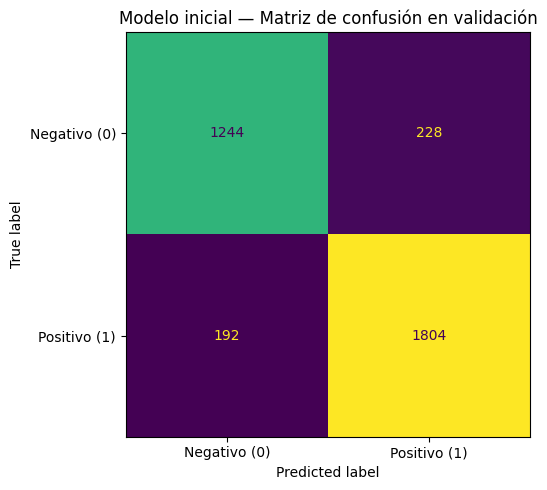


Resumen de aciertos y errores:


,Resultado,Cantidad
0,Verdaderos negativos (TN),1244
1,Falsos positivos (FP),228
2,Falsos negativos (FN),192
3,Verdaderos positivos (TP),1804
4,Total de aciertos,3048
5,Total de errores,420



Matriz de confusión verificada correctamente.


In [ ]:
# 5.3.3 — Matriz de confusión sobre validación

from sklearn.metrics import ConfusionMatrixDisplay

# ----------------------------------------------------------
# 1. Calcular la matriz con el orden fijo [0, 1]
# ----------------------------------------------------------

baseline_confusion_533 = confusion_matrix(
    y_val_531,
    y_val_pred_531,
    labels=[0, 1]
)

# Extraer los cuatro componentes
tn_533, fp_533, fn_533, tp_533 = (
    baseline_confusion_533.ravel()
)


# ----------------------------------------------------------
# 2. Mostrar la matriz como tabla
# ----------------------------------------------------------

confusion_table_533 = pd.DataFrame(
    baseline_confusion_533,
    index=["Real: Negativo (0)", "Real: Positivo (1)"],
    columns=[
        "Predicho: Negativo (0)",
        "Predicho: Positivo (1)"
    ]
)

print("Matriz de confusión del modelo inicial:")
display(confusion_table_533)


# ----------------------------------------------------------
# 3. Visualización gráfica
# ----------------------------------------------------------

confusion_display_533 = ConfusionMatrixDisplay(
    confusion_matrix=baseline_confusion_533,
    display_labels=["Negativo (0)", "Positivo (1)"]
)

fig, ax = plt.subplots(figsize=(6, 5))

confusion_display_533.plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

ax.set_title(
    "Modelo inicial — Matriz de confusión en validación"
)

plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# 4. Consolidar aciertos y errores
# ----------------------------------------------------------

correct_predictions_533 = int(tn_533 + tp_533)

incorrect_predictions_533 = int(fp_533 + fn_533)

error_summary_533 = pd.DataFrame({
    "Resultado": [
        "Verdaderos negativos (TN)",
        "Falsos positivos (FP)",
        "Falsos negativos (FN)",
        "Verdaderos positivos (TP)",
        "Total de aciertos",
        "Total de errores"
    ],
    "Cantidad": [
        tn_533,
        fp_533,
        fn_533,
        tp_533,
        correct_predictions_533,
        incorrect_predictions_533
    ]
})

print("\nResumen de aciertos y errores:")
display(error_summary_533)


# ----------------------------------------------------------
# 5. Verificaciones de coherencia
# ----------------------------------------------------------

assert baseline_confusion_533.shape == (2, 2), (
    "La matriz no corresponde a una clasificación binaria."
)

assert baseline_confusion_533.sum() == len(y_val_531), (
    "La matriz no contabiliza todos los registros de validación."
)

assert np.isclose(
    correct_predictions_533 / len(y_val_531),
    baseline_val_accuracy_532
), (
    "La matriz de confusión y accuracy no coinciden."
)

assert np.array_equal(
    baseline_confusion_533.sum(axis=1),
    y_val_531.value_counts().reindex(
        [0, 1], fill_value=0
    ).to_numpy()
), (
    "Los totales por etiqueta real no coinciden."
)

print("\nMatriz de confusión verificada correctamente.")

#### 5.3.4 Interpretación inicial del desempeño

La evaluación inicial del modelo TF-IDF + Regresión Logística se realizó sobre los **3.468 comentarios del conjunto de validación**, utilizando la configuración establecida en 5.1 y sin efectuar nuevos ajustes durante esta etapa.

El modelo obtuvo un **F1-macro de 0,8757**, establecido como métrica principal del proyecto. Las métricas complementarias fueron: accuracy de 0,8789, precision-macro de 0,8770 y recall-macro de 0,8745. Estos resultados constituyen la primera referencia cuantitativa para evaluar posteriormente configuraciones alternativas y comparar el enfoque clásico con el Transformer.

El análisis individual de las clases mostró diferencias en el desempeño:

| Clase | Precision | Recall | F1 |
|---|---:|---:|---:|
| Negativo (0) | 0,8663 | 0,8451 | 0,8556 |
| Positivo (1) | 0,8878 | 0,9038 | 0,8957 |

El modelo presentó un mayor F1 para los comentarios positivos (0,8957) que para los negativos (0,8556). La diferencia más relevante se observó en recall: identificó correctamente el **90,38 % de los comentarios positivos**, frente al **84,51 % de los negativos**. Esto evidencia una mayor dificultad para recuperar la totalidad de los comentarios de sentimiento negativo.

La matriz de confusión permitió identificar **3.048 predicciones correctas y 420 incorrectas**. De estas últimas, 228 correspondieron a comentarios negativos clasificados como positivos y 192 a comentarios positivos clasificados como negativos.

Estos resultados son coherentes con el menor recall de la clase negativa. Sin embargo, no permiten atribuir esta diferencia exclusivamente al desbalance de clases, por lo que sus posibles causas deberán considerarse durante el análisis posterior del modelo.

El tiempo total de inferencia sobre validación fue de **0,2019 segundos**, equivalente a un promedio aproximado de **0,0582 milisegundos por comentario**. Esta medición servirá como referencia experimental, considerando las condiciones del entorno de ejecución al efectuar comparaciones posteriores.

**Conclusión:** el modelo inicial alcanzó un F1-macro de 0,8757 sobre validación y permitió establecer un punto de referencia para el desarrollo del modelo base. Aunque presenta diferencias de desempeño entre las clases, especialmente en la recuperación de comentarios negativos, todavía no se ha determinado si otras configuraciones pueden mejorar sus resultados.

Por ello, el siguiente paso será evaluar de forma controlada alternativas de representación TF-IDF y parámetros de Regresión Logística, utilizando F1-macro sobre validación como criterio principal de selección.

El conjunto de prueba permanecerá reservado para la evaluación final y no se utilizará para seleccionar configuraciones ni ajustar el modelo.

### 5.4 Evaluación de configuraciones

El modelo inicial obtuvo un **F1-macro de 0,8757 sobre validación**. Para estudiar si la representación textual y la regularización modifican su desempeño, se realizará una comparación **limitada y predefinida de seis configuraciones** del pipeline TF-IDF + Regresión Logística.

Se modificarán únicamente dos parámetros:

- `ngram_range`: unigramas `(1, 1)` frente a unigramas y bigramas `(1, 2)`. La segunda opción permite representar secuencias como «no explica», relevantes para el análisis de sentimiento.
- `C`: `0.1`, `1.0` y `10.0`. Un valor menor implica mayor intensidad de regularización L2.

Los demás parámetros permanecerán iguales a los definidos en 5.1. Para cada configuración se construirá **un pipeline nuevo**, se ajustará **exclusivamente con entrenamiento** y se evaluará sobre los **mismos 3.468 registros de validación**. El conjunto de prueba no intervendrá en esta etapa.

La métrica principal de selección será **F1-macro**. Se registrarán también accuracy, precision-macro, recall-macro, las métricas por clase, el tamaño del vocabulario y los tiempos de entrenamiento e inferencia. Las mediciones temporales son descriptivas del entorno de ejecución y no determinan por sí solas la selección.

> La configuración C1 replica el modelo inicial. Se volverá a ajustar para que su tiempo se mida durante la misma secuencia experimental, y se comprobará que sus predicciones y F1-macro coinciden con lo obtenido en 5.3. La ejecución previa se conservará intacta.


#### 5.4.1 Definición de las configuraciones experimentales

La combinación de las dos variantes de TF-IDF y los tres valores de `C` genera seis experimentos. Este espacio de búsqueda se establece **antes de observar sus resultados**.

| ID | Representación TF-IDF | `ngram_range` | `C` |
|---|---|---:|---:|
| C1 (inicial) | Unigramas | `(1, 1)` | `1.0` |
| C2 | Unigramas | `(1, 1)` | `0.1` |
| C3 | Unigramas | `(1, 1)` | `10.0` |
| C4 | Unigramas + bigramas | `(1, 2)` | `0.1` |
| C5 | Unigramas + bigramas | `(1, 2)` | `1.0` |
| C6 | Unigramas + bigramas | `(1, 2)` | `10.0` |

Se mantendrán constantes `min_df=2`, `max_features=20000`, el tratamiento de acentos y palabras vacías, la normalización L2, el solucionador `liblinear`, `class_weight=None` y `random_state=42`. No se utilizará el vectorizador descriptivo de la etapa EDA ni se modificarán los comentarios normalizados.


In [ ]:
# 5.4.1 — Espacio experimental predefinido (sin ajustar modelos)
experiment_plan_541 = [
    {"config_id": "C1", "ngram_range": (1, 1), "C": 1.0},
    {"config_id": "C2", "ngram_range": (1, 1), "C": 0.1},
    {"config_id": "C3", "ngram_range": (1, 1), "C": 10.0},
    {"config_id": "C4", "ngram_range": (1, 2), "C": 0.1},
    {"config_id": "C5", "ngram_range": (1, 2), "C": 1.0},
    {"config_id": "C6", "ngram_range": (1, 2), "C": 10.0},
]

assert len(experiment_plan_541) == 6
assert len({item["config_id"] for item in experiment_plan_541}) == 6
assert len({(item["ngram_range"], item["C"]) for item in experiment_plan_541}) == 6
assert experiment_plan_541[0]["ngram_range"] == TFIDF_INITIAL_PARAMS_51["ngram_range"]
assert experiment_plan_541[0]["C"] == LR_INITIAL_PARAMS_51["C"]
assert PROJECT_CONFIG["primary_metric"] == "f1_macro"

# Se comprueba que las entradas ya validadas continúan alineadas.
assert X_train_52.index.equals(y_train_52.index)
assert X_val_531.index.equals(y_val_531.index)
assert X_train_52.index.intersection(X_val_531.index).empty
assert X_train_52.notna().all() and X_val_531.notna().all()
assert set(y_train_52.unique()) == set(y_val_531.unique()) == {0, 1}

experiment_plan_table_541 = pd.DataFrame(experiment_plan_541).rename(
    columns={"config_id": "Configuración", "ngram_range": "N-gramas", "C": "C"}
)
experiment_plan_table_541["Representación"] = experiment_plan_table_541[
    "N-gramas"
].map({(1, 1): "Unigramas", (1, 2): "Unigramas + bigramas"})
display(experiment_plan_table_541[
    ["Configuración", "Representación", "N-gramas", "C"]
])
print("Seis configuraciones definidas; aún no se han ajustado nuevos modelos.")


,Configuración,Representación,N-gramas,C
0,C1,Unigramas,"(1, 1)",1.0
1,C2,Unigramas,"(1, 1)",0.1
2,C3,Unigramas,"(1, 1)",10.0
3,C4,Unigramas + bigramas,"(1, 2)",0.1
4,C5,Unigramas + bigramas,"(1, 2)",1.0
5,C6,Unigramas + bigramas,"(1, 2)",10.0


Seis configuraciones definidas; aún no se han ajustado nuevos modelos.


#### 5.4.2 Entrenamiento y evaluación de las seis configuraciones

Cada experimento tendrá **instancias nuevas** de `TfidfVectorizer`, `LogisticRegression` y `Pipeline`, construidas como copias de la configuración de 5.1 con cambios exclusivamente en `ngram_range` y `C`.

Se registrarán por separado el tiempo de `.fit()` y el tiempo de `.predict()`. El primero incluye la construcción del vocabulario, los pesos IDF y el ajuste de la Regresión Logística; el segundo incluye transformar los comentarios de validación con el TF-IDF ya ajustado y clasificarlos.

Para cada configuración se conservarán el pipeline entrenado, las predicciones alineadas con los índices de validación, las métricas generales y las métricas de ambas clases. Se detectarán advertencias de convergencia; si aparecen, deberán examinarse antes de cerrar la selección del modelo.

**Restricción:** todos los ajustes se realizan exclusivamente con `X_train_52` e `y_train_52`. La validación se usa para evaluación y selección, nunca para ajustar el vocabulario ni el clasificador. Los datos de prueba continúan reservados.


In [ ]:
# 5.4.2 — Ejecutar los seis experimentos sobre entrenamiento/validación
import warnings
from sklearn.exceptions import ConvergenceWarning

# Referencias de integridad: las entradas no deben modificarse durante el proceso.
train_text_snapshot_542 = X_train_52.copy(deep=True)
train_label_snapshot_542 = y_train_52.copy(deep=True)
val_text_snapshot_542 = X_val_531.copy(deep=True)
val_label_snapshot_542 = y_val_531.copy(deep=True)

candidate_models_542 = {}        # Pipelines ajustados solo en entrenamiento
candidate_predictions_542 = {}   # Predicciones de validación por ID
experiment_rows_542 = []         # Métricas generales y costos
per_class_rows_542 = []          # Métricas individuales por clase

for candidate in experiment_plan_541:
    config_id = candidate["config_id"]

    # Copiar las configuraciones de 5.1: únicamente varían n-gramas y C.
    tfidf_params = TFIDF_INITIAL_PARAMS_51.copy()
    tfidf_params["ngram_range"] = candidate["ngram_range"]
    lr_params = LR_INITIAL_PARAMS_51.copy()
    lr_params["C"] = candidate["C"]

    candidate_pipeline = Pipeline(steps=[
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("logreg", LogisticRegression(**lr_params)),
    ])

    # Cada pipeline nace sin vocabulario ni coeficientes aprendidos.
    assert not hasattr(candidate_pipeline.named_steps["tfidf"], "vocabulary_")
    assert not hasattr(candidate_pipeline.named_steps["logreg"], "coef_")

    start_fit = time.perf_counter()
    with warnings.catch_warnings(record=True) as captured_warnings:
        warnings.simplefilter("always", ConvergenceWarning)
        candidate_pipeline.fit(X_train_52, y_train_52)
    fit_seconds = time.perf_counter() - start_fit

    convergence_warning = any(
        issubclass(warning.category, ConvergenceWarning)
        for warning in captured_warnings
    )
    if convergence_warning:
        print(f"Atención: {config_id} emitió una advertencia de convergencia.")

    start_predict = time.perf_counter()
    candidate_prediction = pd.Series(
        candidate_pipeline.predict(X_val_531),
        index=y_val_531.index,
        name=f"pred_{config_id}",
    ).astype("int64")
    predict_seconds = time.perf_counter() - start_predict

    assert candidate_prediction.index.equals(y_val_531.index)
    assert candidate_prediction.isin([0, 1]).all()
    assert hasattr(candidate_pipeline.named_steps["tfidf"], "vocabulary_")
    assert np.array_equal(candidate_pipeline.named_steps["logreg"].classes_, [0, 1])

    # Métricas por clase: orden fijo 0 = Negativo, 1 = Positivo.
    report = classification_report(
        y_val_531, candidate_prediction,
        labels=[0, 1], target_names=["Negativo (0)", "Positivo (1)"],
        output_dict=True, zero_division=0,
    )
    f1_macro = f1_score(
        y_val_531, candidate_prediction,
        labels=[0, 1], average="macro", zero_division=0,
    )
    accuracy = accuracy_score(y_val_531, candidate_prediction)
    precision_macro = precision_score(
        y_val_531, candidate_prediction,
        labels=[0, 1], average="macro", zero_division=0,
    )
    recall_macro = recall_score(
        y_val_531, candidate_prediction,
        labels=[0, 1], average="macro", zero_division=0,
    )

    vocab_size = len(candidate_pipeline.named_steps["tfidf"].vocabulary_)
    iterations = int(np.max(candidate_pipeline.named_steps["logreg"].n_iter_))
    assert 0 < vocab_size <= tfidf_params["max_features"]
    assert candidate_pipeline.named_steps["logreg"].coef_.shape == (1, vocab_size)
    assert np.isclose(f1_macro, (
        report["Negativo (0)"]["f1-score"] +
        report["Positivo (1)"]["f1-score"]
    ) / 2)

    candidate_models_542[config_id] = candidate_pipeline
    candidate_predictions_542[config_id] = candidate_prediction
    experiment_rows_542.append({
        "config_id": config_id,
        "ngram_range": candidate["ngram_range"],
        "C": candidate["C"],
        "f1_macro": f1_macro,
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "vocab_size": vocab_size,
        "iterations": iterations,
        "fit_seconds": fit_seconds,
        "predict_seconds": predict_seconds,
        "inference_ms_per_comment": predict_seconds / len(X_val_531) * 1000,
        "convergence_warning": convergence_warning,
    })
    for label in ["Negativo (0)", "Positivo (1)"]:
        per_class_rows_542.append({
            "config_id": config_id,
            "class_label": label,
            "precision": report[label]["precision"],
            "recall": report[label]["recall"],
            "f1": report[label]["f1-score"],
            "support": int(report[label]["support"]),
        })
    print(
        f"{config_id} | n-gramas={candidate['ngram_range']} | C={candidate['C']:g} "
        f"| F1-macro={f1_macro:.4f} | vocabulario={vocab_size:,} "
        f"| ajuste={fit_seconds:.3f}s | inferencia={predict_seconds:.3f}s"
    )

experiment_results_542 = pd.DataFrame(experiment_rows_542)
per_class_results_542 = pd.DataFrame(per_class_rows_542)

# Controles de integridad y contraste con el primer modelo de 5.3.
assert len(experiment_results_542) == len(candidate_models_542) == 6
assert len(per_class_results_542) == 12
assert X_train_52.equals(train_text_snapshot_542)
assert y_train_52.equals(train_label_snapshot_542)
assert X_val_531.equals(val_text_snapshot_542)
assert y_val_531.equals(val_label_snapshot_542)
assert candidate_predictions_542["C1"].equals(y_val_pred_531.rename("pred_C1"))
assert np.isclose(
    experiment_results_542.set_index("config_id").loc["C1", "f1_macro"],
    baseline_val_f1_macro_532,
)
print("\nC1 reproduce las predicciones de 5.3; seis evaluaciones completadas.")


C1 | n-gramas=(1, 1) | C=1 | F1-macro=0.8757 | vocabulario=5,653 | ajuste=1.893s | inferencia=0.304s
C2 | n-gramas=(1, 1) | C=0.1 | F1-macro=0.8553 | vocabulario=5,653 | ajuste=1.340s | inferencia=0.205s
C3 | n-gramas=(1, 1) | C=10 | F1-macro=0.8646 | vocabulario=5,653 | ajuste=1.057s | inferencia=0.179s
C4 | n-gramas=(1, 2) | C=0.1 | F1-macro=0.8564 | vocabulario=20,000 | ajuste=2.412s | inferencia=0.334s
C5 | n-gramas=(1, 2) | C=1 | F1-macro=0.8749 | vocabulario=20,000 | ajuste=2.464s | inferencia=0.300s
C6 | n-gramas=(1, 2) | C=10 | F1-macro=0.8724 | vocabulario=20,000 | ajuste=4.793s | inferencia=0.475s

C1 reproduce las predicciones de 5.3; seis evaluaciones completadas.


#### 5.4.3 Consolidación y comparación de resultados

Se compararán las seis configuraciones sobre **el mismo conjunto de validación**. La tabla mostrará las métricas generales, la diferencia de F1-macro respecto a C1 y el tamaño efectivo del vocabulario.

La diferencia se calculará con los valores completos (sin redondeo previo). Los resultados impresos se mostrarán con cuatro decimales para facilitar la lectura. Una diferencia observada en validación **no constituye por sí sola evidencia de mejora estadísticamente significativa** ni de rendimiento equivalente en prueba.

No se utilizará esta tabla para modificar retrospectivamente el espacio de búsqueda establecido en 5.4.1.


Resultados de las seis configuraciones (validación):


,config_id,representation,C,vocab_size,f1_macro,delta_f1_vs_C1,accuracy,precision_macro,recall_macro
0,C1,Unigramas,1.0,"5,653",0.8757,+0.0000,0.8789,0.8770,0.8745
1,C2,Unigramas,0.1,"5,653",0.8553,-0.0203,0.8596,0.8582,0.8532
2,C3,Unigramas,10.0,"5,653",0.8646,-0.0110,0.8679,0.8653,0.8640
3,C4,Unigramas + bigramas,0.1,"20,000",0.8564,-0.0193,0.8607,0.8598,0.8540
4,C5,Unigramas + bigramas,1.0,"20,000",0.8749,-0.0007,0.8780,0.8758,0.8742
5,C6,Unigramas + bigramas,10.0,"20,000",0.8724,-0.0033,0.8754,0.8728,0.8720


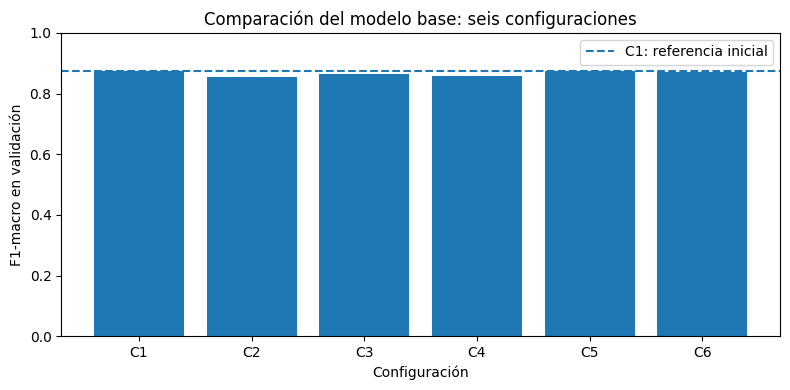

In [ ]:
# 5.4.3 — Comparación general con la configuración inicial C1
baseline_f1_543 = float(baseline_val_f1_macro_532)
baseline_accuracy_543 = float(baseline_val_accuracy_532)

comparison_543 = experiment_results_542.copy()
comparison_543["delta_f1_vs_C1"] = comparison_543["f1_macro"] - baseline_f1_543
comparison_543["delta_accuracy_vs_C1"] = comparison_543["accuracy"] - baseline_accuracy_543
comparison_543["representation"] = comparison_543["ngram_range"].map({
    (1, 1): "Unigramas", (1, 2): "Unigramas + bigramas"
})

# Orden de lectura por ID; la selección formal se realizará en 5.4.5.
comparison_543 = comparison_543.sort_values("config_id").reset_index(drop=True)
assert np.isclose(comparison_543.loc[0, "delta_f1_vs_C1"], 0.0)
assert comparison_543["f1_macro"].between(0, 1).all()

print("Resultados de las seis configuraciones (validación):")
display(comparison_543[[
    "config_id", "representation", "C", "vocab_size", "f1_macro",
    "delta_f1_vs_C1", "accuracy", "precision_macro", "recall_macro"
]].style.format({
    "C": "{:.1f}", "vocab_size": "{:,.0f}", "f1_macro": "{:.4f}",
    "delta_f1_vs_C1": "{:+.4f}", "accuracy": "{:.4f}",
    "precision_macro": "{:.4f}", "recall_macro": "{:.4f}",
}))

# Comparación visual descriptiva; sin ordenar ni decidir por diferencias de tiempo.
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(comparison_543["config_id"], comparison_543["f1_macro"])
ax.axhline(baseline_f1_543, linestyle="--", label="C1: referencia inicial")
ax.set_ylim(0, 1)
ax.set_xlabel("Configuración")
ax.set_ylabel("F1-macro en validación")
ax.set_title("Comparación del modelo base: seis configuraciones")
ax.legend()
plt.tight_layout()
plt.show()


#### 5.4.4 Análisis por clase y costo computacional

Además del F1-macro, se compararán las métricas de **Negativo (0)** y **Positivo (1)**. En el modelo inicial se observó un menor recall de la clase negativa; revisaremos si ese comportamiento cambia en las configuraciones alternativas, sin cambiar retrospectivamente el criterio principal de selección.

También se revisarán el tamaño del vocabulario, el número de iteraciones, el tiempo de ajuste y el tiempo de inferencia. Estos tiempos dependen del equipo, el entorno y el estado de ejecución; se registran como información complementaria, no como una comparación universal de velocidad.

El soporte de cada clase debe permanecer invariable en los seis experimentos, dado que todas las configuraciones utilizan la misma partición de validación.


In [ ]:
# 5.4.4 — Desempeño por clase y tiempos experimentales
class_comparison_544 = per_class_results_542.copy().sort_values(
    ["config_id", "class_label"]
).reset_index(drop=True)

expected_support_544 = {"Negativo (0)": 1472, "Positivo (1)": 1996}
for label, support in expected_support_544.items():
    assert class_comparison_544.loc[
        class_comparison_544["class_label"] == label, "support"
    ].eq(support).all(), f"El soporte de {label} no coincide con validación."

print("Precision, recall y F1 por clase (validación):")
display(class_comparison_544.style.format({
    "precision": "{:.4f}", "recall": "{:.4f}", "f1": "{:.4f}",
}))

negative_recall_544 = (
    class_comparison_544.loc[class_comparison_544["class_label"] == "Negativo (0)"]
    .set_index("config_id")["recall"]
)
positive_recall_544 = (
    class_comparison_544.loc[class_comparison_544["class_label"] == "Positivo (1)"]
    .set_index("config_id")["recall"]
)
recall_gap_544 = pd.DataFrame({
    "recall_negative": negative_recall_544,
    "recall_positive": positive_recall_544,
})
recall_gap_544["positive_minus_negative_pp"] = (
    recall_gap_544["recall_positive"] - recall_gap_544["recall_negative"]
) * 100
print("\nDiferencia descriptiva de recall entre clases (puntos porcentuales):")
display(recall_gap_544.reset_index().style.format({
    "recall_negative": "{:.4f}", "recall_positive": "{:.4f}",
    "positive_minus_negative_pp": "{:+.2f}",
}))

cost_comparison_544 = experiment_results_542[[
    "config_id", "ngram_range", "C", "vocab_size", "iterations",
    "fit_seconds", "predict_seconds", "inference_ms_per_comment",
    "convergence_warning"
]].copy().sort_values("config_id")
print("\nCosto computacional observado por configuración:")
display(cost_comparison_544.style.format({
    "C": "{:.1f}", "fit_seconds": "{:.4f}", "predict_seconds": "{:.4f}",
    "inference_ms_per_comment": "{:.4f}",
}))

assert not cost_comparison_544["convergence_warning"].isna().any()
if cost_comparison_544["convergence_warning"].any():
    print("\nAtención: hay advertencias de convergencia; revisarlas antes de cerrar 5.4.")
else:
    print("\nNo se registraron advertencias de convergencia en los experimentos.")


Precision, recall y F1 por clase (validación):


,config_id,class_label,precision,recall,f1,support
0,C1,Negativo (0),0.8663,0.8451,0.8556,1472
1,C1,Positivo (1),0.8878,0.9038,0.8957,1996
2,C2,Negativo (0),0.8510,0.8111,0.8306,1472
3,C2,Positivo (1),0.8654,0.8953,0.8801,1996
4,C3,Negativo (0),0.8492,0.8376,0.8434,1472
5,C3,Positivo (1),0.8814,0.8903,0.8858,1996
6,C4,Negativo (0),0.8550,0.8091,0.8314,1472
7,C4,Positivo (1),0.8646,0.8988,0.8814,1996
8,C5,Negativo (0),0.8620,0.8485,0.8552,1472
9,C5,Positivo (1),0.8895,0.8998,0.8946,1996



Diferencia descriptiva de recall entre clases (puntos porcentuales):


,config_id,recall_negative,recall_positive,positive_minus_negative_pp
0,C1,0.8451,0.9038,+5.87
1,C2,0.8111,0.8953,+8.41
2,C3,0.8376,0.8903,+5.26
3,C4,0.8091,0.8988,+8.97
4,C5,0.8485,0.8998,+5.13
5,C6,0.8492,0.8948,+4.56



Costo computacional observado por configuración:


,config_id,ngram_range,C,vocab_size,iterations,fit_seconds,predict_seconds,inference_ms_per_comment,convergence_warning
0,C1,"(1, 1)",1.0,5653,6,1.8933,0.3044,0.0878,False
1,C2,"(1, 1)",0.1,5653,5,1.3401,0.2054,0.0592,False
2,C3,"(1, 1)",10.0,5653,8,1.0574,0.1790,0.0516,False
3,C4,"(1, 2)",0.1,20000,4,2.4123,0.3336,0.0962,False
4,C5,"(1, 2)",1.0,20000,6,2.4635,0.2999,0.0865,False
5,C6,"(1, 2)",10.0,20000,8,4.7930,0.4748,0.1369,False



No se registraron advertencias de convergencia en los experimentos.


#### 5.4.5 Selección documentada de la configuración del modelo base

Se seleccionará una configuración mediante una regla declarada antes de consultar los resultados:

1. **F1-macro de validación**, presentado a cuatro decimales, como criterio principal.
2. Si dos resultados empatan a esa precisión, **accuracy**, también a cuatro decimales, como criterio secundario.
3. Si persiste el empate, menor **tamaño efectivo del vocabulario** como criterio de simplicidad; si aún persiste, el menor identificador C1–C6 para garantizar determinismo.

Los valores completos de las métricas se conservarán en las tablas; el redondeo se utiliza **únicamente para aplicar la regla de empate declarada**. Precision, recall y F1 por clase se revisarán para interpretar los resultados, sin sustituir el criterio predefinido.

La configuración seleccionada permanecerá **ajustada únicamente con entrenamiento** y sus resultados corresponderán a validación. En esta sección **no se reajustará con entrenamiento + validación ni se evaluará el conjunto de prueba**. El protocolo de entrenamiento final deberá acordarse de forma común con el enfoque Transformer antes de la evaluación final.


In [ ]:
# 5.4.5 — Selección reproducible (sin utilizar prueba ni reajustar modelos)
assert len(experiment_results_542) == 6
assert set(experiment_results_542["config_id"]) == {f"C{i}" for i in range(1, 7)}

# Una advertencia de convergencia impide cerrar automáticamente la selección.
assert not experiment_results_542["convergence_warning"].any(), (
    "Revisar las advertencias de convergencia antes de seleccionar el modelo."
)

selection_table_545 = experiment_results_542.copy()
selection_table_545["f1_macro_4d"] = selection_table_545["f1_macro"].round(4)
selection_table_545["accuracy_4d"] = selection_table_545["accuracy"].round(4)

selection_table_545 = selection_table_545.sort_values(
    by=["f1_macro_4d", "accuracy_4d", "vocab_size", "config_id"],
    ascending=[False, False, True, True],
    kind="stable",
).reset_index(drop=True)
selection_table_545.insert(0, "selection_order", np.arange(1, len(selection_table_545) + 1))

selected_configuration_id_545 = selection_table_545.loc[0, "config_id"]
selected_configuration_545 = next(
    item.copy() for item in experiment_plan_541
    if item["config_id"] == selected_configuration_id_545
)
selected_pipeline_545 = candidate_models_542[selected_configuration_id_545]
selected_validation_predictions_545 = candidate_predictions_542[selected_configuration_id_545].copy()
selected_val_metrics_545 = experiment_results_542.set_index("config_id").loc[
    selected_configuration_id_545
].to_dict()

assert selected_validation_predictions_545.index.equals(y_val_531.index)
assert np.isclose(
    f1_score(y_val_531, selected_validation_predictions_545,
             labels=[0, 1], average="macro", zero_division=0),
    selected_val_metrics_545["f1_macro"],
)
assert np.isclose(
    selected_pipeline_545.named_steps["logreg"].C,
    selected_configuration_545["C"],
)
assert selected_pipeline_545.named_steps["tfidf"].ngram_range == (
    selected_configuration_545["ngram_range"]
)

print("Orden de selección con los criterios declarados:")
display(selection_table_545[[
    "selection_order", "config_id", "ngram_range", "C", "vocab_size",
    "f1_macro", "accuracy", "f1_macro_4d", "accuracy_4d"
]].style.format({"C": "{:.1f}", "f1_macro": "{:.6f}",
                 "accuracy": "{:.6f}", "f1_macro_4d": "{:.4f}",
                 "accuracy_4d": "{:.4f}"}))

selected_delta_f1_545 = (
    float(selected_val_metrics_545["f1_macro"]) - float(baseline_val_f1_macro_532)
)
print(f"\nConfiguración seleccionada: {selected_configuration_id_545}")
print(f"N-gramas: {selected_configuration_545['ngram_range']}")
print(f"C: {selected_configuration_545['C']}")
print(f"F1-macro en validación: {selected_val_metrics_545['f1_macro']:.4f}")
print(f"Diferencia respecto a C1: {selected_delta_f1_545:+.4f}")
print("El pipeline seleccionado continúa ajustado solamente con entrenamiento.")
print("No se ha utilizado el conjunto de prueba.")


Orden de selección con los criterios declarados:


,selection_order,config_id,ngram_range,C,vocab_size,f1_macro,accuracy,f1_macro_4d,accuracy_4d
0,1,C1,"(1, 1)",1.0,5653,0.875650,0.878893,0.8757,0.8789
1,2,C5,"(1, 2)",1.0,20000,0.874916,0.878028,0.8749,0.8780
2,3,C6,"(1, 2)",10.0,20000,0.872384,0.875433,0.8724,0.8754
3,4,C3,"(1, 1)",10.0,5653,0.864604,0.867935,0.8646,0.8679
4,5,C4,"(1, 2)",0.1,20000,0.856385,0.860727,0.8564,0.8607
5,6,C2,"(1, 1)",0.1,5653,0.855344,0.859573,0.8553,0.8596



Configuración seleccionada: C1
N-gramas: (1, 1)
C: 1.0
F1-macro en validación: 0.8757
Diferencia respecto a C1: +0.0000
El pipeline seleccionado continúa ajustado solamente con entrenamiento.
No se ha utilizado el conjunto de prueba.


#### Interpretación y cierre de 5.4

La evaluación de configuraciones permitió comparar **seis variantes del modelo TF-IDF + Regresión Logística**, combinando dos representaciones textuales (unigramas y unigramas + bigramas) con tres valores del parámetro de regularización `C` (0.1, 1.0 y 10.0).

Todos los experimentos se realizaron utilizando los mismos **16.186 registros de entrenamiento y 3.468 de validación**, manteniendo F1-macro como métrica principal de selección y sin utilizar el conjunto de prueba.

Los resultados obtenidos fueron:

| Configuración | Representación | C | F1-macro |
|---|---|---:|---:|
| C1 | Unigramas | 1.0 | **0.8757** |
| C2 | Unigramas | 0.1 | 0.8553 |
| C3 | Unigramas | 10.0 | 0.8646 |
| C4 | Unigramas + bigramas | 0.1 | 0.8564 |
| C5 | Unigramas + bigramas | 1.0 | 0.8749 |
| C6 | Unigramas + bigramas | 10.0 | 0.8724 |

La configuración inicial **C1 obtuvo el mayor F1-macro (0.8757)** entre las alternativas evaluadas. La incorporación de bigramas no produjo una mejora en esta métrica, aunque C5 alcanzó un resultado muy cercano (0.8749).

Asimismo, reducir `C` a 0.1 disminuyó el desempeño en ambas representaciones, mientras que aumentarlo a 10.0 tampoco permitió superar la configuración inicial.

En cuanto a la representación textual, el vocabulario pasó de **5.653 términos con unigramas a 20.000 características al incorporar bigramas**, alcanzando el límite establecido por `max_features`. Por tanto, los resultados describen el comportamiento de las configuraciones evaluadas y no permiten concluir que los bigramas sean inherentemente menos útiles para este problema.

El análisis individual de las clases mostró que C5 y C6 incrementaron ligeramente el recall de los comentarios negativos respecto a C1. Sin embargo, estas variaciones no se tradujeron en una mejora del F1-macro general. Esto evidencia la importancia de complementar la métrica principal con el análisis de precision, recall y F1 por clase.

**Selección del modelo base:** de acuerdo con el criterio experimental establecido previamente, se seleccionó **C1 (TF-IDF con unigramas y Regresión Logística con C = 1.0)**, conservando la configuración inicial y su F1-macro de 0.8757 sobre validación.

Los seis experimentos finalizaron sin errores ni advertencias de convergencia, y se verificó que C1 reproduce los resultados del modelo inicial evaluado en 5.3.

**Conclusión:** la búsqueda controlada de configuraciones permitió justificar la conservación del modelo inicial como modelo base seleccionado. Esta decisión se fundamenta en los resultados de validación dentro del espacio limitado de parámetros explorado, sin asumir que representa una configuración óptima universal.

El pipeline seleccionado permanecerá documentado para su posterior comparación con el Transformer preentrenado. El conjunto de prueba continuará reservado hasta establecer el protocolo común de evaluación final para ambos enfoques.

### 5.5 Documentación y consolidación del modelo base seleccionado

La sección 5.4 seleccionó **C1** según el criterio predefinido de F1-macro sobre validación. En este apartado se documentarán su configuración efectiva, las métricas generales y por clase, la matriz de confusión y las características aprendidas por el pipeline. También se verificará la correspondencia entre el modelo seleccionado y los resultados almacenados.

**Alcance:** no se realizará un nuevo ajuste ni se modificará la configuración seleccionada. Todas las métricas predictivas de esta sección corresponden a **validación (3.468 observaciones)**; el conjunto de prueba continuará reservado. Los resultados de 5.5 se generarán a partir de los objetos ya obtenidos en 5.2–5.4.

#### 5.5.1 Identificación y configuración efectiva del modelo seleccionado

Se recuperará el pipeline seleccionado en 5.4.5 y se documentarán los parámetros **efectivamente presentes en sus componentes ajustados**, en lugar de reconstruir un modelo nuevo. La selección del espacio explorado corresponde a **C1: TF-IDF con unigramas `(1, 1)` y Regresión Logística con `C=1.0`**. Los parámetros restantes deben coincidir con la configuración inicial de 5.1.

In [ ]:
# 5.5.1 — Identificación y documentación del pipeline seleccionado
selected_id_551 = selected_configuration_id_545
selected_model_551 = selected_pipeline_545  # referencia: no se clona ni se reentrena
selected_tfidf_551 = selected_model_551.named_steps["tfidf"]
selected_lr_551 = selected_model_551.named_steps["logreg"]

assert selected_id_551 == "C1", (
    "La configuración seleccionada difiere de C1; revisar los resultados de 5.4."
)
assert selected_model_551 is candidate_models_542[selected_id_551]
assert hasattr(selected_tfidf_551, "vocabulary_")
assert hasattr(selected_tfidf_551, "idf_")
assert hasattr(selected_lr_551, "coef_")
assert np.array_equal(selected_lr_551.classes_, [0, 1])

selected_tfidf_params_551 = selected_tfidf_551.get_params(deep=False)
selected_lr_params_551 = selected_lr_551.get_params(deep=False)
expected_tfidf_551 = TFIDF_INITIAL_PARAMS_51.copy()
expected_tfidf_551["ngram_range"] = selected_configuration_545["ngram_range"]
expected_lr_551 = LR_INITIAL_PARAMS_51.copy()
expected_lr_551["C"] = selected_configuration_545["C"]

for param, expected in expected_tfidf_551.items():
    assert selected_tfidf_params_551[param] == expected, (
        f"Diferencia inesperada en TF-IDF: {param}"
    )
for param, expected in expected_lr_551.items():
    assert selected_lr_params_551[param] == expected, (
        f"Diferencia inesperada en Regresión Logística: {param}"
    )

selected_config_table_551 = pd.DataFrame(
    [("TF-IDF", k, selected_tfidf_params_551[k]) for k in expected_tfidf_551]
    + [("Regresión Logística", k, selected_lr_params_551[k]) for k in expected_lr_551],
    columns=["Componente", "Parámetro", "Valor efectivo"]
)
print("Modelo seleccionado:", selected_id_551)
display(selected_config_table_551)
print("Configuración del pipeline ajustado verificada; no se ha reentrenado.")

Modelo seleccionado: C1


,Componente,Parámetro,Valor efectivo
0,TF-IDF,ngram_range,"(1, 1)"
1,TF-IDF,min_df,2
2,TF-IDF,max_features,20000
3,TF-IDF,lowercase,True
4,TF-IDF,strip_accents,None
5,TF-IDF,stop_words,None
6,TF-IDF,token_pattern,(?u)\b\w+\b
7,TF-IDF,use_idf,True
8,TF-IDF,smooth_idf,True
9,TF-IDF,sublinear_tf,False


Configuración del pipeline ajustado verificada; no se ha reentrenado.


#### 5.5.2 Consolidación de métricas y matriz de confusión en validación

Se reunirán las métricas registradas para C1 durante 5.4, junto con los resultados individuales por clase y su matriz de confusión. Este resumen no constituye una evaluación nueva sobre prueba: reutiliza las predicciones de validación ya generadas.

Se mantendrá el orden fijo de etiquetas `[0, 1]` (**Negativo**, **Positivo**) para evitar ambigüedades al interpretar errores. Los tiempos se presentarán como mediciones de la ejecución de C1 dentro de los seis experimentos de 5.4; pueden diferir de la medición independiente del primer entrenamiento en 5.2–5.3.

In [ ]:
# 5.5.2 — Consolidación de resultados generales seleccionados
selected_metric_row_552 = experiment_results_542.set_index("config_id").loc[selected_id_551]
selected_predictions_552 = selected_validation_predictions_545.copy(deep=True)
assert selected_predictions_552.index.equals(y_val_531.index)
assert selected_predictions_552.equals(candidate_predictions_542[selected_id_551])

selected_metric_names_552 = [
    "f1_macro", "accuracy", "precision_macro", "recall_macro"
]
selected_metrics_table_552 = pd.DataFrame({
    "Métrica": ["F1-macro (principal)", "Accuracy", "Precision-macro", "Recall-macro"],
    "Valor": [float(selected_metric_row_552[name]) for name in selected_metric_names_552]
})
selected_cost_table_552 = pd.DataFrame({
    "Medida": ["Entrenamiento: registros", "Validación: registros",
               "Vocabulario TF-IDF", "Iteraciones del clasificador",
               "Tiempo de ajuste en 5.4 (s)", "Tiempo de inferencia en 5.4 (s)",
               "Inferencia por comentario (ms)"],
    "Resultado": [len(X_train_52), len(y_val_531),
                  int(selected_metric_row_552["vocab_size"]),
                  int(selected_metric_row_552["iterations"]),
                  float(selected_metric_row_552["fit_seconds"]),
                  float(selected_metric_row_552["predict_seconds"]),
                  float(selected_metric_row_552["inference_ms_per_comment"])]
})

assert np.isclose(
    f1_score(y_val_531, selected_predictions_552, labels=[0, 1],
             average="macro", zero_division=0),
    selected_metric_row_552["f1_macro"]
)
assert np.isclose(
    accuracy_score(y_val_531, selected_predictions_552),
    selected_metric_row_552["accuracy"]
)
assert len(selected_tfidf_551.vocabulary_) == int(selected_metric_row_552["vocab_size"])

print("Métricas generales de C1 sobre validación:")
display(selected_metrics_table_552.style.format({"Valor": "{:.4f}"}))
print("\nDimensiones y tiempos registrados durante 5.4:")
display(selected_cost_table_552)

Métricas generales de C1 sobre validación:


,Métrica,Valor
0,F1-macro (principal),0.8757
1,Accuracy,0.8789
2,Precision-macro,0.8770
3,Recall-macro,0.8745



Dimensiones y tiempos registrados durante 5.4:


,Medida,Resultado
0,Entrenamiento: registros,16186.000000
1,Validación: registros,3468.000000
2,Vocabulario TF-IDF,5653.000000
3,Iteraciones del clasificador,6.000000
4,Tiempo de ajuste en 5.4 (s),1.893277
5,Tiempo de inferencia en 5.4 (s),0.304389
6,Inferencia por comentario (ms),0.087771


In [ ]:
# 5.5.2 — Resultados por clase y matriz de confusión de C1
selected_per_class_552 = (
    per_class_results_542.loc[
        per_class_results_542["config_id"] == selected_id_551,
        ["class_label", "precision", "recall", "f1", "support"]
    ].copy().set_index("class_label")
    .reindex(["Negativo (0)", "Positivo (1)"]).reset_index()
)
assert len(selected_per_class_552) == 2
assert selected_per_class_552["support"].sum() == len(y_val_531)
assert np.isclose(selected_per_class_552["f1"].mean(), selected_metric_row_552["f1_macro"])

selected_confusion_552 = confusion_matrix(
    y_val_531, selected_predictions_552, labels=[0, 1]
)
tn_552, fp_552, fn_552, tp_552 = selected_confusion_552.ravel()
selected_confusion_table_552 = pd.DataFrame(
    selected_confusion_552,
    index=["Real: Negativo (0)", "Real: Positivo (1)"],
    columns=["Predicho: Negativo (0)", "Predicho: Positivo (1)"]
)
selected_error_summary_552 = pd.DataFrame({
    "Resultado": ["Verdaderos negativos (TN)", "Falsos positivos (FP)",
                  "Falsos negativos (FN)", "Verdaderos positivos (TP)",
                  "Predicciones correctas", "Predicciones incorrectas"],
    "Cantidad": [int(tn_552), int(fp_552), int(fn_552), int(tp_552),
                 int(tn_552 + tp_552), int(fp_552 + fn_552)]
})
assert selected_confusion_552.sum() == len(y_val_531)
assert np.array_equal(selected_confusion_552.sum(axis=1),
                      y_val_531.value_counts().reindex([0, 1]).to_numpy())
assert np.isclose((tn_552 + tp_552) / len(y_val_531), selected_metric_row_552["accuracy"])

print("Métricas por clase en validación:")
display(selected_per_class_552.style.format({"precision": "{:.4f}", "recall": "{:.4f}", "f1": "{:.4f}"}))
print("\nMatriz de confusión (filas = real, columnas = predicho):")
display(selected_confusion_table_552)
print("\nAciertos y errores:")
display(selected_error_summary_552)

Métricas por clase en validación:


,class_label,precision,recall,f1,support
0,Negativo (0),0.8663,0.8451,0.8556,1472
1,Positivo (1),0.8878,0.9038,0.8957,1996



Matriz de confusión (filas = real, columnas = predicho):


,Predicho: Negativo (0),Predicho: Positivo (1)
Real: Negativo (0),1244,228
Real: Positivo (1),192,1804



Aciertos y errores:


,Resultado,Cantidad
0,Verdaderos negativos (TN),1244
1,Falsos positivos (FP),228
2,Falsos negativos (FN),192
3,Verdaderos positivos (TP),1804
4,Predicciones correctas,3048
5,Predicciones incorrectas,420


#### 5.5.3 Características aprendidas e interpretación exploratoria del modelo

Se documentarán el tamaño efectivo del vocabulario y las dimensiones de los coeficientes del clasificador. Asimismo, se inspeccionarán **los términos con coeficientes más negativos y más positivos** de la Regresión Logística: con la codificación definida, los valores negativos se asocian con la decisión hacia la clase `0` y los positivos con la clase `1`, manteniendo constantes las demás características del modelo lineal.

Esta inspección describe asociaciones estadísticas de un modelo de bolsa de palabras. No constituye una explicación causal ni significa que el algoritmo comprenda el contenido semántico del comentario. Los coeficientes también dependen del vocabulario, de la ponderación TF-IDF y de la regularización utilizada.

In [ ]:
# 5.5.3 — Vocabulario y coeficientes del pipeline seleccionado
features_553 = selected_tfidf_551.get_feature_names_out()
coefficients_553 = selected_lr_551.coef_.ravel()
vocabulary_size_553 = len(features_553)

assert vocabulary_size_553 == len(selected_tfidf_551.vocabulary_) == len(selected_tfidf_551.idf_)
assert coefficients_553.shape == (vocabulary_size_553,)
assert selected_lr_551.coef_.shape == (1, vocabulary_size_553)
assert selected_lr_551.intercept_.shape == (1,)
assert np.array_equal(selected_lr_551.classes_, [0, 1])

selected_model_structure_553 = pd.DataFrame({
    "Elemento": ["Modelo", "Representación", "Cantidad de características",
                 "Coeficientes del clasificador", "Intercepto", "Clases",
                 "Número de iteraciones", "IDF mínimo", "IDF máximo"],
    "Resultado": [selected_id_551, str(selected_tfidf_551.ngram_range),
                  vocabulary_size_553, selected_lr_551.coef_.shape,
                  round(float(selected_lr_551.intercept_[0]), 6),
                  selected_lr_551.classes_.tolist(),
                  int(np.max(selected_lr_551.n_iter_)),
                  round(float(selected_tfidf_551.idf_.min()), 6),
                  round(float(selected_tfidf_551.idf_.max()), 6)]
})

# Los términos se ordenan por el coeficiente del clasificador (no por su IDF).
coefficient_table_553 = pd.DataFrame({
    "Término": features_553, "Coeficiente": coefficients_553, "IDF": selected_tfidf_551.idf_
})
negative_terms_553 = coefficient_table_553.loc[
    coefficient_table_553["Coeficiente"] < 0
].nsmallest(12, "Coeficiente").reset_index(drop=True)
positive_terms_553 = coefficient_table_553.loc[
    coefficient_table_553["Coeficiente"] > 0
].nlargest(12, "Coeficiente").reset_index(drop=True)
assert not negative_terms_553.empty and not positive_terms_553.empty

print("Estructura aprendida por C1:")
display(selected_model_structure_553)
print("\nTérminos con mayores coeficientes hacia Negativo (0):")
display(negative_terms_553.style.format({"Coeficiente": "{:+.4f}", "IDF": "{:.4f}"}))
print("\nTérminos con mayores coeficientes hacia Positivo (1):")
display(positive_terms_553.style.format({"Coeficiente": "{:+.4f}", "IDF": "{:.4f}"}))

Estructura aprendida por C1:


,Elemento,Resultado
0,Modelo,C1
1,Representación,"(1, 1)"
2,Cantidad de características,5653
3,Coeficientes del clasificador,"(1, 5653)"
4,Intercepto,0.112655
5,Clases,"[0, 1]"
6,Número de iteraciones,6
7,IDF mínimo,1.612188
8,IDF máximo,9.593351



Términos con mayores coeficientes hacia Negativo (0):


,Término,Coeficiente,IDF
0,no,-9.6976,2.9217
1,en,-6.4101,2.1520
2,mas,-4.0841,3.2093
3,falta,-3.8366,4.7207
4,mejorar,-3.3980,4.1017
5,mayor,-3.3595,5.0430
6,de,-3.2239,1.6122
7,deben,-3.2014,4.8398
8,pension,-2.9046,5.8092
9,pensiones,-2.7642,6.0285



Términos con mayores coeficientes hacia Positivo (1):


,Término,Coeficiente,IDF
0,buena,+5.0654,3.3754
1,valoro,+4.1561,5.1010
2,buenos,+4.1164,4.0250
3,la,+3.9833,1.7136
4,enseñanza,+3.4096,2.7461
5,buen,+3.0357,4.5849
6,los,+2.8755,1.9214
7,su,+2.4615,3.3524
8,que,+2.4516,1.9491
9,calidad,+2.4080,3.1308


#### 5.5.4 Verificación de trazabilidad e integridad

Se comprobará que C1 es exactamente el pipeline conservado por la selección de 5.4.5 y que sus predicciones corresponden a las mismas observaciones de validación utilizadas en los experimentos. Se contrastarán, además, los registros originales de entrenamiento y validación con las copias de referencia tomadas antes del ajuste.

La procedencia del ajuste está documentada en el código de 5.4.2: cada candidato ejecutó `fit(X_train_52, y_train_52)` sin incluir validación ni prueba. Las comprobaciones siguientes corroboran la consistencia de los objetos conservados; no realizan un nuevo entrenamiento ni consultan el contenido de prueba.

In [ ]:
# 5.5.4 — Auditoría del modelo base conservado y de las particiones
assert selected_model_551 is selected_pipeline_545
assert selected_model_551 is candidate_models_542[selected_id_551]
assert selected_predictions_552.equals(candidate_predictions_542[selected_id_551])
assert selected_predictions_552.index.equals(y_val_531.index)
assert len(X_train_52) == 16186 and len(y_val_531) == 3468
assert X_train_52.index.intersection(X_val_531.index).empty
assert X_train_52.equals(train_text_snapshot_542)
assert y_train_52.equals(train_label_snapshot_542)
assert X_val_531.equals(val_text_snapshot_542)
assert y_val_531.equals(val_label_snapshot_542)
assert df_clean.equals(df_before_split_45)
assert len(selected_tfidf_551.vocabulary_) == int(selected_metric_row_552["vocab_size"])
assert not bool(selected_metric_row_552["convergence_warning"])

# Contraste de predicciones: solo se vuelve a predecir sobre validación.
reproduced_validation_predictions_554 = pd.Series(
    selected_model_551.predict(X_val_531),
    index=X_val_531.index,
    name=selected_predictions_552.name,
).astype("int64")
assert reproduced_validation_predictions_554.equals(selected_predictions_552)
assert np.isclose(
    f1_score(y_val_531, reproduced_validation_predictions_554,
             average="macro", labels=[0, 1], zero_division=0),
    float(selected_metric_row_552["f1_macro"])
)

selected_audit_554 = pd.DataFrame({
    "Control": ["Identidad del pipeline seleccionado",
                "Parámetros efectivos de C1",
                "Predicciones de validación reproducidas",
                "Métricas de validación consistentes",
                "Datos originales conservados",
                "Separación de índices train/validación",
                "Sin advertencias de convergencia"],
    "Resultado": ["Correcto"] * 7
})
display(selected_audit_554)
print("Auditoría superada. No se ha reentrenado el pipeline ni evaluado prueba.")

,Control,Resultado
0,Identidad del pipeline seleccionado,Correcto
1,Parámetros efectivos de C1,Correcto
2,Predicciones de validación reproducidas,Correcto
3,Métricas de validación consistentes,Correcto
4,Datos originales conservados,Correcto
5,Separación de índices train/validación,Correcto
6,Sin advertencias de convergencia,Correcto


Auditoría superada. No se ha reentrenado el pipeline ni evaluado prueba.


#### 5.5.5 Interpretación y consolidación del modelo seleccionado

La comparación de seis configuraciones permitió seleccionar **C1**, formada por TF-IDF con unigramas y Regresión Logística (`C=1.0`, regularización L2). Su vocabulario efectivo es de **5.653 términos**. La decisión se adoptó según el criterio predefinido de F1-macro sobre validación, sin intervención del conjunto de prueba.

C1 obtuvo un **F1-macro de 0,8757** y una **accuracy de 0,8789** sobre las 3.468 observaciones de validación. El desempeño individual fue diferente entre clases: el F1 de Negativo fue **0,8556** y el de Positivo **0,8957**; el recall de Negativo (**0,8451**) fue inferior al de Positivo (**0,9038**). La matriz de confusión registró **1.244 verdaderos negativos, 228 falsos positivos, 192 falsos negativos y 1.804 verdaderos positivos**.

El análisis de los coeficientes del modelo permitirá observar qué términos presentan mayor asociación lineal con cada clase en la representación entrenada. Estas asociaciones deberán interpretarse como descriptivas y no como explicaciones causales de los sentimientos expresados.

La documentación conserva los parámetros reales del pipeline seleccionado, sus resultados, la trazabilidad de la selección y los tiempos registrados en los experimentos de 5.4. Los resultados corresponden a una única partición de validación y a un espacio acotado de configuraciones, por lo que no constituyen una estimación definitiva de generalización.

**Resultado de 5.5:** queda documentado el modelo base seleccionado y ajustado únicamente con entrenamiento. Su configuración se mantiene fija, a la espera de acordar un protocolo de evaluación final común con el enfoque Transformer.

## Resultados de la etapa 5

La etapa 5 permitió construir, entrenar, evaluar y seleccionar un modelo clásico de clasificación de sentimiento basado en **TF-IDF + Regresión Logística**. Se utilizó el dataset preparado en la etapa 4, conservando exactamente las mismas particiones y la codificación de clases `Negativo = 0` y `Positivo = 1`.

#### Resultados principales

| Aspecto | Resultado |
|---|---:|
| Observaciones de entrenamiento | 16.186 |
| Observaciones de validación | 3.468 |
| Configuraciones comparadas | 6 |
| Configuración seleccionada dentro del espacio evaluado | C1 |
| Representación de C1 | TF-IDF con unigramas `(1, 1)` |
| Tamaño del vocabulario de C1 | 5.653 términos |
| Clasificador | Regresión Logística, `C=1.0`, L2 |
| **F1-macro en validación** | **0,8757** |
| Accuracy en validación | 0,8789 |
| F1 de Negativo (0) | 0,8556 |
| F1 de Positivo (1) | 0,8957 |

La comparación controlada no encontró una configuración que superara el F1-macro de C1 entre las seis alternativas evaluadas. Incorporar bigramas amplió la representación hasta el límite de 20.000 características establecido, pero no produjo una mejora de F1-macro bajo las condiciones de esta búsqueda. Este resultado no permite concluir que los bigramas sean siempre inferiores ni que C1 sea óptimo fuera del espacio explorado.

Las métricas por clase evidenciaron una mayor dificultad relativa para recuperar los comentarios negativos. Esta observación deberá considerarse al comparar el modelo con el Transformer; no basta con contrastar únicamente las métricas globales.

#### Condiciones de reproducibilidad y comparación

- El vocabulario TF-IDF y los coeficientes del clasificador se aprendieron únicamente con entrenamiento.
- La selección de parámetros se realizó sobre validación, empleando F1-macro como criterio principal.
- Se conservaron el pipeline seleccionado y los resultados de las seis configuraciones en los objetos del notebook.
- Los tiempos registrados corresponden a las ejecuciones observadas y se interpretarán de acuerdo con el entorno de cómputo.
- **El conjunto de prueba (3.469 observaciones) permanece reservado y no se ha utilizado para evaluar ni seleccionar el modelo.**

**Conclusión:** la etapa 5 entrega un modelo base seleccionado, documentado y evaluado sobre validación, que servirá como referencia para el enfoque Transformer. Antes de consultar el conjunto de prueba, ambos enfoques deberán fijar sus configuraciones y acordar el mismo protocolo de entrenamiento final: mantener el ajuste solo con entrenamiento o reajustar, sin nuevas búsquedas de parámetros, sobre entrenamiento + validación. La decisión se documentará previamente y la evaluación de prueba se efectuará únicamente después de fijar el procedimiento común.